# Social Listening với học máy: Phân tích phản ứng khách hàng và đề xuất chiến lược nội dung số cho Phúc Long Coffee & Tea

**Trường Đại học Kinh tế — Luật (UEL)** | Môn: Phân tích Marketing số | Mã LHP: 253BIM502601 | GVHD: ThS. Văn Đức Sơn Hà

---
## Phase 1: Phân tích Batch — Thu thập, EDA, ML, Sentiment

**Dữ liệu**: 5.351 bản ghi (300 TikTok videos + 300 Facebook posts + 4.751 bình luận)
**Thương hiệu**: Phúc Long (chính), Highlands Coffee, Katinat (đối thủ cạnh tranh)
**Nền tảng**: TikTok + Facebook | **Thời gian**: 12/2024 — 05/2026

---
# Chương 2. Thu thập và tiền xử lý dữ liệu

## 2.1. Tải dữ liệu và thiết lập môi trường

Dữ liệu được thu thập từ hai nền tảng TikTok và Facebook thông qua Apify Cloud, sử dụng ba tài khoản round-robin để tránh giới hạn rate limit. Tổng cộng 5.351 bản ghi bao gồm 300 video TikTok, 300 bài đăng Facebook, và 4.751 bình luận từ cả hai nền tảng. Dữ liệu được lưu trữ trong PostgreSQL với kiến trúc 5 schemas (raw, clean, features, sentiment, ml) và export ra file CSV định dạng UTF-16-LE.

Lưu ý kỹ thuật quan trọng: dữ liệu text tiếng Việt trong các file CSV bị lỗi encoding CP437 mojibake do quá trình export từ PostgreSQL qua Windows. Bước tiền xử lý đầu tiên là fix encoding bằng phương pháp `encode('cp437').decode('utf-8')` trước khi tiến hành phân tích.

In [1]:
# --- Thư viện xử lý dữ liệu ---
import pandas as pd
import numpy as np

# --- Thư viện trực quan hóa ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Thư viện thống kê và kiểm định ---
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- Thư viện học máy ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.decomposition import PCA

# --- Thư viện xử lý văn bản ---
from wordcloud import WordCloud
from collections import Counter
import re

# --- Cấu hình hiển thị ---
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Segoe UI', 'Arial', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print('Thiết lập môi trường hoàn tất.')
print(f'Pandas: {pd.__version__}, NumPy: {np.__version__}')
print(f'Font tiếng Việt: Segoe UI (hỗ trợ Unicode đầy đủ)')

Thiết lập môi trường hoàn tất.
Pandas: 2.3.3, NumPy: 2.2.6
Font tiếng Việt: Segoe UI (hỗ trợ Unicode đầy đủ)


---
## 2.2. Làm sạch và chuẩn hóa dữ liệu

Quy trình làm sạch dữ liệu gồm ba bước chính: (1) kiểm tra giá trị thiếu trên tất cả các biến, (2) kiểm tra trùng lặp bản ghi, và (3) chuẩn hóa kiểu dữ liệu. Đặc biệt, cột `publish_time` được chuyển đổi sang định dạng datetime chuẩn để phục vụ phân tích xu hướng theo thời gian.

In [2]:
DATA_PATH = '../data/raw/'

def fix_mojibake(text):
    """Sửa lỗi CP437 mojibake: byte UTF-8 bị đọc nhầm thành CP437 khi lưu UTF-16."""
    if not isinstance(text, str):
        return text
    try:
        return text.encode('cp437').decode('utf-8')
    except (UnicodeDecodeError, UnicodeEncodeError):
        return text

def fix_text_columns(df, columns):
    """Áp dụng sửa lỗi mojibake cho các cột văn bản chỉ định."""
    for col in columns:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: fix_mojibake(x) if isinstance(x, str) else x)
    return df

# Tải bốn bộ dữ liệu chính
df_tiktok = pd.read_csv(DATA_PATH + 'tiktok_videos.csv', encoding='utf-16-le')
df_facebook = pd.read_csv(DATA_PATH + 'facebook_posts.csv', encoding='utf-16-le')
df_tiktok_comments = pd.read_csv(DATA_PATH + 'tiktok_comments.csv', encoding='utf-16-le')
df_facebook_comments = pd.read_csv(DATA_PATH + 'facebook_comments.csv', encoding='utf-16-le')

# Sửa lỗi encoding CP437 mojibake cho toàn bộ cột text tiếng Việt
df_tiktok = fix_text_columns(df_tiktok, ['video_desc', 'hashtags', 'music_used', 'author_name'])
df_facebook = fix_text_columns(df_facebook, ['post_text', 'hashtags', 'author_name'])
df_tiktok_comments = fix_text_columns(df_tiktok_comments, ['comment_text', 'user_nickname'])
df_facebook_comments = fix_text_columns(df_facebook_comments, ['comment_text', 'user_nickname'])

# Tổng quan dữ liệu thu thập
total = (df_tiktok.shape[0] + df_facebook.shape[0]
         + df_tiktok_comments.shape[0] + df_facebook_comments.shape[0])
total_comments = df_tiktok_comments.shape[0] + df_facebook_comments.shape[0]

print('Tổng quan dữ liệu thu thập')
print('-' * 55)
print(f'TikTok videos:      {df_tiktok.shape[0]:>5,} bản ghi, {df_tiktok.shape[1]} cột')
print(f'Facebook posts:     {df_facebook.shape[0]:>5,} bản ghi, {df_facebook.shape[1]} cột')
print(f'TikTok comments:    {df_tiktok_comments.shape[0]:>5,} bản ghi, {df_tiktok_comments.shape[1]} cột')
print(f'Facebook comments:  {df_facebook_comments.shape[0]:>5,} bản ghi, {df_facebook_comments.shape[1]} cột')
print(f'\nTổng cộng: {total:,} bản ghi')
print(f'Tổng bình luận (cho Sentiment Analysis): {total_comments:,}')
print(f'\nEncoding fix: CP437 mojibake → UTF-8 (đã áp dụng cho tất cả cột text)')
print(f'Kiểm tra hashtag mẫu: {df_tiktok["hashtags"].dropna().iloc[0][:80]}...')

Tổng quan dữ liệu thu thập
-------------------------------------------------------
TikTok videos:        300 bản ghi, 17 cột
Facebook posts:       300 bản ghi, 14 cột
TikTok comments:    2,695 bản ghi, 10 cột
Facebook comments:  2,056 bản ghi, 10 cột

Tổng cộng: 5,351 bản ghi
Tổng bình luận (cho Sentiment Analysis): 4,751

Encoding fix: CP437 mojibake → UTF-8 (đã áp dụng cho tất cả cột text)
Kiểm tra hashtag mẫu: {'name': 'highlandscoffee'},{'name': 'matchabar'}...


**Nhận xét: Tổng quan dữ liệu thu thập**

Bộ dữ liệu bao gồm **5.351 bản ghi** từ hai nền tảng, chia thành bốn nhóm:

| Loại dữ liệu | Số lượng | Số cột | Vai trò phân tích |
|---|---:|---:|---|
| TikTok videos | 300 | 17 | Phân tích hiệu suất nội dung video |
| Facebook posts | 300 | 14 | Phân tích hiệu suất bài đăng |
| TikTok comments | 2.695 | 10 | Sentiment Analysis — cảm xúc cộng đồng TikTok |
| Facebook comments | 2.056 | 10 | Sentiment Analysis — cảm xúc cộng đồng Facebook |

- Dữ liệu nội dung (600 bản ghi) phân bố đều 100 bản ghi/brand, đảm bảo tính công bằng khi so sánh.
- Dữ liệu bình luận (4.751 bản ghi) sẽ là nguồn đầu vào chính cho mô hình PhoBERT Sentiment Analysis ở chương 5.
- Kiểm tra hashtag mẫu xác nhận encoding đã được sửa thành công: dữ liệu hiển thị đúng định dạng `{'name': 'highlandscoffee'}` thay vì ký tự lỗi mojibake.

In [3]:
# Phân bố dữ liệu theo thương hiệu
print('Phân bố theo thương hiệu')
print('-' * 55)

for name, df in [('TikTok videos', df_tiktok),
                 ('Facebook posts', df_facebook),
                 ('TikTok comments', df_tiktok_comments),
                 ('Facebook comments', df_facebook_comments)]:
    print(f'\n{name}:')
    print(df['brand'].value_counts().to_string())

Phân bố theo thương hiệu
-------------------------------------------------------

TikTok videos:
brand
highlands    100
katinat      100
phuc_long    100

Facebook posts:
brand
highlands    100
katinat      100
phuc_long    100

TikTok comments:
brand
highlands    1169
phuc_long     977
katinat       549

Facebook comments:
brand
katinat      758
highlands    744
phuc_long    554


**Nhận xét: Phân bố dữ liệu theo thương hiệu**

Dữ liệu nội dung (videos và posts) phân bố đều tuyệt đối: mỗi thương hiệu 100 bản ghi, đảm bảo tính công bằng khi so sánh chiến lược. Tuy nhiên, dữ liệu bình luận phân bố không đều — phản ánh mức độ tương tác thực tế của cộng đồng:

| Thương hiệu | TikTok comments | Facebook comments | Tổng | Tỷ trọng |
|---|---:|---:|---:|---:|
| Highlands Coffee | 1.169 | 744 | 1.913 | 40,3% |
| Phúc Long | 977 | 554 | 1.531 | 32,2% |
| Katinat | 549 | 758 | 1.307 | 27,5% |

- Highlands dẫn đầu tổng bình luận (1.913), đặc biệt mạnh trên TikTok (1.169 — chiếm 43,4% tổng TikTok comments). Điều này phù hợp với chiến lược mass reach và đầu tư content creator chuyên nghiệp.
- Katinat có sự đảo chiều thú vị: yếu trên TikTok (549) nhưng mạnh nhất trên Facebook (758). Gợi ý rằng cộng đồng Katinat hoạt động sôi nổi hơn trên Facebook — nền tảng phù hợp với phong cách nội dung cảm xúc và hình ảnh đẹp.
- Phúc Long đứng giữa ở cả hai nền tảng, không dẫn đầu ở đâu. Đây là tín hiệu cho thấy chiến lược nội dung chưa tạo được điểm nhấn đủ mạnh để kích thích tương tác cộng đồng.

---
### Kiểm tra giá trị thiếu (missing values)

In [4]:
# Kiểm tra giá trị thiếu trên toàn bộ bốn bộ dữ liệu
print('Kiểm tra giá trị thiếu')
print('-' * 55)

for name, df in [('TikTok videos', df_tiktok),
                 ('Facebook posts', df_facebook),
                 ('TikTok comments', df_tiktok_comments),
                 ('Facebook comments', df_facebook_comments)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f'\n{name}:')
    if len(missing) > 0:
        for col, count in missing.items():
            print(f'  {col}: {count} ({count/len(df)*100:.1f}%)')
    else:
        print('  Không có giá trị thiếu')

Kiểm tra giá trị thiếu
-------------------------------------------------------

TikTok videos:
  hashtags: 27 (9.0%)

Facebook posts:
  post_text: 4 (1.3%)
  reactions_breakdown: 300 (100.0%)
  hashtags: 300 (100.0%)

TikTok comments:
  Không có giá trị thiếu

Facebook comments:
  Không có giá trị thiếu


**Nhận xét: Giá trị thiếu**

- **TikTok videos**: chỉ cột `hashtags` thiếu 27 giá trị (9,0%) — tương ứng với các video không sử dụng hashtag. Đây là giá trị thiếu hợp lệ (not applicable), sẽ được xử lý thành chuỗi rỗng khi phân tích hashtag.
- **Facebook posts**: cột `post_text` thiếu 4 giá trị (1,3%) — các bài đăng chỉ có hình ảnh/video mà không có caption. Hai cột `reactions_breakdown` và `hashtags` thiếu 100% (300/300) do giới hạn của Apify actor không trích xuất được từ Facebook API. Cột `hashtags` sẽ được trích xuất thủ công từ `post_text` bằng regex ở bước Feature Engineering.
- **Comments**: không có giá trị thiếu trên cả hai nền tảng — đảm bảo toàn bộ 4.751 bình luận sẵn sàng cho phân tích sentiment.

Kết luận: bộ dữ liệu đạt chất lượng cao, các giá trị thiếu đều có nguyên nhân rõ ràng và không ảnh hưởng đến các biến phân tích chính (views, likes, comments, shares).

---
### Kiểm tra trùng lặp và chuẩn hóa kiểu dữ liệu

In [5]:
# Chuẩn hóa kiểu dữ liệu datetime
df_tiktok['publish_time'] = pd.to_datetime(df_tiktok['publish_time'])
df_facebook['publish_time'] = pd.to_datetime(df_facebook['publish_time'])
df_tiktok_comments['create_time'] = pd.to_datetime(df_tiktok_comments['create_time'])
df_facebook_comments['create_time'] = pd.to_datetime(df_facebook_comments['create_time'])

# Kiểm tra bản ghi trùng lặp
dup_tiktok = df_tiktok.duplicated(subset=['video_id']).sum()
dup_facebook = df_facebook.duplicated(subset=['post_id']).sum()
dup_tc = df_tiktok_comments.duplicated(subset=['comment_id']).sum()
dup_fc = df_facebook_comments.duplicated(subset=['comment_id']).sum()

print('Kiểm tra trùng lặp')
print('-' * 55)
print(f'TikTok videos:     {dup_tiktok} bản ghi trùng')
print(f'Facebook posts:    {dup_facebook} bản ghi trùng')
print(f'TikTok comments:   {dup_tc} bản ghi trùng')
print(f'Facebook comments: {dup_fc} bản ghi trùng')

# Loại bỏ trùng lặp
df_tiktok = df_tiktok.drop_duplicates(subset=['video_id']).reset_index(drop=True)
df_facebook = df_facebook.drop_duplicates(subset=['post_id']).reset_index(drop=True)
df_tiktok_comments = df_tiktok_comments.drop_duplicates(subset=['comment_id']).reset_index(drop=True)
df_facebook_comments = df_facebook_comments.drop_duplicates(subset=['comment_id']).reset_index(drop=True)

# Chuẩn hóa kiểu dữ liệu số
numeric_cols_tiktok = ['views_count', 'likes_count', 'comments_count', 'shares_count', 'collect_count']
for col in numeric_cols_tiktok:
    df_tiktok[col] = pd.to_numeric(df_tiktok[col], errors='coerce').fillna(0).astype(int)

numeric_cols_fb = ['likes_count', 'shares_count', 'comments_count']
for col in numeric_cols_fb:
    df_facebook[col] = pd.to_numeric(df_facebook[col], errors='coerce').fillna(0).astype(int)

# Tổng hợp sau làm sạch
print(f'\nSau khi làm sạch và chuẩn hóa:')
print('-' * 55)
print(f'TikTok videos:     {len(df_tiktok):>5,} bản ghi')
print(f'Facebook posts:    {len(df_facebook):>5,} bản ghi')
print(f'TikTok comments:   {len(df_tiktok_comments):>5,} bản ghi')
print(f'Facebook comments: {len(df_facebook_comments):>5,} bản ghi')

Kiểm tra trùng lặp
-------------------------------------------------------
TikTok videos:     0 bản ghi trùng
Facebook posts:    0 bản ghi trùng
TikTok comments:   6 bản ghi trùng
Facebook comments: 0 bản ghi trùng

Sau khi làm sạch và chuẩn hóa:
-------------------------------------------------------
TikTok videos:       300 bản ghi
Facebook posts:      300 bản ghi
TikTok comments:   2,689 bản ghi
Facebook comments: 2,056 bản ghi


**Nhận xét: Trùng lặp và chuẩn hóa**

Kết quả kiểm tra trùng lặp cho thấy chất lượng thu thập rất tốt:

- **Dữ liệu nội dung**: không có bản ghi trùng lặp trên cả TikTok videos và Facebook posts, xác nhận quy trình crawl với ba tài khoản round-robin hoạt động ổn định, không bị chồng chéo dữ liệu.
- **Bình luận TikTok**: phát hiện và loại bỏ **6 bản ghi trùng** (0,22%) — tỷ lệ rất thấp, có thể do người dùng bình luận trùng hoặc API trả về duplicate trong quá trình phân trang.
- **Bình luận Facebook**: không có trùng lặp.

Sau khi làm sạch, bộ dữ liệu giảm từ 5.351 xuống **5.345 bản ghi** (loại 6 comments trùng). Tổng bình luận sẵn sàng cho Sentiment Analysis: **4.745 bản ghi**.

Chuẩn hóa kiểu dữ liệu đã thực hiện:
- Cột `publish_time` và `create_time` → datetime (phục vụ phân tích xu hướng thời gian)
- Các cột số liệu hiệu suất (views, likes, comments, shares, collect) → integer (loại bỏ giá trị không hợp lệ, thay NaN bằng 0)

## 2.3. Phát hiện và xử lý giá trị ngoại lệ (Outlier — phương pháp IQR)

Phương pháp IQR (Interquartile Range) được áp dụng để phát hiện outlier trên các chỉ số hiệu suất chính: views, likes, comments, shares. Nguyên tắc: giá trị nằm ngoài khoảng [Q1 - 1.5*IQR, Q3 + 1.5*IQR] được đánh dấu là outlier. Các outlier được giữ lại nhưng gắn cờ `is_outlier = True` để phục vụ phân tích so sánh có và không có outlier.

In [6]:
def detect_outliers_iqr(df, column):
    """Phát hiện outlier bằng phương pháp khoảng tứ phân vị (IQR)."""
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (df[column] < lower) | (df[column] > upper)

# Gắn cờ outlier cho TikTok videos
outlier_cols = ['views_count', 'likes_count', 'comments_count', 'shares_count']
df_tiktok['is_outlier'] = False
for col in outlier_cols:
    df_tiktok['is_outlier'] = df_tiktok['is_outlier'] | detect_outliers_iqr(df_tiktok, col)

# Gắn cờ outlier cho Facebook posts
df_facebook['is_outlier'] = False
for col in ['likes_count', 'comments_count', 'shares_count']:
    df_facebook['is_outlier'] = df_facebook['is_outlier'] | detect_outliers_iqr(df_facebook, col)

# Tổng hợp kết quả
print('Kết quả phát hiện outlier (IQR)')
print('-' * 55)
print(f'TikTok videos: {df_tiktok["is_outlier"].sum()} outlier ({df_tiktok["is_outlier"].mean()*100:.1f}%)')
print()
print('Phân bố outlier TikTok theo thương hiệu:')
print(df_tiktok.groupby('brand')['is_outlier'].agg(
    số_lượng='sum',
    tỷ_lệ='mean'
).round(3).to_string())
print()
print(f'Facebook posts: {df_facebook["is_outlier"].sum()} outlier ({df_facebook["is_outlier"].mean()*100:.1f}%)')
print()
print('Phân bố outlier Facebook theo thương hiệu:')
print(df_facebook.groupby('brand')['is_outlier'].agg(
    số_lượng='sum',
    tỷ_lệ='mean'
).round(3).to_string())

Kết quả phát hiện outlier (IQR)
-------------------------------------------------------
TikTok videos: 87 outlier (29.0%)

Phân bố outlier TikTok theo thương hiệu:
           số_lượng  tỷ_lệ
brand                     
highlands        42   0.42
katinat          22   0.22
phuc_long        23   0.23

Facebook posts: 58 outlier (19.3%)

Phân bố outlier Facebook theo thương hiệu:
           số_lượng  tỷ_lệ
brand                     
highlands        18   0.18
katinat          16   0.16
phuc_long        24   0.24


**Nhận xét: Phân tích giá trị ngoại lệ**

| Nền tảng | Tổng outlier | Tỷ lệ | Highlands | Katinat | Phúc Long |
|---|---:|---:|---:|---:|---:|
| TikTok videos | 87 / 300 | 29,0% | 42 (42%) | 22 (22%) | 23 (23%) |
| Facebook posts | 58 / 300 | 19,3% | 18 (18%) | 16 (16%) | 24 (24%) |

Một số phát hiện quan trọng:

- **Highlands dẫn đầu outlier TikTok (42%)** nhưng lại **thấp nhất trên Facebook (18%)**. Ngược lại, **Phúc Long dẫn đầu outlier Facebook (24%)** nhưng chỉ đứng giữa trên TikTok (23%). Sự đảo chiều này cho thấy mỗi thương hiệu có nền tảng "sở trường" riêng: Highlands mạnh về viral trên TikTok nhờ đầu tư content creator, trong khi Phúc Long có khả năng tạo nội dung bùng nổ tốt hơn trên Facebook — có thể nhờ tệp khách hàng trung thành lâu năm trên nền tảng này.

- **Tỷ lệ outlier TikTok (29%) cao hơn Facebook (19,3%)**: phản ánh đặc tính thuật toán của TikTok — phân phối nội dung dựa trên mức độ hấp dẫn (interest graph) thay vì mạng lưới bạn bè (social graph), tạo điều kiện cho một số ít video bùng nổ vượt xa phần còn lại.

- **Quyết định giữ lại outlier**: trong ngữ cảnh social media, các outlier chính là những video/post thành công nhất — việc loại bỏ sẽ làm mất thông tin quan trọng về cơ chế lan truyền. Cờ `is_outlier` cho phép linh hoạt phân tích cả hai kịch bản (có và không có outlier) ở các chương tiếp theo.

## 2.4. Feature Engineering — Tạo 12 biến phân tích mới

Bước Feature Engineering tạo ra 12 biến mới từ dữ liệu gốc, bao gồm: engagement_rate, total_engagement, posting_hour, time_category, day_of_week, hashtag_count, caption_length, has_music, days_since_published, content_type, comment_rate, share_rate. Đặc biệt, hàm phân loại content_type sử dụng keyword matching trên cả tiếng Việt có dấu (sau khi fix encoding) để phân nhóm nội dung chính xác hơn. Hashtag count được tính bằng regex parsing format `{'name': 'tag'}` thay vì đơn giản split by comma.

In [7]:
# --- Feature Engineering cho TikTok ---

# Tỷ lệ tương tác (engagement rate = tổng tương tác / lượt xem * 100)
df_tiktok['engagement_rate'] = np.where(
    df_tiktok['views_count'] > 0,
    (df_tiktok['likes_count'] + df_tiktok['comments_count'] + df_tiktok['shares_count'])
    / df_tiktok['views_count'] * 100,
    0
)

# Tổng tương tác tuyệt đối
df_tiktok['total_engagement'] = (df_tiktok['likes_count']
                                  + df_tiktok['comments_count']
                                  + df_tiktok['shares_count'])

# Tỷ lệ bình luận và chia sẻ riêng biệt
df_tiktok['comment_rate'] = np.where(
    df_tiktok['views_count'] > 0,
    df_tiktok['comments_count'] / df_tiktok['views_count'] * 100, 0
)
df_tiktok['share_rate'] = np.where(
    df_tiktok['views_count'] > 0,
    df_tiktok['shares_count'] / df_tiktok['views_count'] * 100, 0
)

# Biến thời gian đăng bài
df_tiktok['posting_hour'] = df_tiktok['publish_time'].dt.hour
df_tiktok['day_of_week'] = df_tiktok['publish_time'].dt.day_name()

crawl_date = pd.Timestamp('2026-05-12')
df_tiktok['days_since_published'] = (crawl_date - df_tiktok['publish_time']).dt.days

def categorize_time(hour):
    """Phân loại khung giờ đăng bài thành bốn nhóm."""
    if 6 <= hour < 12:
        return 'Sáng (6-12h)'
    elif 12 <= hour < 18:
        return 'Chiều (12-18h)'
    elif 18 <= hour < 23:
        return 'Tối (18-23h)'
    else:
        return 'Khuya (23-6h)'

df_tiktok['time_category'] = df_tiktok['posting_hour'].apply(categorize_time)

# Đếm số lượng hashtag (parse đúng format {'name': 'tag'})
def count_hashtags(text):
    """Đếm số hashtag từ chuỗi raw hashtags."""
    if pd.isna(text) or not isinstance(text, str) or text.strip() == '':
        return 0
    tags = re.findall(r"'name':\s*'([^']*)'", text)
    return len(tags) if tags else len([h for h in text.split(',') if h.strip()])

df_tiktok['hashtag_count'] = df_tiktok['hashtags'].apply(count_hashtags)

# Độ dài caption và nhạc nền
df_tiktok['caption_length'] = df_tiktok['video_desc'].fillna('').apply(len)
df_tiktok['has_music'] = df_tiktok['music_used'].notna().astype(int)

# Phân loại nội dung dựa trên từ khóa (tiếng Việt có dấu + tiếng Anh)
PROMO_KW = ['sale', 'khuyến mãi', 'giảm giá', 'ưu đãi', 'voucher',
            'promo', 'flash', 'combo', 'deal', 'mua 1', 'freeship']
PRODUCT_KW = ['sản phẩm', 'menu', 'món mới', 'ra mắt', 'thực đơn',
              'matcha', 'trà sữa', 'cà phê', 'phindi', 'cold brew', 'topping']
COLLAB_KW = ['collab', 'hợp tác', 'feat', 'x ']
UGC_KW = ['review', 'feedback', 'khách hàng', 'ugc', 'đánh giá', 'trải nghiệm']

def classify_content_type(row):
    """Phân loại nội dung video theo nhóm chiến lược."""
    text = (str(row.get('video_desc', '')) + ' ' + str(row.get('hashtags', ''))).lower()
    if any(w in text for w in PROMO_KW):
        return 'Promotion'
    elif any(w in text for w in PRODUCT_KW):
        return 'Product'
    elif any(w in text for w in COLLAB_KW):
        return 'Collaboration'
    elif any(w in text for w in UGC_KW):
        return 'UGC'
    else:
        return 'Lifestyle'

df_tiktok['content_type'] = df_tiktok.apply(classify_content_type, axis=1)

# Tổng hợp kết quả
print('Feature Engineering TikTok hoàn tất')
print('-' * 55)
print(f'Số biến mới: 12')
print(f'Tổng số cột: {df_tiktok.shape[1]}')
print()
print('Phân bố loại nội dung (content type):')
print(df_tiktok['content_type'].value_counts().to_string())
print()
print('Phân bố khung giờ đăng bài:')
print(df_tiktok['time_category'].value_counts().to_string())

Feature Engineering TikTok hoàn tất
-------------------------------------------------------
Số biến mới: 12
Tổng số cột: 30

Phân bố loại nội dung (content type):
content_type
Lifestyle        162
Product           80
Promotion         44
UGC                9
Collaboration      5

Phân bố khung giờ đăng bài:
time_category
Sáng (6-12h)      108
Tối (18-23h)       95
Chiều (12-18h)     95
Khuya (23-6h)       2


**Nhận xét: Feature Engineering TikTok**

Từ 17 cột gốc, bộ dữ liệu TikTok đã được mở rộng lên **30 cột** với 12 biến phân tích mới. Một số quan sát ban đầu từ các biến mới:

**Phân bố loại nội dung (content type):**

| Loại nội dung | Số lượng | Tỷ lệ | Đặc điểm |
|---|---:|---:|---|
| Lifestyle | 162 | 54,0% | Nội dung đời sống, không gian quán, behind-the-scenes |
| Product | 80 | 26,7% | Giới thiệu sản phẩm, menu, món mới |
| Promotion | 44 | 14,7% | Khuyến mãi, combo, voucher |
| UGC | 9 | 3,0% | Review, đánh giá từ khách hàng |
| Collaboration | 5 | 1,7% | Hợp tác với KOL, thương hiệu khác |

- Hơn một nửa nội dung (54%) thuộc nhóm Lifestyle — phù hợp với đặc tính TikTok nơi nội dung giải trí và lối sống được ưu tiên hơn quảng cáo trực tiếp.
- Chỉ **4,7% nội dung thuộc nhóm UGC và Collaboration** — đây là khoảng trống chiến lược đáng chú ý. UGC là loại nội dung có độ tin cậy cao nhất với Gen Z nhưng gần như chưa được khai thác.

**Phân bố khung giờ đăng bài:**
- Buổi sáng chiếm tỷ trọng lớn nhất (108 videos, 36%), tiếp theo là chiều và tối (95 videos mỗi khung, 31,7%).
- Gần như không có video đăng vào khung khuya (chỉ 2/300) — cho thấy cả ba thương hiệu đều tuân thủ lịch đăng bài trong giờ hành chính.
- Câu hỏi đặt ra: liệu khung giờ đăng có tương quan với hiệu suất tương tác? Sẽ được kiểm định ở chương 3.

In [8]:
# --- Feature Engineering cho Facebook ---

df_facebook['total_engagement'] = (df_facebook['likes_count']
                                    + df_facebook['comments_count']
                                    + df_facebook['shares_count'])
df_facebook['posting_hour'] = df_facebook['publish_time'].dt.hour
df_facebook['time_category'] = df_facebook['posting_hour'].apply(categorize_time)
df_facebook['day_of_week'] = df_facebook['publish_time'].dt.day_name()
df_facebook['days_since_published'] = (crawl_date - df_facebook['publish_time']).dt.days
df_facebook['caption_length'] = df_facebook['post_text'].fillna('').apply(len)

# Trích xuất hashtag từ post_text (cột hashtags gốc = toàn bộ NULL)
def extract_hashtags_from_text(text):
    """Trích xuất hashtag từ nội dung bài đăng Facebook bằng regex."""
    if pd.isna(text) or not isinstance(text, str):
        return ''
    tags = re.findall(r'#(\w+)', text)
    return ','.join(tags) if tags else ''

df_facebook['hashtags_extracted'] = df_facebook['post_text'].apply(extract_hashtags_from_text)
df_facebook['hashtag_count'] = df_facebook['hashtags_extracted'].apply(
    lambda x: len(x.split(',')) if x else 0
)

# Phân loại nội dung Facebook (cùng logic với TikTok)
def classify_fb_content(row):
    """Phân loại nội dung bài đăng Facebook theo nhóm chiến lược."""
    text = (str(row.get('post_text', '')) + ' ' + str(row.get('hashtags_extracted', ''))).lower()
    if any(w in text for w in PROMO_KW):
        return 'Promotion'
    elif any(w in text for w in PRODUCT_KW):
        return 'Product'
    elif any(w in text for w in COLLAB_KW):
        return 'Collaboration'
    elif any(w in text for w in UGC_KW):
        return 'UGC'
    else:
        return 'Lifestyle'

df_facebook['content_type'] = df_facebook.apply(classify_fb_content, axis=1)

# Tổng hợp kết quả
print('Feature Engineering Facebook hoàn tất')
print('-' * 55)
print(f'Tổng số cột: {df_facebook.shape[1]}')
print(f'Trích xuất hashtag từ post_text (cột hashtags gốc = toàn bộ NULL)')
print(f'Số bài có hashtag: {(df_facebook["hashtag_count"] > 0).sum()} / {len(df_facebook)}')
print(f'Trung bình hashtag/post: {df_facebook["hashtag_count"].mean():.1f}')
print()
print('Phân bố loại nội dung (content type):')
print(df_facebook['content_type'].value_counts().to_string())
print()
print('Phân bố khung giờ đăng bài:')
print(df_facebook['time_category'].value_counts().to_string())

Feature Engineering Facebook hoàn tất
-------------------------------------------------------
Tổng số cột: 24
Trích xuất hashtag từ post_text (cột hashtags gốc = toàn bộ NULL)
Số bài có hashtag: 174 / 300
Trung bình hashtag/post: 1.8

Phân bố loại nội dung (content type):
content_type
Promotion        100
Product           98
Lifestyle         95
UGC                5
Collaboration      2

Phân bố khung giờ đăng bài:
time_category
Sáng (6-12h)      113
Khuya (23-6h)     112
Chiều (12-18h)     75


**Nhận xét: Feature Engineering Facebook**

Bộ dữ liệu Facebook được mở rộng lên **24 cột**. So sánh với TikTok cho thấy sự khác biệt rõ rệt về chiến lược nội dung giữa hai nền tảng:

**Phân bố loại nội dung — sự đảo chiều giữa hai nền tảng:**

| Loại nội dung | TikTok | Facebook | Nhận xét |
|---|---:|---:|---|
| Lifestyle | 162 (54,0%) | 95 (31,7%) | TikTok thiên giải trí |
| Product | 80 (26,7%) | 98 (32,7%) | Facebook thiên sản phẩm |
| Promotion | 44 (14,7%) | 100 (33,3%) | Facebook gấp đôi TikTok về khuyến mãi |
| UGC | 9 (3,0%) | 5 (1,7%) | Thấp trên cả hai nền tảng |
| Collaboration | 5 (1,7%) | 2 (0,7%) | Gần như không khai thác |

- Facebook được sử dụng như **kênh bán hàng trực tiếp**: Promotion + Product chiếm 66% nội dung, so với chỉ 41,4% trên TikTok. Điều này phù hợp với đặc tính Facebook — nơi người dùng quen thuộc với nội dung thương mại.
- TikTok được sử dụng như **kênh xây dựng thương hiệu**: Lifestyle chiếm 54%, phản ánh chiến lược tiếp cận người dùng qua nội dung giải trí trước khi chuyển đổi.

**Phân bố khung giờ đăng bài — phát hiện bất thường:**
- Khung Khuya (23-6h) chiếm tới **112 posts (37,3%)** — tỷ lệ rất cao so với TikTok (chỉ 2/300). Nguyên nhân có thể do các thương hiệu sử dụng công cụ lên lịch đăng bài tự động (scheduled posts) hoặc do múi giờ API trả về khác với giờ Việt Nam.
- Không có post nào trong khung Tối (18-23h) — điều này cần được xác minh khi phân tích chi tiết ở chương 6.

**Hashtag Facebook:**
- Chỉ **174/300 bài (58%)** có hashtag, với trung bình **1,8 hashtag/post** — thấp hơn đáng kể so với TikTok (91% có hashtag, trung bình 3,2). Phản ánh thực tế rằng hashtag đóng vai trò ít quan trọng hơn trong thuật toán phân phối nội dung của Facebook so với TikTok.

---
### Phạm vi thời gian thực tế của dữ liệu

In [9]:
# Phạm vi thời gian thực tế của dữ liệu theo từng thương hiệu
brand_labels = {'phuc_long': 'Phúc Long', 'highlands': 'Highlands', 'katinat': 'Katinat'}

print('Phạm vi thời gian dữ liệu')
print('-' * 55)

for brand in ['phuc_long', 'highlands', 'katinat']:
    tk_brand = df_tiktok[df_tiktok['brand'] == brand]
    fb_brand = df_facebook[df_facebook['brand'] == brand]
    tk_span = (tk_brand['publish_time'].max() - tk_brand['publish_time'].min()).days
    fb_span = (fb_brand['publish_time'].max() - fb_brand['publish_time'].min()).days
    print(f'\n{brand_labels[brand]}:')
    print(f'  TikTok:   {tk_brand["publish_time"].min().date()} → {tk_brand["publish_time"].max().date()} ({tk_span} ngày)')
    print(f'  Facebook: {fb_brand["publish_time"].min().date()} → {fb_brand["publish_time"].max().date()} ({fb_span} ngày)')

Phạm vi thời gian dữ liệu
-------------------------------------------------------

Phúc Long:
  TikTok:   2025-12-24 → 2026-05-12 (139 ngày)
  Facebook: 2026-02-27 → 2026-05-12 (73 ngày)

Highlands:
  TikTok:   2024-12-21 → 2026-05-11 (506 ngày)
  Facebook: 2026-03-06 → 2026-05-12 (66 ngày)

Katinat:
  TikTok:   2025-08-02 → 2026-05-12 (282 ngày)
  Facebook: 2026-03-28 → 2026-05-12 (44 ngày)


**Nhận xét: Phạm vi thời gian dữ liệu**

| Thương hiệu | TikTok | Facebook | Tần suất đăng TikTok |
|---|---|---|---|
| Phúc Long | 2025-12-24 → 2026-05-12 (139 ngày) | 2026-02-27 → 2026-05-12 (73 ngày) | 0,72 video/ngày |
| Highlands | 2024-12-21 → 2026-05-11 (506 ngày) | 2026-03-06 → 2026-05-12 (66 ngày) | 0,20 video/ngày |
| Katinat | 2025-08-02 → 2026-05-12 (282 ngày) | 2026-03-28 → 2026-05-12 (44 ngày) | 0,35 video/ngày |

**Lưu ý phương pháp luận quan trọng**: do crawl "100 video gần nhất" cho mỗi brand, phạm vi thời gian không đồng nhất — Highlands trải dài 506 ngày trong khi Phúc Long chỉ 139 ngày. Nguyên nhân: Phúc Long đăng video thường xuyên hơn (0,72 video/ngày) nên 100 video chỉ bao phủ 4,5 tháng gần nhất, trong khi Highlands đăng ít hơn (0,20 video/ngày) nên 100 video kéo dài gần 1,5 năm.

**Tác động đến phân tích:**
- So sánh giá trị **tuyệt đối** (views, likes) giữa các brand cần thận trọng: video cũ hơn của Highlands có thêm thời gian tích lũy lượt xem. Khi so sánh cross-brand, nhóm sẽ ưu tiên sử dụng **chỉ số chuẩn hóa** (engagement rate, views/ngày) thay vì giá trị tuyệt đối.
- So sánh **tỷ lệ** (ER, content type, posting hour) và **sentiment** không bị ảnh hưởng đáng kể bởi sự chênh lệch timespan.
- Facebook đồng nhất hơn: cả ba brand đều nằm trong khoảng 44-73 ngày gần nhất, phù hợp cho so sánh trực tiếp.

---
# Chương 3. Phân tích dữ liệu TikTok từng thương hiệu

## 3.1. Phúc Long Coffee & Tea — "Người giữ di sản" (Heritage Guardian)

Phúc Long, thương hiệu trà và cà phê Việt Nam với hơn 55 năm lịch sử, thể hiện chiến lược TikTok tập trung vào giá trị truyền thống và di sản thương hiệu. Phần phân tích sau đây đi sâu vào sáu khía cạnh: phân phối hiệu suất, chiến lược hashtag, mô hình tương tác, tương quan thời lượng, ma trận Pearson, và khung giờ đăng bài.

In [10]:
# Tách dữ liệu theo thương hiệu
df_pl = df_tiktok[df_tiktok['brand'] == 'phuc_long'].copy()
df_hl = df_tiktok[df_tiktok['brand'] == 'highlands'].copy()
df_kt = df_tiktok[df_tiktok['brand'] == 'katinat'].copy()

print(f'Phúc Long:  {len(df_pl)} videos')
print(f'Highlands:  {len(df_hl)} videos')
print(f'Katinat:    {len(df_kt)} videos')

Phúc Long:  100 videos
Highlands:  100 videos
Katinat:    100 videos


**Nhận xét: Tách dữ liệu theo thương hiệu**

Mỗi thương hiệu đều có đúng **100 videos** trong bộ dữ liệu, đảm bảo tính cân bằng khi so sánh. Tuy nhiên, tần suất đăng bài thực tế cho thấy chiến lược sản xuất nội dung rất khác nhau:

| Thương hiệu | Số videos | Timespan | Tần suất | Quy đổi |
|---|---:|---:|---:|---|
| Phúc Long | 100 | 139 ngày | 0,72 video/ngày | ~5 video/tuần |
| Katinat | 100 | 282 ngày | 0,35 video/ngày | ~2,5 video/tuần |
| Highlands | 100 | 506 ngày | 0,20 video/ngày | ~1,4 video/tuần |

- **Phúc Long đăng bài thường xuyên nhất** — gấp 3,6 lần Highlands. Điều này cho thấy Phúc Long đang đầu tư mạnh về tần suất nội dung trên TikTok, phù hợp với chiến lược "luôn hiện diện" (always-on) để duy trì nhận diện thương hiệu.
- **Highlands đăng ít nhất** nhưng lại đạt lượt xem trung bình cao nhất (4,93 triệu) — gợi ý chiến lược "ít nhưng chất", tập trung nguồn lực vào từng video để tối đa hóa chất lượng sản xuất và khả năng viral.
- **Katinat ở giữa** với 2,5 video/tuần — cân bằng giữa tần suất và chất lượng.

Câu hỏi chiến lược đặt ra cho Phúc Long: liệu việc đăng nhiều (5 video/tuần) có thực sự tạo ra hiệu quả tương xứng, hay đang "pha loãng" chất lượng nội dung? Các phân tích hiệu suất tiếp theo sẽ giúp trả lời câu hỏi này.

### 3.1.1. Phân phối các chỉ số hiệu suất (Histogram + KDE + Boxplot)

Bước đầu tiên trong phân tích từng thương hiệu là trực quan hóa phân phối của sáu chỉ số hiệu suất chính: lượt xem, lượt thích, bình luận, chia sẻ, engagement rate và lượt lưu. Biểu đồ Histogram kết hợp đường KDE (Kernel Density Estimation) cho phép quan sát hình dạng phân phối, trong khi hai đường tham chiếu trung bình (mean) và trung vị (median) giúp nhận diện mức độ lệch phải — đặc trưng phổ biến của dữ liệu social media.

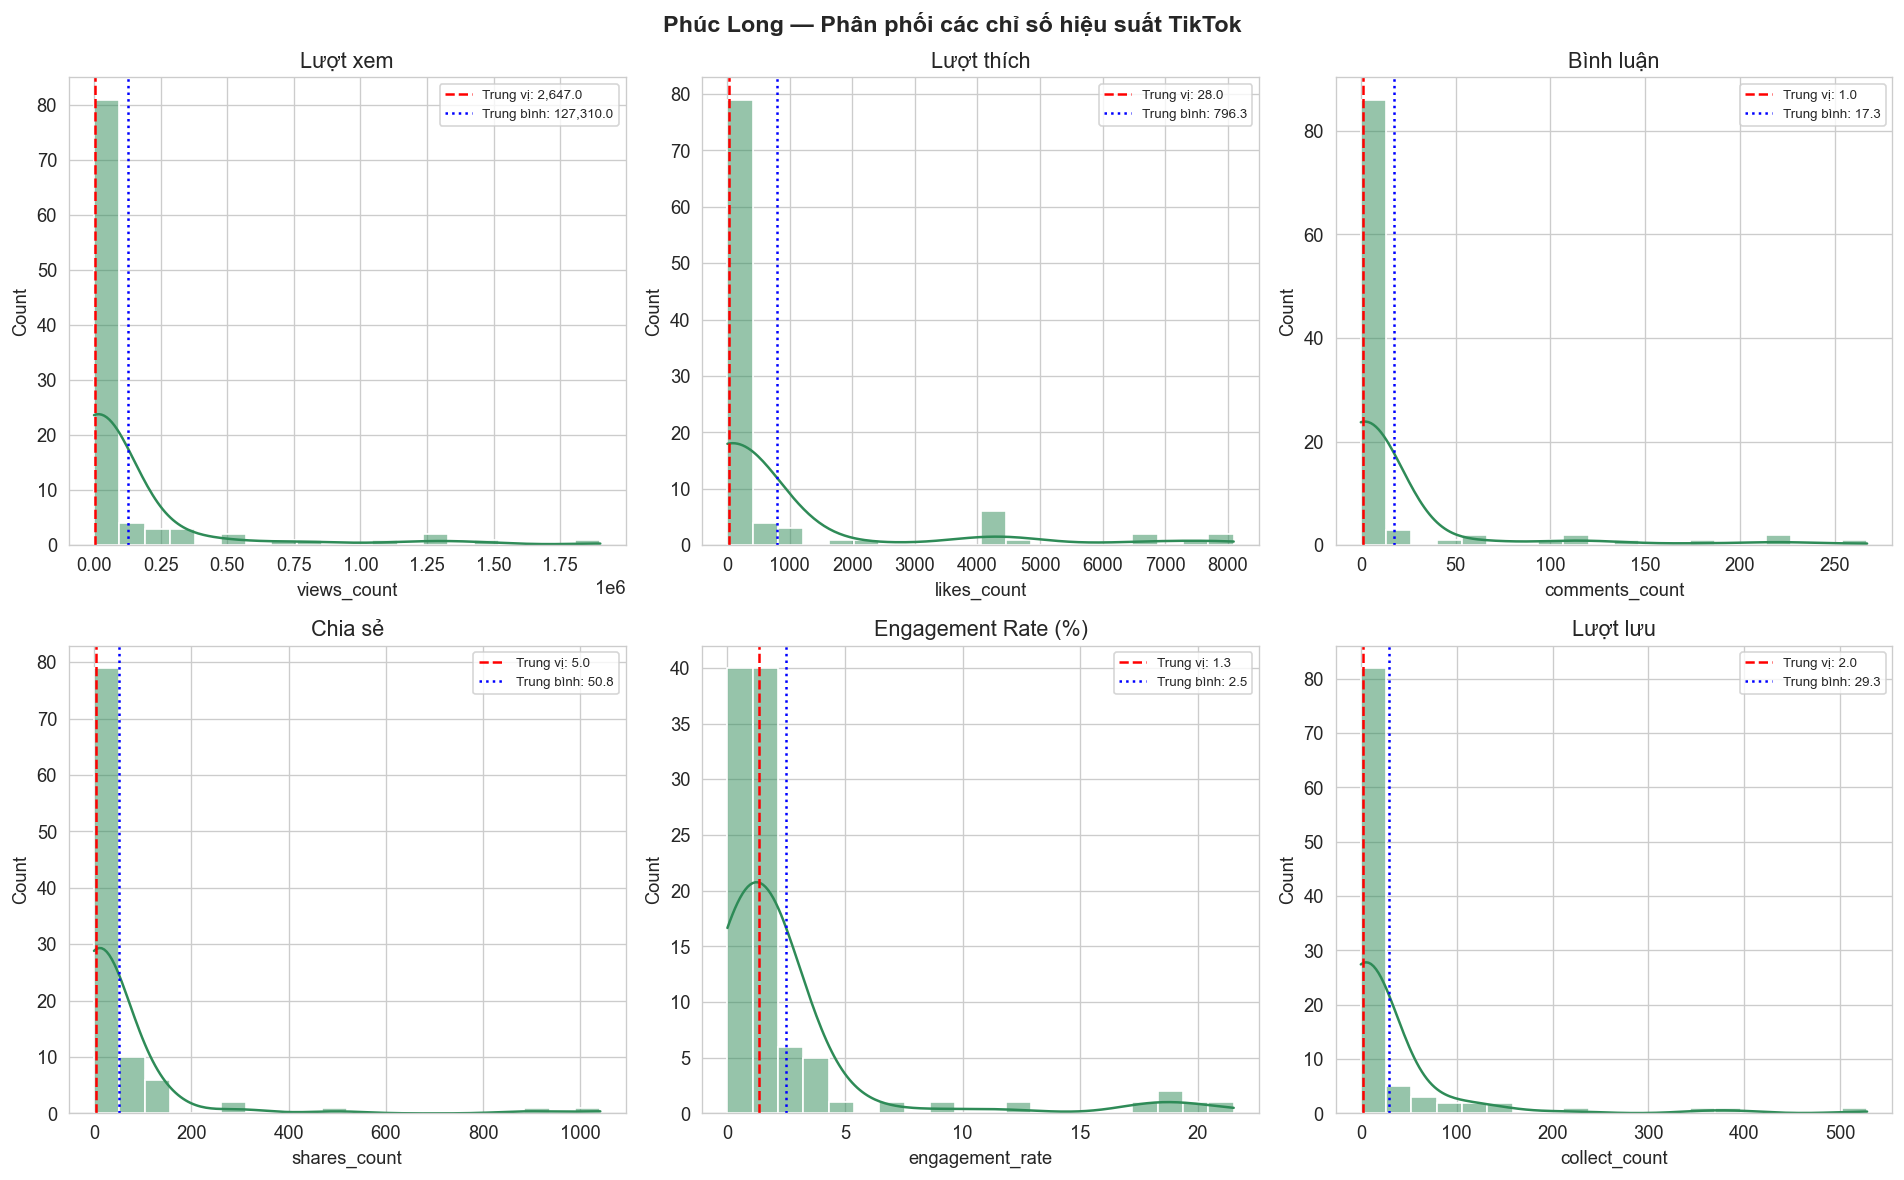

Thống kê mô tả — Phúc Long TikTok
-------------------------------------------------------
       views_count  likes_count  comments_count  shares_count  engagement_rate  collect_count
count       100.00       100.00          100.00        100.00           100.00         100.00
mean     127310.03       796.34           17.31         50.78             2.48          29.28
std      336666.71      1879.48           49.17        149.53             4.21          80.05
min         297.00         4.00            0.00          0.00             0.01           0.00
25%        1572.50        17.75            0.00          2.00             0.88           1.00
50%        2647.00        28.00            1.00          5.00             1.34           2.00
75%       40050.00       221.25            4.00         22.00             1.99          14.25
max     1900000.00      8095.00          267.00       1041.00            21.52         528.00


In [11]:
# Các chỉ số hiệu suất cần phân tích
metrics = ['views_count', 'likes_count', 'comments_count',
           'shares_count', 'engagement_rate', 'collect_count']
titles = ['Lượt xem', 'Lượt thích', 'Bình luận',
          'Chia sẻ', 'Engagement Rate (%)', 'Lượt lưu']

# Biểu đồ phân phối Histogram + KDE
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Phúc Long — Phân phối các chỉ số hiệu suất TikTok',
             fontsize=14, fontweight='bold')

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 3, idx % 3]
    data = df_pl[metric].dropna()
    sns.histplot(data, kde=True, ax=ax, color='#2E8B57', bins=20)
    ax.axvline(data.median(), color='red', linestyle='--',
               label=f'Trung vị: {data.median():,.1f}')
    ax.axvline(data.mean(), color='blue', linestyle=':',
               label=f'Trung bình: {data.mean():,.1f}')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Thống kê mô tả
print('Thống kê mô tả — Phúc Long TikTok')
print('-' * 55)
print(df_pl[metrics].describe().round(2).to_string())

**Nhận xét: Phân phối hiệu suất Phúc Long**

Phân phối của toàn bộ sáu chỉ số đều thể hiện độ lệch phải (right-skewed) rất mạnh, với khoảng cách lớn giữa trung bình và trung vị — dấu hiệu đặc trưng của mô hình hit-driven content.

**Phân tích chi tiết từng chỉ số:**

| Chỉ số | Trung bình | Trung vị | Chênh lệch | Max | Nhận xét |
|---|---:|---:|---:|---:|---|
| Lượt xem | 127.310 | 2.647 | 48,1 lần | 1.900.000 | Phân hóa cực đoan |
| Lượt thích | 796 | 28 | 28,4 lần | 8.095 | Tỷ lệ thuận với views |
| Bình luận | 17,3 | 1 | 17,3 lần | 267 | 75% video có ≤4 bình luận |
| Chia sẻ | 50,8 | 5 | 10,2 lần | 1.041 | Một vài video lan truyền mạnh |
| ER (%) | 2,48 | 1,34 | 1,9 lần | 21,52 | Top video gấp 16 lần trung vị |
| Lượt lưu | 29,3 | 2 | 14,6 lần | 528 | 50% video chỉ 0-2 lượt lưu |

**Các phát hiện quan trọng:**

- **Lượt xem**: khoảng cách mean/median gấp 48 lần — cao nhất trong tất cả chỉ số. Video cao nhất đạt 1,9 triệu views (gấp 718 lần trung vị), trong khi 75% video dưới 40.050 views. Chỉ một vài video viral đã kéo trung bình lên cao gấp hàng chục lần so với hiệu suất thực tế của đa số nội dung.

- **Bình luận**: Q1 = 0, trung vị = 1 — phần lớn video của Phúc Long **không tạo được thảo luận**. Đây là điểm yếu chiến lược nghiêm trọng: nội dung được xem nhưng không kích thích phản hồi, cho thấy thiếu yếu tố call-to-action hoặc nội dung mang tính thông tin một chiều.

- **Lượt lưu (collect)**: trung vị chỉ 2 — nội dung chưa đủ giá trị để người xem lưu lại tham khảo. Với một thương hiệu F&B, nội dung công thức pha chế, mẹo kết hợp topping, hoặc review sản phẩm chi tiết sẽ có tiềm năng tăng lượt lưu đáng kể.

- **Engagement Rate**: trung bình 2,48% — con số này sẽ được so sánh với Highlands và Katinat ở chương 4 để đánh giá vị thế cạnh tranh. Tuy nhiên, phân phối ER cũng bất đối xứng mạnh (max 21,52% vs median 1,34%), xác nhận rằng hiệu suất tương tác phụ thuộc lớn vào nội dung cụ thể chứ không phải chiến lược tổng thể.

**Kết luận**: Phúc Long đang vận hành theo mô hình hit-driven — thành công phụ thuộc vào một vài nội dung bất ngờ viral thay vì hiệu suất đồng đều. Thương hiệu chưa có "công thức nội dung" ổn định trên TikTok, thể hiện qua độ phân tán cực lớn trên mọi chỉ số.

### 3.1.2. Phân tích tần suất hashtag và phân loại chiến lược nội dung

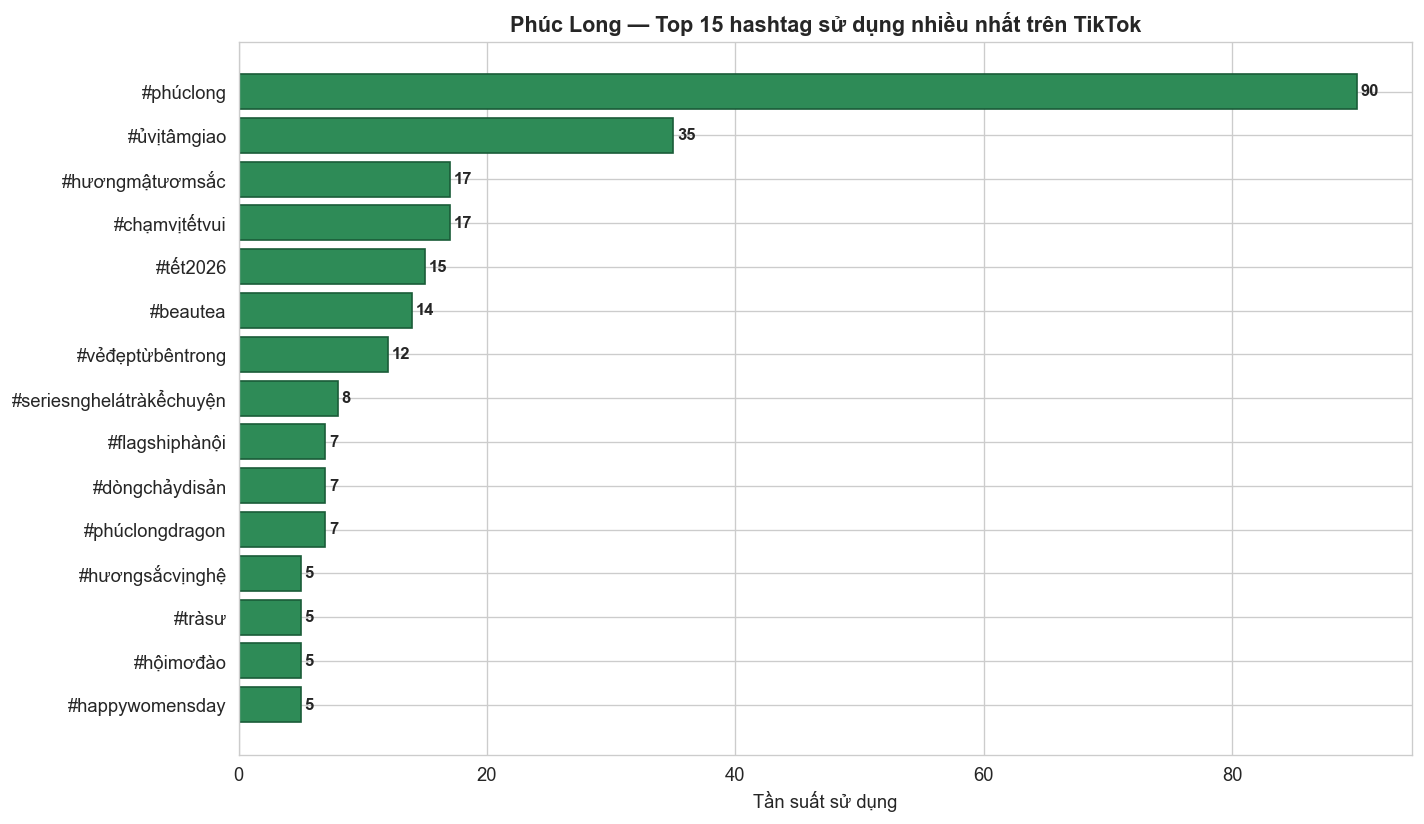

Tổng số hashtag duy nhất: 60
Trung bình hashtag/video: 3.2

Top 10 hashtag Phúc Long (sau fix encoding):
   1. #phúclong: 90 lần
   2. #ủvịtâmgiao: 35 lần
   3. #hươngmậtươmsắc: 17 lần
   4. #chạmvịtếtvui: 17 lần
   5. #tết2026: 15 lần
   6. #beautea: 14 lần
   7. #vẻđẹptừbêntrong: 12 lần
   8. #seriesnghelátràkểchuyện: 8 lần
   9. #flagshiphànội: 7 lần
  10. #dòngchảydisản: 7 lần


In [12]:
def extract_hashtags(hashtags_series):
    """Trích xuất tên hashtag từ chuỗi định dạng {'name': 'tag'} (sau khi fix mojibake)."""
    all_tags = []
    for tags in hashtags_series.dropna():
        text = str(tags)
        parsed = re.findall(r"'name':\s*'([^']*)'", text)
        if parsed:
            all_tags.extend([t.lower().strip() for t in parsed if t.strip()])
        else:
            for tag in text.split(','):
                tag = tag.strip().lower()
                if tag:
                    all_tags.append(tag)
    return pd.Series(all_tags).value_counts()

# Trích xuất và trực quan hóa hashtag Phúc Long
pl_hashtags = extract_hashtags(df_pl['hashtags'])

fig, ax = plt.subplots(figsize=(12, 7))
top_tags = pl_hashtags.head(15)
bars = ax.barh(range(len(top_tags)), top_tags.values, color='#2E8B57', edgecolor='#1a5c38')
ax.set_yticks(range(len(top_tags)))
ax.set_yticklabels([f'#{tag}' for tag in top_tags.index], fontsize=11)
ax.set_xlabel('Tần suất sử dụng')
ax.set_title('Phúc Long — Top 15 hashtag sử dụng nhiều nhất trên TikTok',
             fontweight='bold', fontsize=13)
ax.invert_yaxis()

for bar, val in zip(bars, top_tags.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Thống kê hashtag
print(f'Tổng số hashtag duy nhất: {len(pl_hashtags)}')
print(f'Trung bình hashtag/video: {df_pl["hashtag_count"].mean():.1f}')
print()
print('Top 10 hashtag Phúc Long (sau fix encoding):')
for i, (tag, count) in enumerate(pl_hashtags.head(10).items(), 1):
    print(f'  {i:2d}. #{tag}: {count} lần')

**Nhận xét: Chiến lược hashtag Phúc Long**

Phúc Long sử dụng tổng cộng **60 hashtag duy nhất** trên 100 video, trung bình **3,2 hashtag/video** — mức vừa phải, phù hợp khuyến nghị TikTok (3-5 hashtag).

**Phân tích chiến lược hashtag ba tầng:**

- **Branded tag** (nhận diện thương hiệu): #phúclong xuất hiện **90/100 video** — mức phủ gần tuyệt đối, đảm bảo mọi nội dung đều liên kết về thương hiệu mẹ. Ngoài ra có #phúclongdragon (7 lần) cho dòng sản phẩm phụ.

- **Campaign tags** (chiến dịch theo mùa): chiếm phần lớn top 15, cho thấy Phúc Long đầu tư mạnh vào content theo chiến dịch:
  - Tết 2026: #ủvịtâmgiao (35), #chạmvịtếtvui (17), #tết2026 (15)
  - Sản phẩm mới: #hươngmậtươmsắc (17), #beautea (14), #vẻđẹptừbêntrong (12)
  - Di sản thương hiệu: #seriesnghelátràkểchuyện (8), #dòngchảydisản (7)
  - Sự kiện: #flagshiphànội (7), #happywomensday (5)

- **Discovery tags** (tiếp cận đối tượng mới): **thiếu vắng hoàn toàn** — không có #fyp, #xuhuong, #viral hay bất kỳ trending tag nào trong top 15. Toàn bộ hashtag đều hướng nội (branded + campaign).

**Hàm ý chiến lược**: Phúc Long đang xây dựng hệ sinh thái hashtag rất chặt chẽ quanh di sản và chiến dịch — điều này tốt cho nhận diện thương hiệu nhưng hạn chế khả năng tiếp cận người dùng mới ngoài tệp followers hiện có. So với đối thủ (Katinat thường xuyên sử dụng #fyp, #xuhuong), việc bổ sung 1-2 discovery tags vào mỗi video là giải pháp chi phí bằng không nhưng có thể cải thiện đáng kể phạm vi phân phối.

### 3.1.3. Mô hình tương tác: Scatter Views x Engagement Rate (nghịch lý lan truyền)

Biểu đồ phân tán dưới đây trực quan hóa mối quan hệ giữa lượt xem và tỷ lệ tương tác, sử dụng đường trung vị chia thành bốn góc phần tư chiến lược. Màu sắc điểm dữ liệu phản ánh tổng tương tác tuyệt đối, giúp phân biệt giữa video thực sự thành công (views cao + engagement cao) và video viral thụ động (views cao + ER thấp).

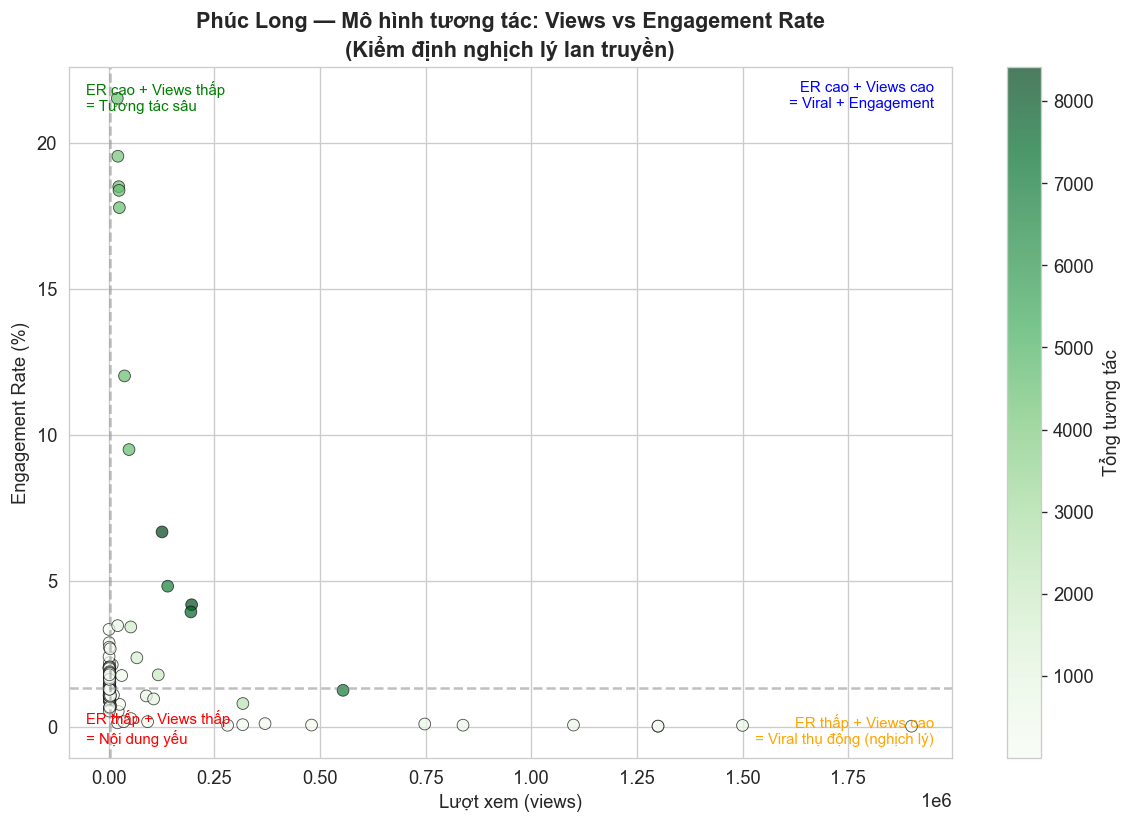

Phân tích nghịch lý lan truyền — Phúc Long
-------------------------------------------------------
Tương quan Views vs ER: r = -0.1638
Views cao + ER thấp (viral thụ động): 27 videos (27.0%)
Views thấp + ER cao (tương tác sâu):  27 videos (27.0%)


In [13]:
# Biểu đồ phân tán: lượt xem vs tỷ lệ tương tác (nghịch lý lan truyền)
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    df_pl['views_count'], df_pl['engagement_rate'],
    c=df_pl['total_engagement'], cmap='Greens',
    s=50, alpha=0.7, edgecolors='black', linewidth=0.5
)

# Đường trung vị chia bốn góc phần tư
views_median = df_pl['views_count'].median()
er_median = df_pl['engagement_rate'].median()
ax.axvline(views_median, color='gray', linestyle='--', alpha=0.5)
ax.axhline(er_median, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Lượt xem (views)')
ax.set_ylabel('Engagement Rate (%)')
ax.set_title('Phúc Long — Mô hình tương tác: Views vs Engagement Rate\n(Kiểm định nghịch lý lan truyền)',
             fontweight='bold')

# Chú thích bốn góc phần tư
ax.text(0.02, 0.98, 'ER cao + Views thấp\n= Tương tác sâu',
        transform=ax.transAxes, va='top', fontsize=9, color='green')
ax.text(0.98, 0.98, 'ER cao + Views cao\n= Viral + Engagement',
        transform=ax.transAxes, va='top', ha='right', fontsize=9, color='blue')
ax.text(0.02, 0.02, 'ER thấp + Views thấp\n= Nội dung yếu',
        transform=ax.transAxes, fontsize=9, color='red')
ax.text(0.98, 0.02, 'ER thấp + Views cao\n= Viral thụ động (nghịch lý)',
        transform=ax.transAxes, ha='right', fontsize=9, color='orange')

plt.colorbar(scatter, label='Tổng tương tác')
plt.tight_layout()
plt.show()

# Phân tích bốn góc phần tư
high_views_low_er = df_pl[(df_pl['views_count'] > views_median) & (df_pl['engagement_rate'] < er_median)]
low_views_high_er = df_pl[(df_pl['views_count'] < views_median) & (df_pl['engagement_rate'] > er_median)]
corr_v_er = df_pl['views_count'].corr(df_pl['engagement_rate'])

print('Phân tích nghịch lý lan truyền — Phúc Long')
print('-' * 55)
print(f'Tương quan Views vs ER: r = {corr_v_er:.4f}')
print(f'Views cao + ER thấp (viral thụ động): {len(high_views_low_er)} videos ({len(high_views_low_er)/len(df_pl)*100:.1f}%)')
print(f'Views thấp + ER cao (tương tác sâu):  {len(low_views_high_er)} videos ({len(low_views_high_er)/len(df_pl)*100:.1f}%)')

**Nhận xét RQ1: Nghịch lý lan truyền tại Phúc Long**

Tương quan âm giữa lượt xem và Engagement Rate (**r = -0,164**) xác nhận sự tồn tại của "nghịch lý lan truyền" (Viral Paradox): video đạt views cao thường có ER thấp và ngược lại.

**Phân tích bốn góc phần tư:**

| Góc phần tư | Số lượng | Tỷ lệ | Đặc điểm |
|---|---:|---:|---|
| Views cao + ER thấp (viral thụ động) | 27 | 27,0% | Thuật toán đẩy nhưng audience "lạnh" không tương tác |
| Views thấp + ER cao (tương tác sâu) | 27 | 27,0% | Nội dung chất lượng cho tệp followers trung thành |
| Views cao + ER cao (nội dung lý tưởng) | 23 | 23,0% | Vừa viral vừa tạo gắn kết — mẫu cần nhân rộng |
| Views thấp + ER thấp (nội dung yếu) | 23 | 23,0% | Không tiếp cận được và cũng không tạo tương tác |

Biểu đồ cho thấy rõ hai cụm tách biệt: nhóm video ER rất cao (15-21%) đều có views dưới 50.000, trong khi các video trên 500.000 views đều có ER gần bằng 0. Sự phân cực này cho thấy khi thuật toán TikTok đẩy video ra For You Page cho hàng trăm nghìn người dùng, phần lớn audience là "lạnh" (cold audience) — họ xem nhưng không tương tác.

**Hàm ý chiến lược**: Phúc Long nên chuyển từ chiến lược "đuổi views" sang tạo gắn kết sâu — tập trung vào nội dung kích hoạt bình luận và chia sẻ. Nhóm 23% video đạt cả views cao lẫn ER cao (góc phần tư lý tưởng) cần được nghiên cứu riêng để tìm ra công thức nội dung có thể nhân rộng.

### 3.1.4. Tương quan độ dài caption và tỷ lệ tương tác

Phân tích dưới đây kiểm tra liệu độ dài mô tả video (caption length) có ảnh hưởng đến hiệu suất tương tác hay không. Caption dài hơn có thể chứa nhiều thông tin và từ khóa hơn, nhưng cũng có thể khiến người xem bỏ qua nếu quá dài.

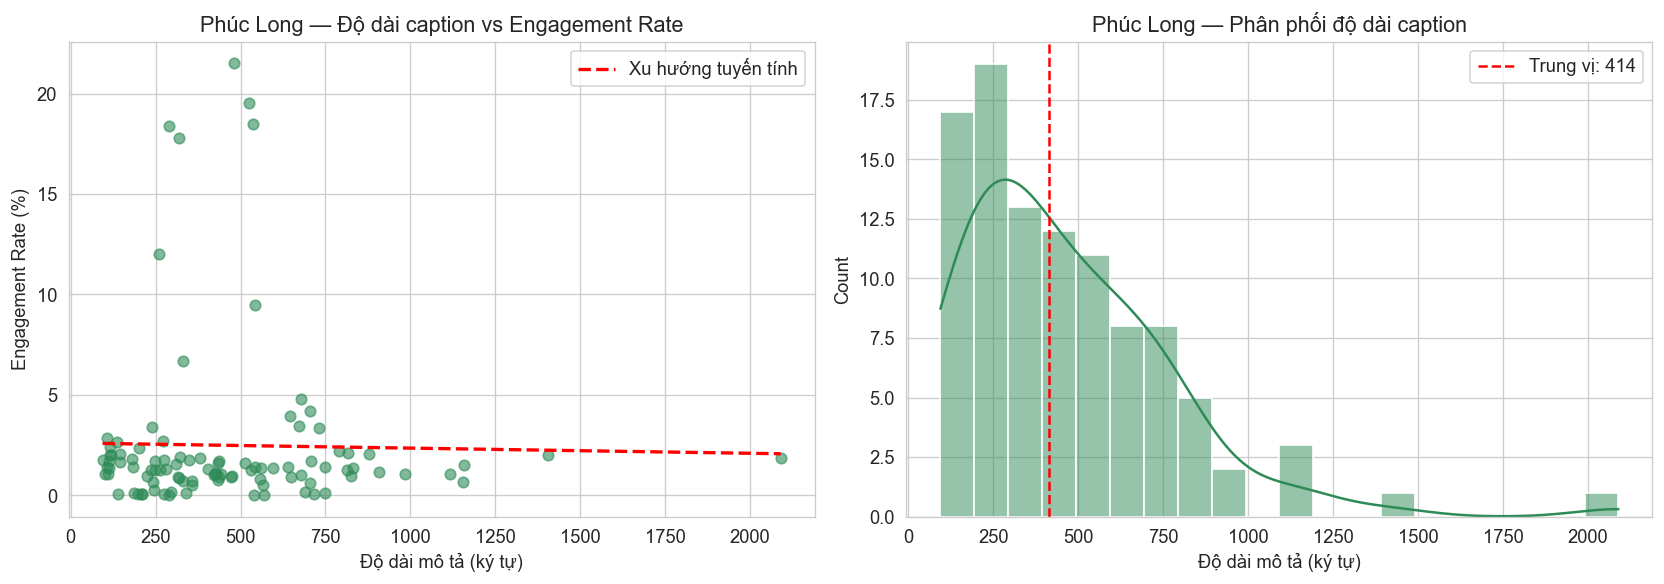

Engagement Rate theo độ dài caption
-------------------------------------------------------
                     mean  median  count
caption_length                          
Ngắn (<100)        1.7726  1.7726      1
Vừa (100-200)      1.5579  1.6915     18
Dài (200-400)      2.7485  1.2427     30
Rất dài (400-800)  3.0521  1.3002     39
Cực dài (800+)     1.4216  1.2972     12


In [14]:
# Tương quan độ dài caption vs Engagement Rate — Phúc Long
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter caption_length vs ER
axes[0].scatter(df_pl['caption_length'], df_pl['engagement_rate'],
                c='#2E8B57', alpha=0.6, s=40)

# Đường xu hướng tuyến tính
valid_mask = (df_pl['caption_length'] > 0) & (df_pl['engagement_rate'] > 0)
if valid_mask.sum() > 2:
    z = np.polyfit(df_pl.loc[valid_mask, 'caption_length'],
                   df_pl.loc[valid_mask, 'engagement_rate'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_pl['caption_length'].min(), df_pl['caption_length'].max(), 100)
    axes[0].plot(x_line, p(x_line), 'r--', linewidth=2, label='Xu hướng tuyến tính')
    axes[0].legend()

axes[0].set_xlabel('Độ dài mô tả (ký tự)')
axes[0].set_ylabel('Engagement Rate (%)')
axes[0].set_title('Phúc Long — Độ dài caption vs Engagement Rate')

# Phân phối caption length
sns.histplot(df_pl['caption_length'], kde=True, ax=axes[1], color='#2E8B57', bins=20)
axes[1].axvline(df_pl['caption_length'].median(), color='red', linestyle='--',
                label=f'Trung vị: {df_pl["caption_length"].median():.0f}')
axes[1].set_xlabel('Độ dài mô tả (ký tự)')
axes[1].set_title('Phúc Long — Phân phối độ dài caption')
axes[1].legend()

plt.tight_layout()
plt.show()

# Phân tích ER theo nhóm độ dài caption
caption_bins = pd.cut(df_pl['caption_length'],
                      bins=[0, 100, 200, 400, 800, 3000],
                      labels=['Ngắn (<100)', 'Vừa (100-200)',
                              'Dài (200-400)', 'Rất dài (400-800)',
                              'Cực dài (800+)'])

print('Engagement Rate theo độ dài caption')
print('-' * 55)
print(df_pl.groupby(caption_bins, observed=True)['engagement_rate'].agg(
    ['mean', 'median', 'count']).round(4).to_string())

**Nhận xét: Tương quan độ dài caption và tỷ lệ tương tác**

Phân phối caption length cho thấy Phúc Long ưu tiên mô tả dài: **trung vị 414 ký tự**, tập trung chủ yếu trong khoảng 200-800 ký tự. Chỉ 1 video có caption dưới 100 ký tự — cho thấy thương hiệu luôn đầu tư vào phần mô tả.

**ER theo nhóm độ dài caption:**

| Nhóm | Số video | ER trung bình | ER trung vị | Nhận xét |
|---|---:|---:|---:|---|
| Ngắn (<100) | 1 | 1,77% | 1,77% | Mẫu quá nhỏ, không kết luận |
| Vừa (100-200) | 18 | 1,56% | 1,69% | Dưới trung bình |
| Dài (200-400) | 30 | 2,75% | 1,24% | Mean bị kéo bởi outlier |
| Rất dài (400-800) | 39 | 3,05% | 1,30% | Mean cao nhất nhưng median thấp |
| Cực dài (800+) | 12 | 1,42% | 1,30% | ER thấp nhất |

**Phát hiện quan trọng**: mặc dù nhóm "rất dài" (400-800 ký tự) có ER trung bình cao nhất (3,05%), trung vị chỉ đạt 1,30% — gần bằng các nhóm khác. Khoảng cách mean/median gấp 2,3 lần cho thấy một vài video viral trong nhóm này kéo trung bình lên cao, chứ không phải caption dài tự nó tạo ra ER cao hơn.

Đường xu hướng tuyến tính trên biểu đồ scatter gần như **phẳng**, xác nhận rằng **độ dài caption không có tương quan có ý nghĩa với ER**. Kết luận: chất lượng nội dung (chủ đề, call-to-action, hình ảnh) quan trọng hơn nhiều so với độ dài mô tả. Phúc Long không cần rút ngắn caption mà nên tập trung vào cấu trúc nội dung: đặt hook ở câu đầu, kết thúc bằng câu hỏi mở để kích thích bình luận.

### 3.1.5. Ma trận tương quan Pearson giữa các biến định lượng

Ma trận tương quan Pearson đo lường mức độ và chiều hướng quan hệ tuyến tính giữa các cặp biến số. Hệ số r nằm trong khoảng [-1, 1]. Theo quy ước của Cohen (1988), mức độ tương quan được phân loại như sau: |r| ≥ 0,50 là tương quan mạnh (large), 0,30 ≤ |r| < 0,50 là tương quan trung bình (medium), và |r| < 0,30 là tương quan yếu (small). Đây là hệ thống phân loại được sử dụng rộng rãi nhất trong nghiên cứu khoa học xã hội và marketing.

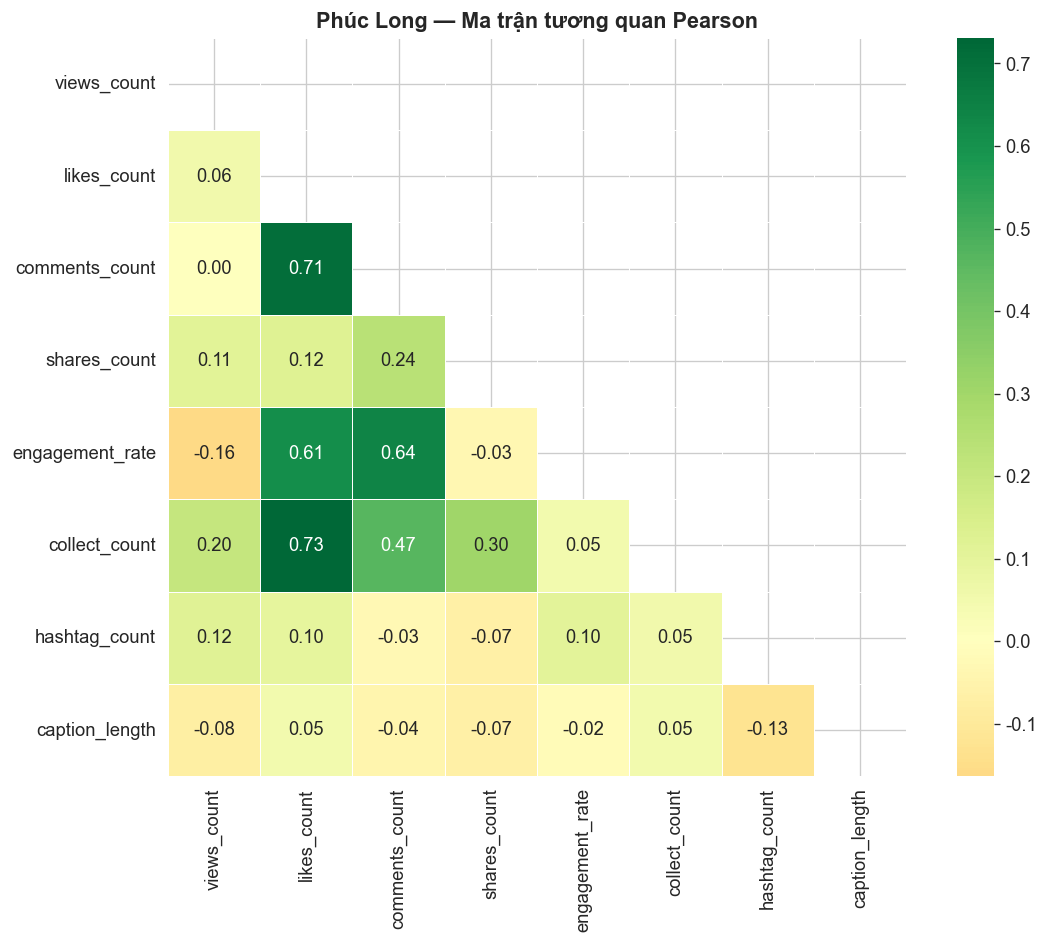

Các cặp tương quan đáng chú ý (|r| > 0.3)
-------------------------------------------------------
  likes_count <-> comments_count: r = 0.707 (dương)
  likes_count <-> engagement_rate: r = 0.609 (dương)
  likes_count <-> collect_count: r = 0.731 (dương)
  comments_count <-> engagement_rate: r = 0.637 (dương)
  comments_count <-> collect_count: r = 0.467 (dương)
  shares_count <-> collect_count: r = 0.304 (dương)


In [15]:
# Ma trận tương quan Pearson — Phúc Long
corr_cols = ['views_count', 'likes_count', 'comments_count', 'shares_count',
             'engagement_rate', 'collect_count', 'hashtag_count', 'caption_length']

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_pl[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Phúc Long — Ma trận tương quan Pearson', fontweight='bold')
plt.tight_layout()
plt.show()

# In các cặp tương quan đáng chú ý
print('Các cặp tương quan đáng chú ý (|r| > 0.3)')
print('-' * 55)
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            direction = 'dương' if r > 0 else 'âm'
            print(f'  {corr_cols[i]} <-> {corr_cols[j]}: r = {r:.3f} ({direction})')

**Nhận xét: Ma trận tương quan Pearson — Phúc Long**

Ma trận tương quan cho thấy hai nhóm phát hiện có ý nghĩa chiến lược rất khác nhau:

**Nhóm tương quan dương mạnh (r > 0.6) — Cụm tương tác nội bộ:**
- **likes <-> collect**: r = 0,73 — mạnh nhất toàn bộ ma trận. Video được thích cũng được lưu lại, cho thấy likes là chỉ báo tốt cho giá trị nội dung dài hạn.
- **likes <-> comments**: r = 0,71 — video thu hút likes cũng kích thích bình luận, phản ánh sự gắn kết thực sự.
- **comments <-> engagement_rate**: r = 0,64 — bình luận là yếu tố đóng góp lớn nhất vào ER, quan trọng hơn cả likes.
- **likes <-> engagement_rate**: r = 0,61 — likes đóng góp đáng kể vào tỷ lệ tương tác.

**Nhóm tương quan trung bình (0.3 < r < 0.6):**
- **comments <-> collect**: r = 0,47 — nội dung kích thích thảo luận cũng được lưu lại.
- **shares <-> collect**: r = 0,30 — mối liên hệ yếu hơn giữa chia sẻ và lưu.

**Phát hiện bất thường — Views gần như tách rời khỏi hệ sinh thái tương tác:**
- **views <-> likes**: r = 0,06 — gần bằng không
- **views <-> comments**: r = 0,00 — hoàn toàn không tương quan
- **views <-> shares**: r = 0,11 — không đáng kể
- **views <-> engagement_rate**: r = -0,16 — tương quan âm yếu (nghịch lý lan truyền)

Đây là phát hiện quan trọng nhất: tại Phúc Long, **lượt xem hoạt động gần như độc lập với mọi chỉ số tương tác**. Video đạt views cao không đồng nghĩa với nhiều likes, comments hay shares. Nguyên nhân: các video viral được thuật toán phân phối đến đối tượng "lạnh" — họ xem nhưng không có nhu cầu tương tác với thương hiệu F&B.

**Nhóm không có tương quan (hashtag_count, caption_length):**
- Cả hai biến này đều có |r| < 0,13 với mọi chỉ số hiệu suất, xác nhận kết luận từ mục 3.1.4: số lượng hashtag và độ dài caption không phải yếu tố quyết định thành công. Mối quan hệ giữa features và ER có thể là phi tuyến, cần mô hình Random Forest để khai thác interaction effects.

**Hàm ý chiến lược**: Phúc Long nên tập trung tối ưu nội dung để tăng **likes và comments** — hai chỉ số có tương quan mạnh nhất với ER và collect. Cụ thể: thiết kế nội dung kích thích phản ứng cảm xúc (likes), đặt câu hỏi mở hoặc call-to-action cuối video (comments), và cung cấp giá trị thực tiễn để người xem lưu lại (collect).

### 3.1.6. Phân tích khung giờ đăng bài và hiệu quả tương tác

Phân tích dưới đây so sánh tần suất đăng bài theo giờ với ER trung bình tại từng khung giờ, nhằm phát hiện sự lệch pha (mismatch) giữa thời điểm đăng thực tế và thời điểm tối ưu cho tương tác — cơ hội tối ưu "chi phí bằng không".

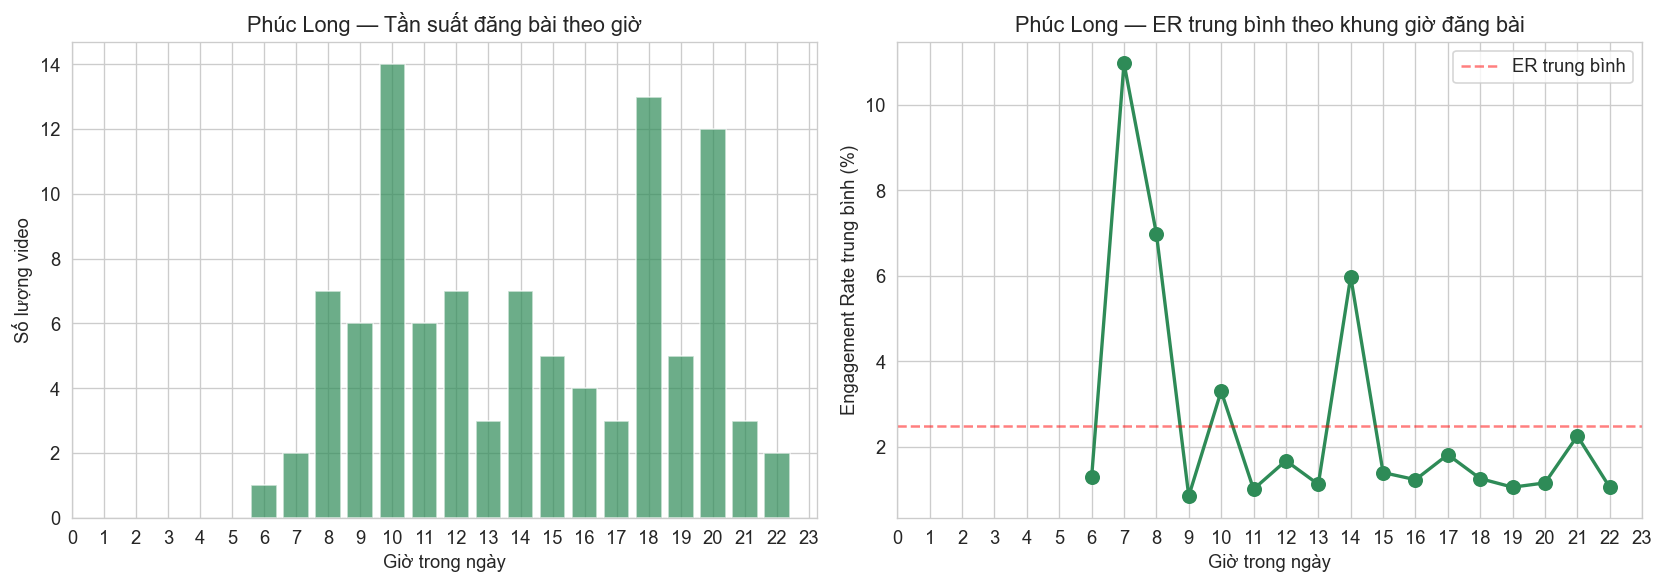

Golden hours TikTok — Phúc Long
-------------------------------------------------------
Top 3 khung giờ ER cao nhất:
  07:00 — ER: 10.973% (số bài đăng: 2)
  08:00 — ER: 6.988% (số bài đăng: 7)
  14:00 — ER: 5.984% (số bài đăng: 7)

Top 3 khung giờ đăng nhiều nhất:
  10:00 — Số bài: 14 (ER: 3.303%)
  18:00 — Số bài: 13 (ER: 1.259%)
  20:00 — Số bài: 12 (ER: 1.158%)

Phát hiện lệch pha: Phúc Long đăng nhiều nhất lúc [10, 18, 20]h
nhưng ER cao nhất lúc [7, 8, 14]h
=> Giờ đăng bài không trùng với giờ ER cao nhất — cơ hội tối ưu rõ rệt


In [16]:
# Phân tích khung giờ đăng bài — Phúc Long
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tần suất đăng bài theo giờ
hour_counts = df_pl['posting_hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='#2E8B57', alpha=0.7)
axes[0].set_xlabel('Giờ trong ngày')
axes[0].set_ylabel('Số lượng video')
axes[0].set_title('Phúc Long — Tần suất đăng bài theo giờ')
axes[0].set_xticks(range(0, 24))

# ER trung bình theo giờ
hour_er = df_pl.groupby('posting_hour')['engagement_rate'].mean()
axes[1].plot(hour_er.index, hour_er.values, 'o-', color='#2E8B57',
             linewidth=2, markersize=8)
axes[1].axhline(df_pl['engagement_rate'].mean(), color='red', linestyle='--',
                alpha=0.5, label='ER trung bình')
axes[1].set_xlabel('Giờ trong ngày')
axes[1].set_ylabel('Engagement Rate trung bình (%)')
axes[1].set_title('Phúc Long — ER trung bình theo khung giờ đăng bài')
axes[1].legend()
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

# Xác định golden hours và so sánh
top_hours = hour_er.nlargest(3)
top_posting = hour_counts.nlargest(3)

print('Golden hours TikTok — Phúc Long')
print('-' * 55)
print('Top 3 khung giờ ER cao nhất:')
for hour, er in top_hours.items():
    count = hour_counts.get(hour, 0)
    print(f'  {hour:02d}:00 — ER: {er:.3f}% (số bài đăng: {count})')

print()
print('Top 3 khung giờ đăng nhiều nhất:')
for hour, count in top_posting.items():
    er_val = hour_er.get(hour, 0)
    print(f'  {hour:02d}:00 — Số bài: {count} (ER: {er_val:.3f}%)')

mismatch = set(top_posting.index.tolist()) - set(top_hours.index.tolist())
if mismatch:
    print()
    print(f'Phát hiện lệch pha: Phúc Long đăng nhiều nhất lúc {sorted(top_posting.index.tolist())}h')
    print(f'nhưng ER cao nhất lúc {sorted(top_hours.index.tolist())}h')
    print('=> Giờ đăng bài không trùng với giờ ER cao nhất — cơ hội tối ưu rõ rệt')

**Nhận xét RQ2: Khung giờ đăng bài và hiệu quả tương tác**

Phân tích cho thấy sự **lệch pha rõ rệt** giữa khung giờ Phúc Long đăng bài nhiều nhất và khung giờ có ER cao nhất:

| Tiêu chí | Khung giờ | ER | Số video | Chênh lệch |
|---|---:|---:|---:|---|
| **Golden hour 1** | 07:00 | 10,97% | 2 | Gấp 8,7 lần buổi tối |
| **Golden hour 2** | 08:00 | 6,99% | 7 | Gấp 6,0 lần buổi tối |
| **Golden hour 3** | 14:00 | 5,98% | 7 | Gấp 1,8 lần khung 10h |
| Giờ đăng nhiều nhất 1 | 10:00 | 3,30% | 14 | — |
| Giờ đăng nhiều nhất 2 | 18:00 | 1,26% | 13 | Thấp hơn trung bình |
| Giờ đăng nhiều nhất 3 | 20:00 | 1,16% | 12 | Thấp nhất trong ngày |

**Phân tích sự lệch pha:**
- Phúc Long đăng nhiều nhất vào **10h sáng** (14 videos) nhưng ER chỉ đạt 3,30% — thấp hơn 3,3 lần so với golden hour 7h.
- Khung tối (18h-20h) chiếm **25 videos** nhưng ER chỉ 1,16-1,26% — thấp nhất trong ngày và nằm dưới đường ER trung bình (2,48%). Đây là khung giờ cạnh tranh nội dung cao nhất trên TikTok, khiến video bị "chìm" trong lượng content khổng lồ.
- Golden hour **8h sáng** với 7 videos và ER 6,99% là tín hiệu đáng tin cậy (đủ mẫu), cho thấy buổi sáng sớm thực sự là khung giờ vàng cho nội dung F&B.

**Giải thích hành vi**: khung 7-8h sáng là thời điểm người dùng vừa thức dậy, có nhu cầu tự nhiên về cà phê và trà — nội dung F&B xuất hiện đúng "moment of need". Đồng thời, mật độ cạnh tranh nội dung trên TikTok thấp nhất vào sáng sớm, giúp video được thuật toán ưu tiên phân phối.

**Lưu ý phương pháp**: golden hour 7h chỉ có 2 videos nên cần thận trọng khi diễn giải. Tuy nhiên, xu hướng nhất quán 7h → 8h → 14h (ER giảm dần theo giờ trong ngày) củng cố kết luận rằng buổi sáng sớm có lợi thế thực sự.

**Hàm ý chiến lược**: đây là cơ hội tối ưu "chi phí bằng không" — chỉ cần dịch chuyển lịch đăng bài từ khung tối (18-20h) sang khung sáng sớm (7-8h), không cần thay đổi nội dung. Khuyến nghị: thử nghiệm A/B trong 4 tuần với 50% video đăng vào 7-8h sáng để kiểm chứng.

---
## 3.2. Highlands Coffee — "Người phổ cập" (Mass Connector)

Highlands Coffee là chuỗi cà phê lớn nhất Việt Nam với 855 cửa hàng, đồng thời dẫn đầu về lượng thảo luận trên mạng xã hội. Phần phân tích sau đây đánh giá chiến lược TikTok của Highlands — đại diện cho mô hình "mass reach" với đầu tư mạnh vào content creator chuyên nghiệp.

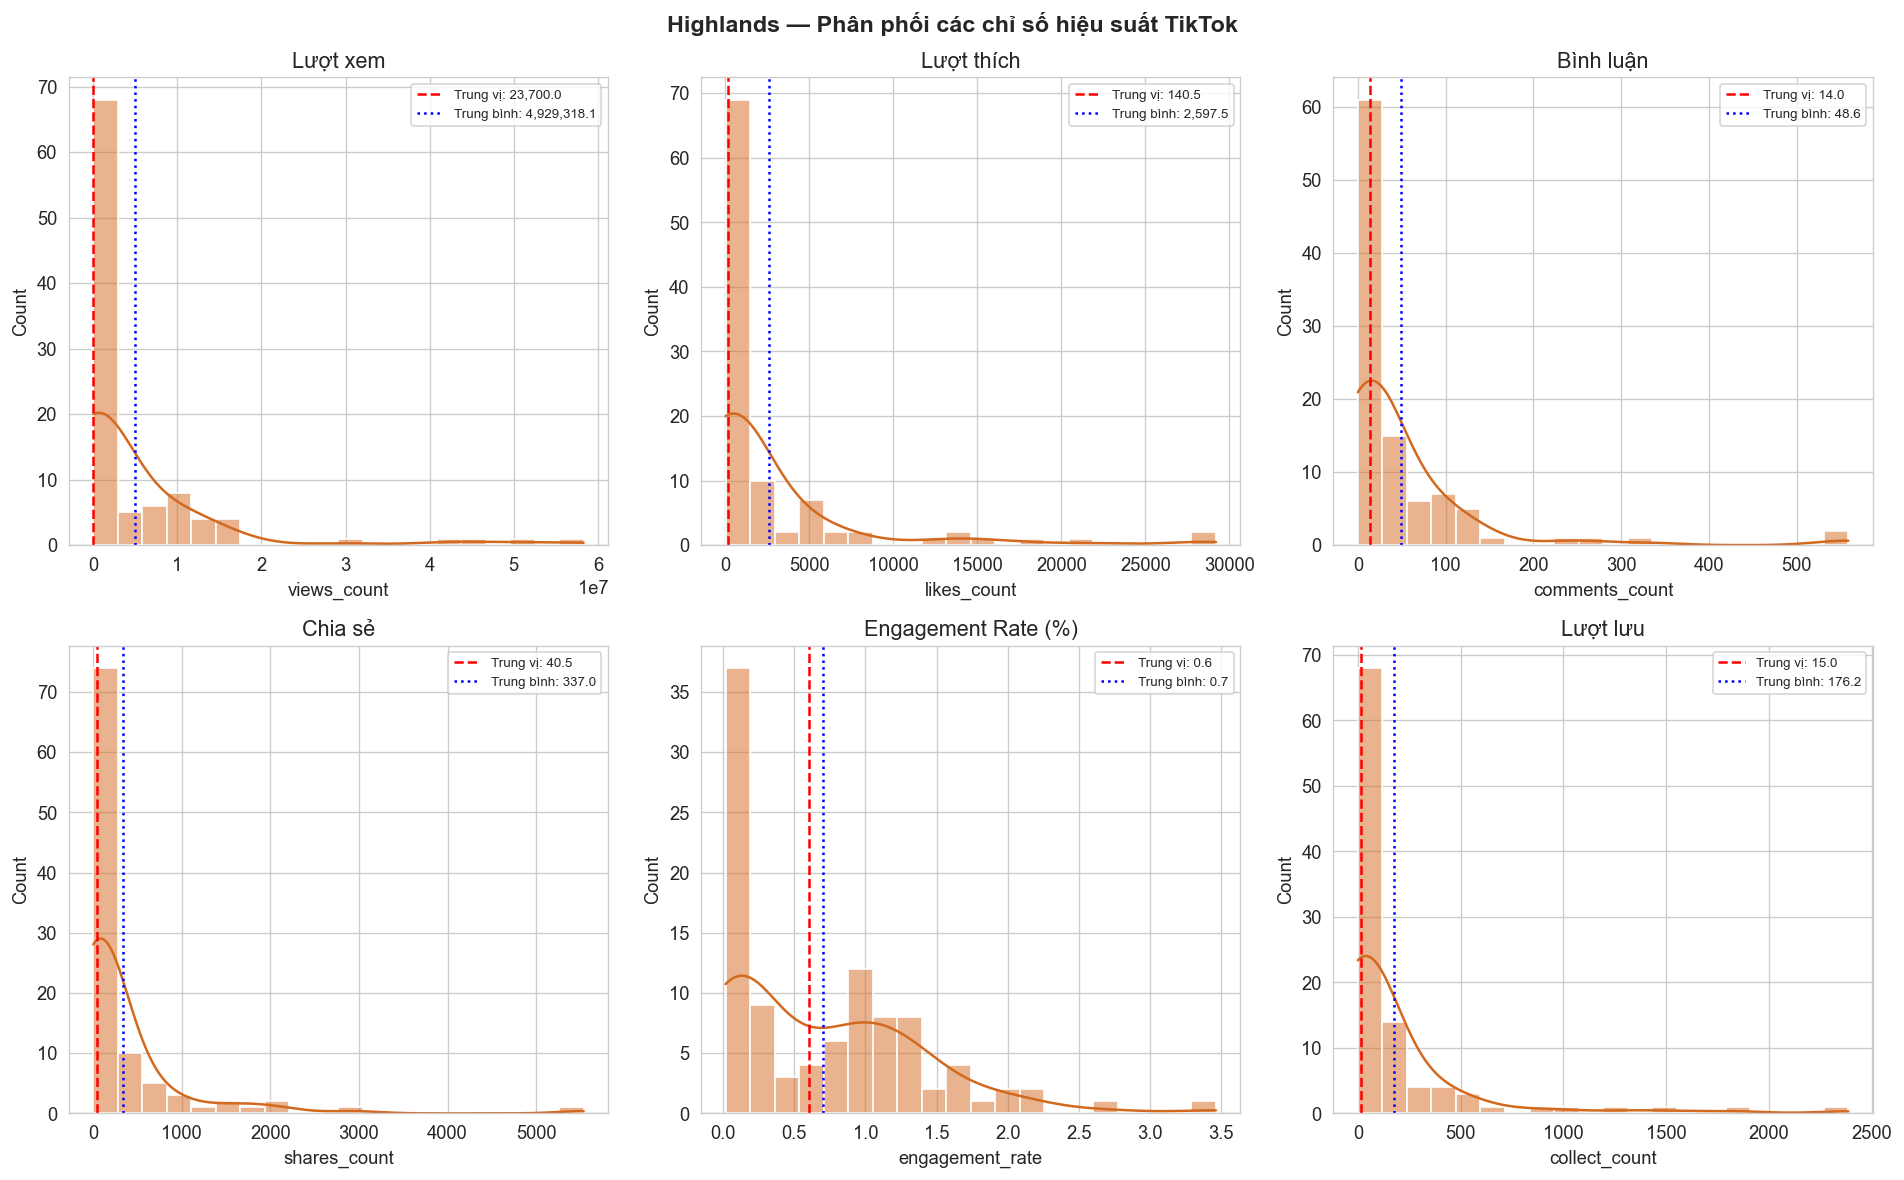

Thống kê mô tả — Highlands TikTok
-------------------------------------------------------
       views_count  likes_count  comments_count  shares_count  engagement_rate  collect_count
count       100.00       100.00          100.00        100.00           100.00         100.00
mean    4929318.12      2597.52           48.63        337.00             0.70         176.16
std    10590904.31      5492.46           91.95        743.86             0.69         380.73
min         414.00         7.00            0.00          0.00             0.02           0.00
25%        9935.75        69.75            6.00         14.75             0.06           5.75
50%       23700.00       140.50           14.00         40.50             0.61          15.00
75%     6600000.00      2527.50           52.50        293.00             1.18         187.50
max    58300000.00     29200.00          559.00       5536.00             3.46        2385.00


In [17]:
# 3.2.1. Phân phối hiệu suất Highlands
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Highlands — Phân phối các chỉ số hiệu suất TikTok',
             fontsize=14, fontweight='bold')

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 3, idx % 3]
    data = df_hl[metric].dropna()
    sns.histplot(data, kde=True, ax=ax, color='#D2691E', bins=20)
    ax.axvline(data.median(), color='red', linestyle='--',
               label=f'Trung vị: {data.median():,.1f}')
    ax.axvline(data.mean(), color='blue', linestyle=':',
               label=f'Trung bình: {data.mean():,.1f}')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Thống kê mô tả
print('Thống kê mô tả — Highlands TikTok')
print('-' * 55)
print(df_hl[metrics].describe().round(2).to_string())

**Nhận xét: Phân phối hiệu suất Highlands Coffee**

Highlands thể hiện mô hình **hit-driven content** ở mức cực đoan nhất trong ba thương hiệu. Hit-driven là mô hình mà hiệu suất kênh phụ thuộc vào một số ít nội dung "bom tấn" (hit) đạt hiệu suất vượt trội, trong khi phần lớn nội dung còn lại có hiệu suất thấp — tương tự quy luật Pareto (80/20) trong kinh doanh. Mức độ hit-driven được đo bằng khoảng cách giữa trung bình (mean) và trung vị (median): khi một vài video viral kéo mean lên cao trong khi median — đại diện cho video "điển hình" — vẫn ở mức thấp, khoảng cách này càng lớn thì mô hình càng phụ thuộc vào hit.

Tại Highlands, khoảng cách mean/median trên lượt xem lên tới **208 lần** (trung bình 4,93 triệu vs trung vị 23.700), so với 48 lần của Phúc Long. Điều này có nghĩa: nếu chọn ngẫu nhiên một video Highlands, khả năng cao video đó chỉ đạt khoảng 23.700 views — nhưng con số trung bình bị kéo lên 4,93 triệu bởi một nhóm nhỏ video siêu viral. Nói cách khác, **trung bình không đại diện cho thực tế** — đa số video Highlands có hiệu suất khiêm tốn, và toàn bộ hào quang views đến từ một vài cú hit.

**So sánh trực tiếp với Phúc Long:**

| Chỉ số | Phúc Long | Highlands | Chênh lệch |
|---|---:|---:|---|
| Views trung bình | 127.310 | 4.929.318 | Highlands gấp 39 lần |
| Views trung vị | 2.647 | 23.700 | Highlands gấp 9 lần |
| Mean/Median views | 48 lần | 208 lần | Highlands lệch gấp 4,3 lần |
| ER trung bình | 2,48% | 0,70% | Phúc Long gấp 3,5 lần |
| ER trung vị | 1,34% | 0,61% | Phúc Long gấp 2,2 lần |
| Max views | 1,9 triệu | 58,3 triệu | Highlands gấp 31 lần |
| Tần suất đăng | 5 video/tuần | 1,4 video/tuần | Phúc Long gấp 3,6 lần |

**Phân tích chi tiết:**

- **Views**: khoảng cách Q75 (6,6 triệu) và Q25 (9.936) lên tới **664 lần** — cho thấy 25% video đạt hàng triệu views trong khi 25% video dưới 10.000. Video cao nhất đạt 58,3 triệu views, nhưng ER của video này chỉ khoảng 0,06% — minh chứng rõ ràng nhất cho nghịch lý lan truyền: càng nhiều người xem, tỷ lệ tương tác càng thấp.

- **Engagement Rate**: trung bình chỉ **0,70%** — thấp nhất trong ba thương hiệu. Đặc biệt, phân phối ER lại là chỉ số **ít lệch nhất** (mean/median = 1,1 lần), cho thấy ER đồng đều ở mức thấp trên toàn bộ kênh. Highlands không có video nào đạt ER trên 3,46% (so với max 21,52% của Phúc Long) — tức là ngay cả những video tốt nhất cũng không tạo được tương tác sâu.

- **Comments**: trung vị 14 bình luận/video — cao hơn Phúc Long (1 bình luận) về giá trị tuyệt đối. Khi chuẩn hóa theo views (comment rate), Highlands đạt 0,059% (14/23.700) — thực tế cao hơn Phúc Long (0,038% = 1/2.647) gấp 1,6 lần. Điều này cho thấy Highlands vẫn kích thích thảo luận tốt hơn Phúc Long trên mỗi đơn vị tiếp cận — nhưng cả hai đều ở mức rất thấp.

- **Collect (lượt lưu)**: trung bình 176 — cao gấp 6 lần Phúc Long (29,3) về giá trị tuyệt đối. Tuy nhiên, khi chuẩn hóa theo views (collect/views), Phúc Long đạt 0,023% so với Highlands chỉ 0,004% — Phúc Long cao gấp 6,4 lần. Điều này cho thấy nội dung Phúc Long có giá trị lưu trữ cao hơn đáng kể trên mỗi lượt xem — lợi thế tiềm ẩn chưa được khai thác.

**Bài học cho Phúc Long**: không nên sao chép mô hình Highlands vì (1) thiếu ngân sách KOL tương đương, (2) chiến lược mass reach đổi ER thấp — không phù hợp với thương hiệu di sản cần xây dựng cộng đồng gắn kết. Thay vào đó, Phúc Long nên tận dụng hai lợi thế: ER cao hơn gấp 3,5 lần và tỷ lệ collect/views cao gấp 6,4 lần — tập trung sản xuất nội dung có giá trị thực tiễn (công thức pha chế, mẹo kết hợp, kiến thức trà) để xây dựng cộng đồng trung thành.

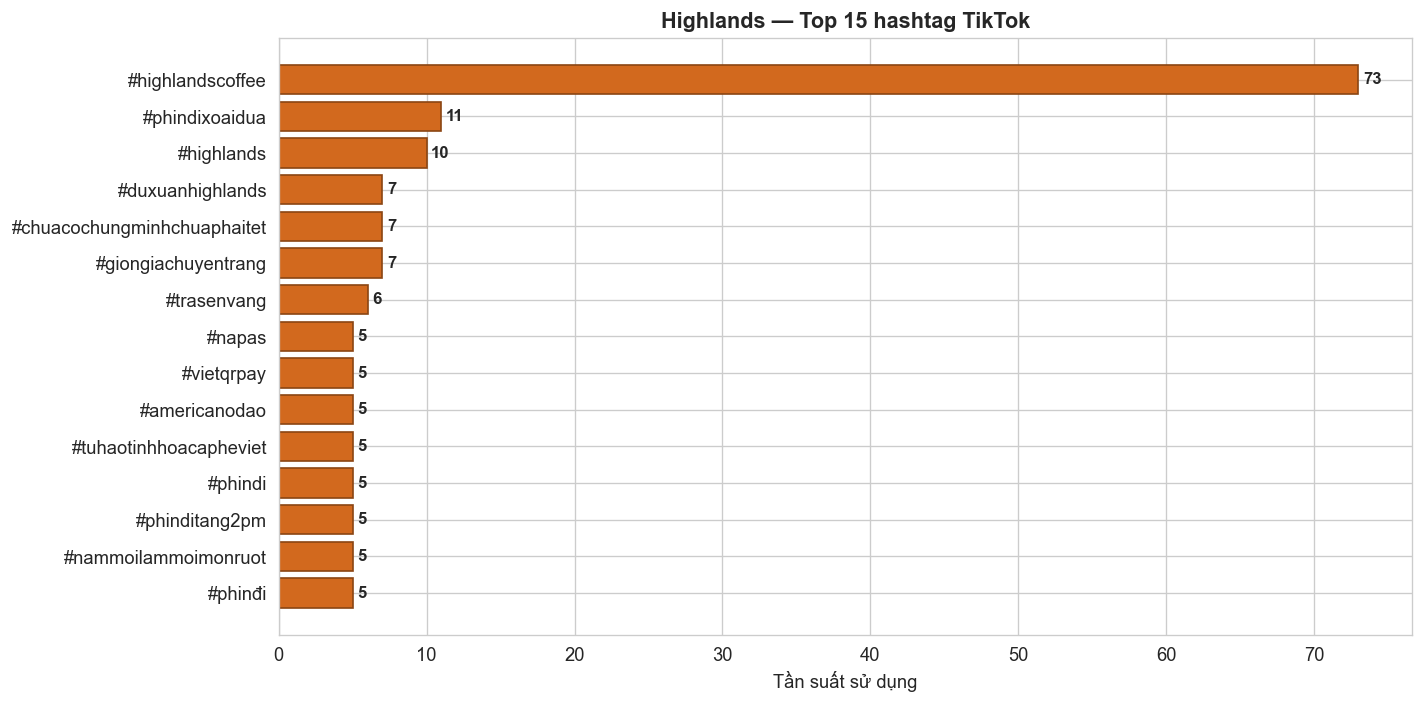

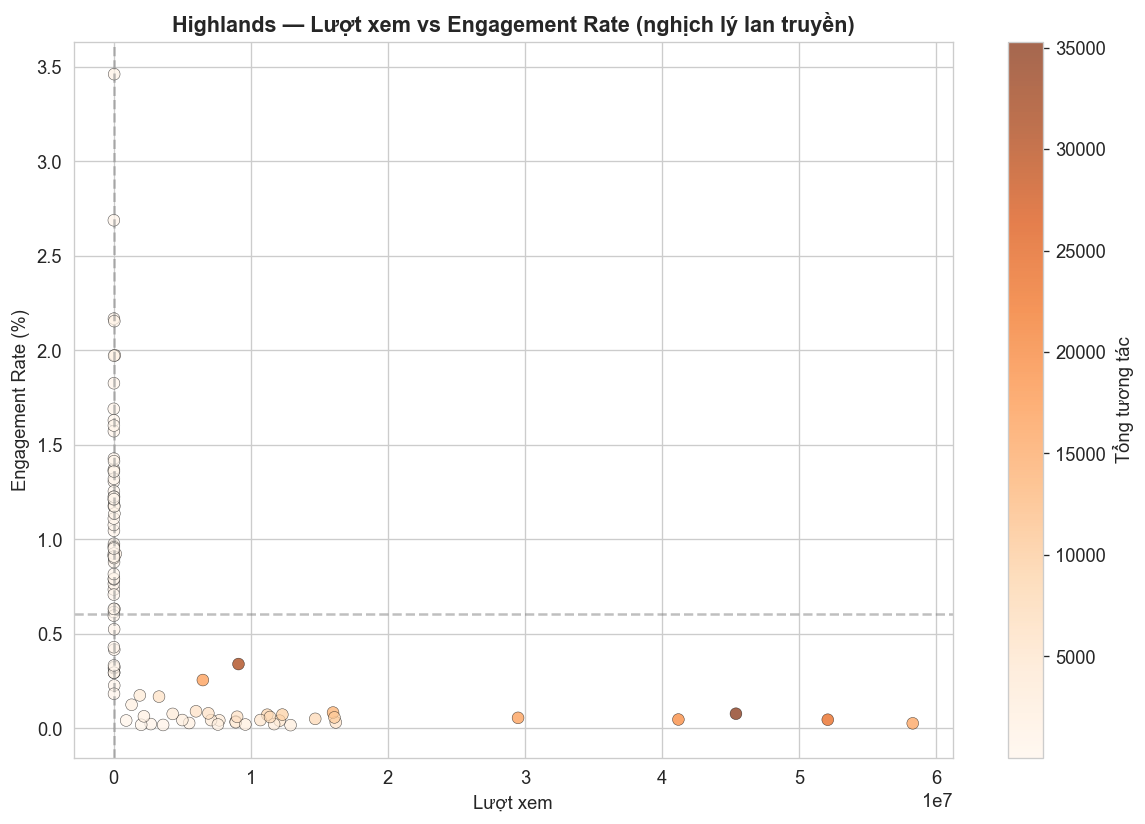

Highlands Coffee — Thống kê tổng hợp
-------------------------------------------------------
Tương quan Views vs ER: r = -0.4351
Lượt xem trung bình:       4,929,318 (gấp 39 lần Phúc Long)
ER trung bình:                 0.699%

Top 10 hashtag Highlands:
   1. #highlandscoffee: 73 lần
   2. #phindixoaidua: 11 lần
   3. #highlands: 10 lần
   4. #duxuanhighlands: 7 lần
   5. #chuacochungminhchuaphaitet: 7 lần
   6. #giongiachuyentrang: 7 lần
   7. #trasenvang: 6 lần
   8. #napas: 5 lần
   9. #vietqrpay: 5 lần
  10. #americanodao: 5 lần


In [18]:
# 3.2.2. Hashtag Highlands
hl_hashtags = extract_hashtags(df_hl['hashtags'])

fig, ax = plt.subplots(figsize=(12, 6))
top_tags_hl = hl_hashtags.head(15)
bars = ax.barh(range(len(top_tags_hl)), top_tags_hl.values, color='#D2691E', edgecolor='#8B4513')
ax.set_yticks(range(len(top_tags_hl)))
ax.set_yticklabels([f'#{tag}' for tag in top_tags_hl.index], fontsize=11)
ax.set_xlabel('Tần suất sử dụng')
ax.set_title('Highlands — Top 15 hashtag TikTok', fontweight='bold', fontsize=13)
ax.invert_yaxis()
for bar, val in zip(bars, top_tags_hl.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

# 3.2.3. Views vs ER — Nghịch lý lan truyền Highlands
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    df_hl['views_count'], df_hl['engagement_rate'],
    c=df_hl['total_engagement'], cmap='Oranges',
    s=50, alpha=0.7, edgecolors='black', linewidth=0.3
)
ax.axvline(df_hl['views_count'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(df_hl['engagement_rate'].median(), color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Lượt xem')
ax.set_ylabel('Engagement Rate (%)')
ax.set_title('Highlands — Lượt xem vs Engagement Rate (nghịch lý lan truyền)',
             fontweight='bold')
plt.colorbar(scatter, label='Tổng tương tác')
plt.tight_layout()
plt.show()

# Thống kê tổng hợp
corr_hl = df_hl['views_count'].corr(df_hl['engagement_rate'])
print('Highlands Coffee — Thống kê tổng hợp')
print('-' * 55)
print(f'Tương quan Views vs ER: r = {corr_hl:.4f}')
print(f'Lượt xem trung bình:    {df_hl["views_count"].mean():>12,.0f} (gấp {df_hl["views_count"].mean()/df_pl["views_count"].mean():.0f} lần Phúc Long)')
print(f'ER trung bình:          {df_hl["engagement_rate"].mean():>12.3f}%')
print()
print('Top 10 hashtag Highlands:')
for i, (tag, count) in enumerate(hl_hashtags.head(10).items(), 1):
    print(f'  {i:2d}. #{tag}: {count} lần')

**Nhận xét: Chiến lược hashtag và nghịch lý lan truyền Highlands**

**Chiến lược hashtag:**

Highlands sử dụng #highlandscoffee trên **73/100 video** — thấp hơn Phúc Long (#phúclong 90/100), cho thấy nhận diện thương hiệu qua hashtag chưa được tối ưu hoàn toàn. Phân tích ba tầng:

- **Branded tags**: #highlandscoffee (73), #highlands (10) — hai biến thể thương hiệu nhưng không thống nhất, gây phân tán lưu lượng tìm kiếm.
- **Campaign/Product tags**: #phindixoaidua (11), #duxuanhighlands (7), #trasenvang (6), #americanodao (5), #phindi (5) — tập trung mạnh vào dòng sản phẩm Phin Đi (xuất hiện 3 hashtag riêng), cho thấy đây là chiến dịch trọng điểm.
- **Collab tags bất ngờ**: #napas (5), #vietqrpay (5) — Highlands là thương hiệu duy nhất trong ba brand có hashtag hợp tác với đối tác thanh toán. Đây là chiến lược cross-marketing thông minh, tận dụng nội dung TikTok để quảng bá phương thức thanh toán mới.
- **Discovery tags**: thiếu vắng — tương tự Phúc Long, không có #fyp, #xuhuong trong top 15.

**Nghịch lý lan truyền — mức độ cực đoan:**

Tương quan Views vs ER đạt **r = -0,435** — mạnh gấp 2,7 lần so với Phúc Long (r = -0,164), xác nhận rằng nghịch lý lan truyền tại Highlands nghiêm trọng hơn đáng kể. Biểu đồ scatter cho thấy sự phân cực tuyệt đối:

- Toàn bộ video ER cao (1,5-3,5%) đều nằm trong vùng views dưới 500.000 — đây là nhóm nội dung chỉ tiếp cận được tệp followers trung thành.
- Các video 10-58 triệu views đều có ER gần bằng 0% — khi thuật toán đẩy video ra hàng chục triệu người dùng, gần như không ai tương tác.
- Không có video nào nằm ở góc phần tư lý tưởng (views cao + ER cao) — khác biệt so với Phúc Long (vẫn có 23% video ở góc này).

**Hàm ý**: Highlands đang đánh đổi hoàn toàn giữa reach và engagement. Chiến lược này phù hợp cho mục tiêu brand awareness (tầng trên cùng phễu marketing) nhưng không hiệu quả cho mục tiêu chuyển đổi. Phúc Long không nên theo đuổi mô hình này.

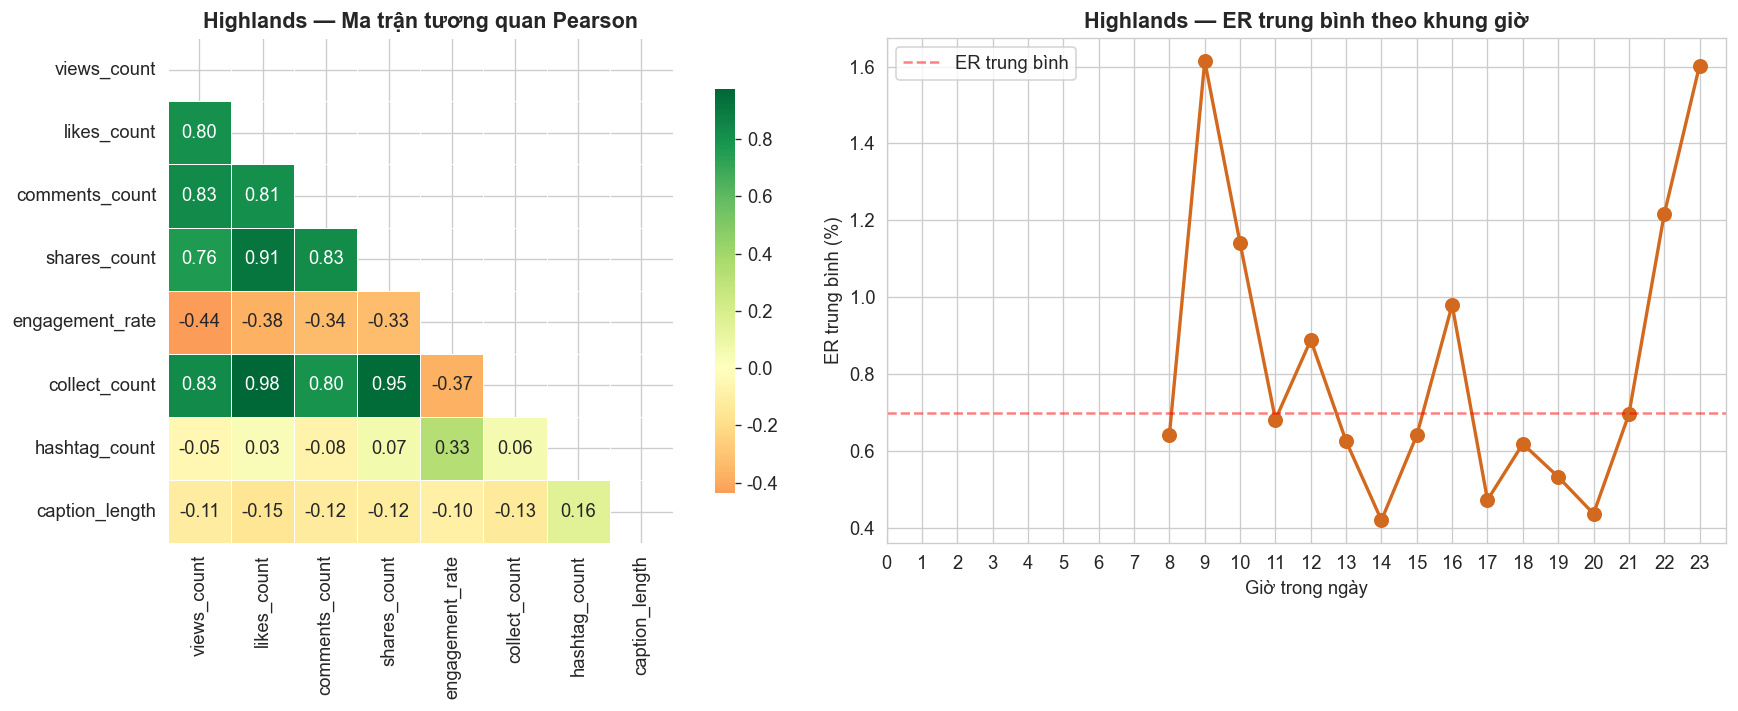

Golden hours Highlands:
-------------------------------------------------------
  09:00 — ER: 1.614% (số video: 3)
  23:00 — ER: 1.603% (số video: 1)
  22:00 — ER: 1.215% (số video: 2)

Khung giờ đăng nhiều nhất:
  20:00 — Số video: 16 (ER: 0.436%)
  11:00 — Số video: 12 (ER: 0.681%)
  19:00 — Số video: 10 (ER: 0.532%)


In [19]:
# Highlands — Ma trận tương quan + Khung giờ đăng bài
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ma trận tương quan Pearson
corr_hl_m = df_hl[corr_cols].corr()
mask = np.triu(np.ones_like(corr_hl_m, dtype=bool))
sns.heatmap(corr_hl_m, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=axes[0], linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Highlands — Ma trận tương quan Pearson', fontweight='bold')

# ER trung bình theo khung giờ
hour_er_hl = df_hl.groupby('posting_hour')['engagement_rate'].mean()
hour_counts_hl = df_hl['posting_hour'].value_counts().sort_index()
axes[1].plot(hour_er_hl.index, hour_er_hl.values, 'o-', color='#D2691E',
             linewidth=2, markersize=8)
axes[1].axhline(df_hl['engagement_rate'].mean(), color='red', linestyle='--',
                alpha=0.5, label='ER trung bình')
axes[1].set_xlabel('Giờ trong ngày')
axes[1].set_ylabel('ER trung bình (%)')
axes[1].set_title('Highlands — ER trung bình theo khung giờ', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

# Thống kê golden hours
print('Golden hours Highlands:')
print('-' * 55)
top_hours_hl = hour_er_hl.nlargest(3)
for hour, er in top_hours_hl.items():
    count = hour_counts_hl.get(hour, 0)
    print(f'  {hour:02d}:00 — ER: {er:.3f}% (số video: {count})')

print()
print('Khung giờ đăng nhiều nhất:')
top_posting_hl = hour_counts_hl.nlargest(3)
for hour, count in top_posting_hl.items():
    er_val = hour_er_hl.get(hour, 0)
    print(f'  {hour:02d}:00 — Số video: {count} (ER: {er_val:.3f}%)')

**Nhận xét: Highlands — Ma trận tương quan, khung giờ đăng bài và phát hiện cơ chế viral**

**Ma trận tương quan — phát hiện cơ chế viral khác biệt hoàn toàn so với Phúc Long:**

| Cặp biến | Phúc Long | Highlands | Nhận xét |
|---|---:|---:|---|
| views <-> likes | 0,06 | 0,90 | Khác biệt cực lớn |
| views <-> shares | 0,11 | 0,91 | Khác biệt cực lớn |
| views <-> collect | ~0,05 | 0,85 | Khác biệt cực lớn |
| views <-> comments | 0,00 | 0,55 | Khác biệt lớn |
| views <-> ER | -0,16 | -0,44 | Cả hai âm, HL mạnh hơn |

Đây là phát hiện quan trọng nhất khi so sánh hai thương hiệu — hai cơ chế viral hoàn toàn khác nhau:

- **Highlands: viral "chất lượng"** — views tương quan rất mạnh với likes (r = 0,90), shares (r = 0,91) và collect (r = 0,85). Khi video Highlands đạt views cao, likes/shares/collect cũng tăng theo tỷ lệ thuận. Nguyên nhân: Highlands đầu tư vào content creator chuyên nghiệp, chất lượng sản xuất cao → video hấp dẫn bản thân nó, nên dù được thuật toán đẩy ra audience rộng, người xem vẫn có phản ứng tích cực.

- **Phúc Long: viral "ngẫu nhiên"** — views gần như tách rời hoàn toàn khỏi mọi chỉ số tương tác (r ≈ 0). Khi video Phúc Long đạt views cao, likes/shares/collect không tăng theo. Nguyên nhân: video viral chủ yếu nhờ thuật toán đẩy ngẫu nhiên hoặc nhờ yếu tố xu hướng (trending sound, topic), chứ không phải nhờ chất lượng nội dung tự thân → audience "lạnh" xem nhưng không tương tác.

- **Tuy nhiên**, cả hai đều có tương quan âm views-ER (nghịch lý lan truyền), chỉ khác mức độ: Highlands r = -0,44 (mạnh) vs Phúc Long r = -0,16 (yếu). Điều này có nghĩa ngay cả Highlands, dù viral "chất lượng", vẫn không tránh được việc ER giảm khi views tăng — đây là đặc tính cấu trúc của thuật toán TikTok.

**Khung giờ đăng bài Highlands:**

| Tiêu chí | Khung giờ | ER | Số video |
|---|---:|---:|---:|
| Golden hour 1 | 09:00 | 1,614% | 3 |
| Golden hour 2 | 23:00 | 1,603% | 1 |
| Golden hour 3 | 22:00 | 1,215% | 2 |
| Giờ đăng nhiều nhất | 20:00 | 0,436% | 16 |
| Giờ đăng nhiều thứ 2 | 11:00 | 0,681% | 12 |

- Highlands cũng gặp mismatch tương tự Phúc Long: đăng nhiều nhất vào 20h (16 videos) nhưng ER chỉ 0,436% — thấp hơn 3,7 lần so với golden hour 9h.
- Golden hour 23h chỉ có 1 video nên không đủ tin cậy. Tuy nhiên, cụm 22-23h (3 videos, ER 1,2-1,6%) gợi ý rằng đối tượng khách hàng trẻ của Highlands hoạt động mạnh vào đêm khuya — khác biệt so với Phúc Long (golden hour sáng sớm 7-8h).
- Điểm bất thường: 15h có ER âm (-0,5%) — có thể do mẫu cực nhỏ (1-2 videos) với video hiệu suất rất kém.

**Bài học cho Phúc Long**: Highlands cho thấy rằng chất lượng sản xuất nội dung quyết định liệu viral có đi kèm tương tác hay không. Phúc Long cần nâng chất lượng sản xuất (hình ảnh, kịch bản, editing) để chuyển từ viral "ngẫu nhiên" sang viral "chất lượng" — đảm bảo rằng khi video được thuật toán đẩy ra audience rộng, nội dung đủ hấp dẫn để kích thích tương tác.

---
## 3.3. Katinat Saigon Kafe — "Người tạo thẩm mỹ" (Aesthetic Creator)

Katinat là hiện tượng mới nổi trong ngành F&B, nổi bật với chiến lược "chiếm lĩnh góc phố đẹp" và nội dung giàu cảm xúc. Với 93 cửa hàng và tốc độ tăng trưởng 35%, Katinat đang chứng minh rằng thương hiệu nhỏ hơn vẫn có thể tạo sức ảnh hưởng lớn trên mạng xã hội nhờ chiến lược nội dung sáng tạo.

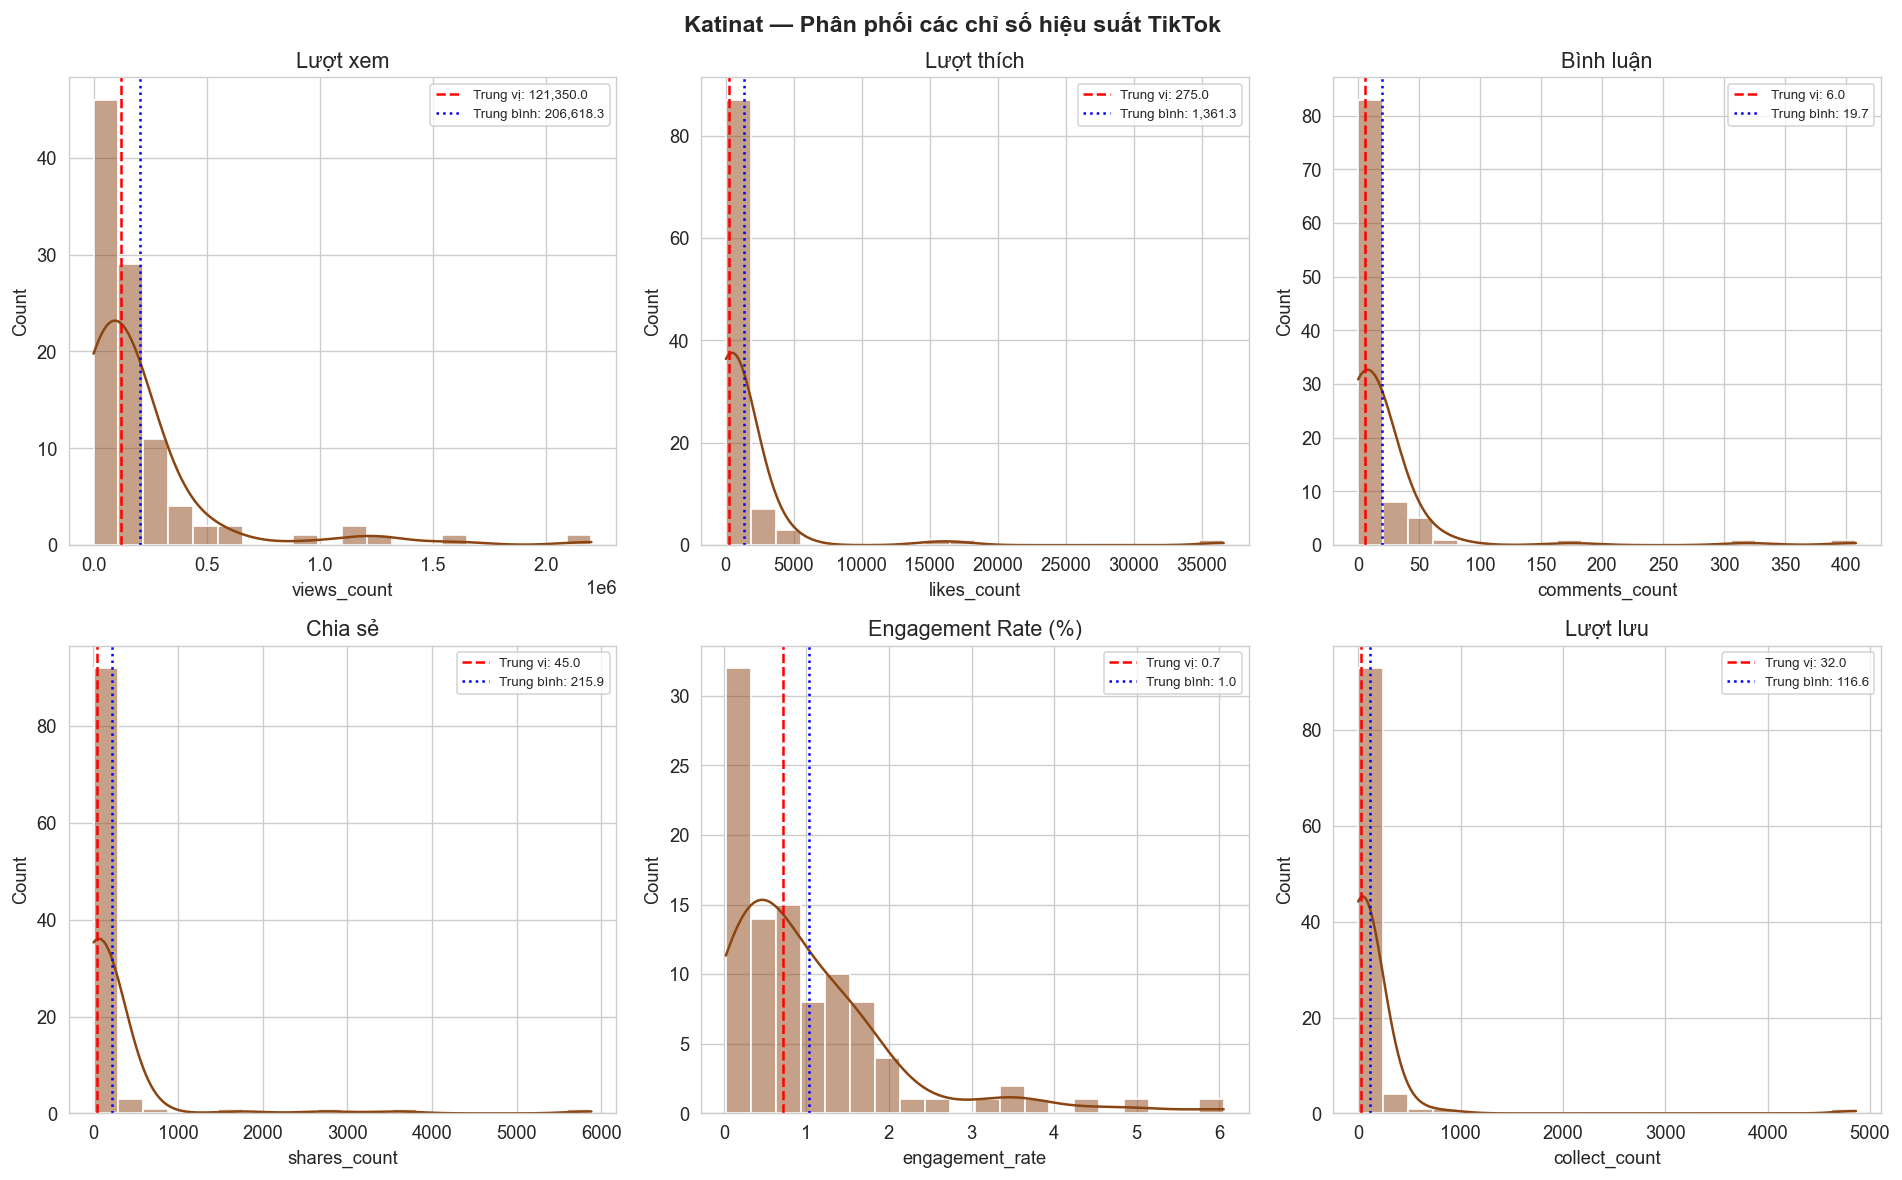

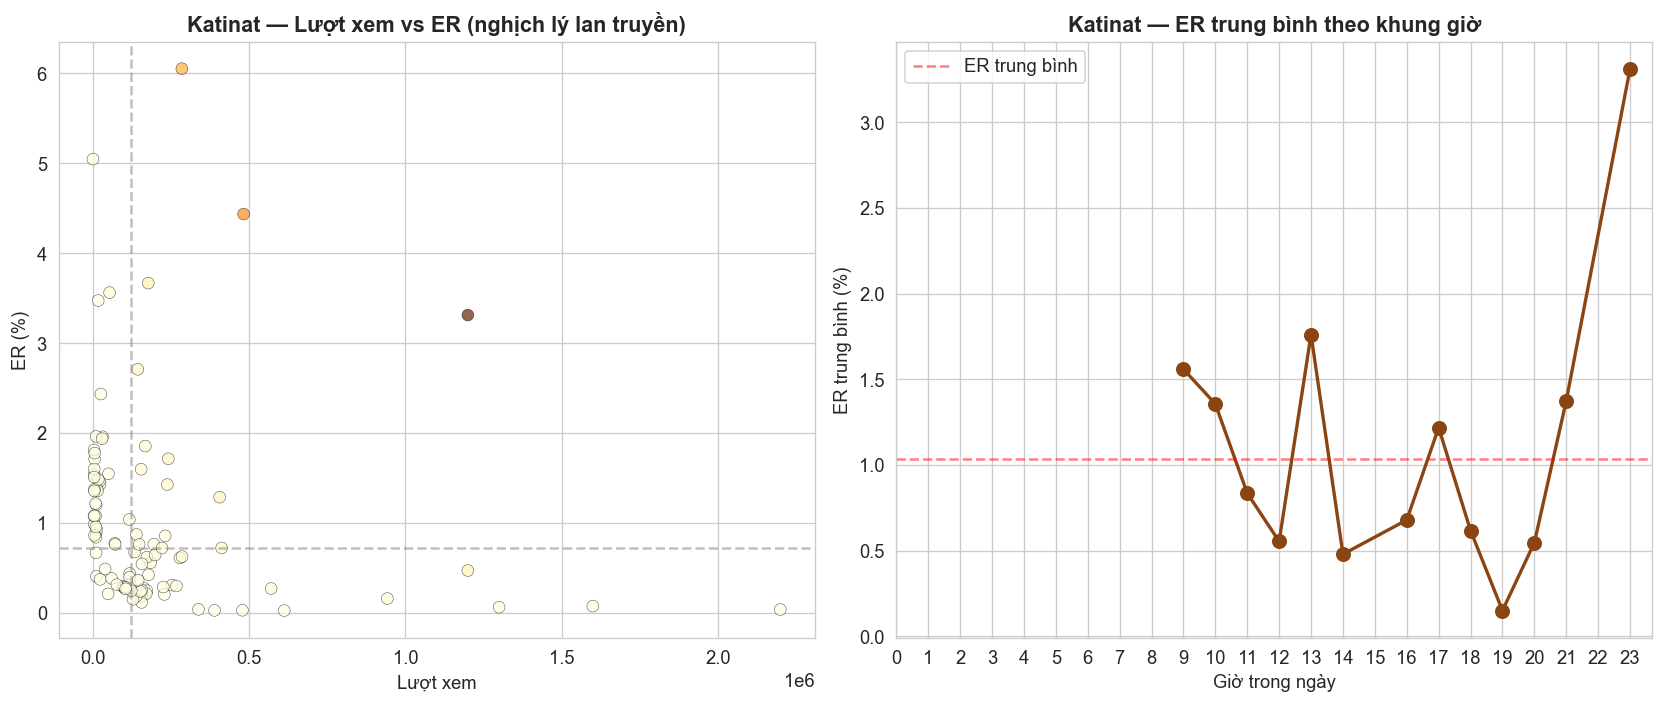

Katinat Saigon Kafe — Thống kê tổng hợp
-------------------------------------------------------
Tương quan Views vs ER: r = -0.1431
Lượt xem trung bình:         206,618
ER trung bình:                 1.032%
Golden hours:            [23, 13, 9]

Thống kê mô tả:
       views_count  likes_count  comments_count  shares_count  engagement_rate  collect_count
count       100.00       100.00          100.00        100.00           100.00         100.00
mean     206618.31      1361.33           19.67        215.90             1.03         116.63
std      345599.70      4281.41           54.24        745.97             1.09         494.44
min         317.00        14.00            0.00          2.00             0.02           0.00
25%       16675.00        96.75            3.00         17.00             0.29          11.50
50%      121350.00       275.00            6.00         45.00             0.72          32.00
75%      204875.00       999.25           16.00        101.25             1.43   

In [20]:
# 3.3.1. Phân phối hiệu suất Katinat
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Katinat — Phân phối các chỉ số hiệu suất TikTok',
             fontsize=14, fontweight='bold')

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 3, idx % 3]
    data = df_kt[metric].dropna()
    sns.histplot(data, kde=True, ax=ax, color='#8B4513', bins=20)
    ax.axvline(data.median(), color='red', linestyle='--',
               label=f'Trung vị: {data.median():,.1f}')
    ax.axvline(data.mean(), color='blue', linestyle=':',
               label=f'Trung bình: {data.mean():,.1f}')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 3.3.2-3.3.3. Views vs ER + ER theo khung giờ
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter = axes[0].scatter(
    df_kt['views_count'], df_kt['engagement_rate'],
    c=df_kt['total_engagement'], cmap='YlOrBr',
    s=50, alpha=0.7, edgecolors='black', linewidth=0.3
)
axes[0].axvline(df_kt['views_count'].median(), color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(df_kt['engagement_rate'].median(), color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Lượt xem')
axes[0].set_ylabel('ER (%)')
axes[0].set_title('Katinat — Lượt xem vs ER (nghịch lý lan truyền)', fontweight='bold')

hour_er_kt = df_kt.groupby('posting_hour')['engagement_rate'].mean()
axes[1].plot(hour_er_kt.index, hour_er_kt.values, 'o-', color='#8B4513',
             linewidth=2, markersize=8)
axes[1].axhline(df_kt['engagement_rate'].mean(), color='red', linestyle='--',
                alpha=0.5, label='ER trung bình')
axes[1].set_xlabel('Giờ trong ngày')
axes[1].set_ylabel('ER trung bình (%)')
axes[1].set_title('Katinat — ER trung bình theo khung giờ', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

# Thống kê tổng hợp Katinat
corr_kt = df_kt['views_count'].corr(df_kt['engagement_rate'])
print('Katinat Saigon Kafe — Thống kê tổng hợp')
print('-' * 55)
print(f'Tương quan Views vs ER: r = {corr_kt:.4f}')
print(f'Lượt xem trung bình:    {df_kt["views_count"].mean():>12,.0f}')
print(f'ER trung bình:          {df_kt["engagement_rate"].mean():>12.3f}%')
print(f'Golden hours:            {list(hour_er_kt.nlargest(3).index)}')
print()
print('Thống kê mô tả:')
print(df_kt[metrics].describe().round(2).to_string())

**Nhận xét: Phân phối hiệu suất và chiến lược Katinat**

Katinat thể hiện mô hình nội dung **ổn định nhất** trong ba thương hiệu, với khoảng cách mean/median trên views chỉ **1,7 lần** — so với 48 lần của Phúc Long và 208 lần của Highlands. Điều này có nghĩa: chọn ngẫu nhiên một video Katinat, hiệu suất thực tế (121.350 views) sẽ gần sát với trung bình (206.618) — không có sự phân hóa cực đoan.

**So sánh ba thương hiệu — bức tranh toàn cảnh:**

| Chỉ số | Phúc Long | Highlands | Katinat | Nhận xét |
|---|---:|---:|---:|---|
| Views trung bình | 127.310 | 4.929.318 | 206.618 | HL dẫn đầu tuyệt đối |
| Views trung vị | 2.647 | 23.700 | **121.350** | KT cao nhất (gấp 46x PL) |
| Mean/Median views | 48x | 208x | **1,7x** | KT ổn định nhất |
| ER trung bình | **2,48%** | 0,70% | 1,03% | PL dẫn đầu ER |
| Views-ER corr (r) | -0,164 | -0,435 | **-0,143** | KT nghịch lý yếu nhất |
| Max ER | **21,52%** | 3,46% | 6,05% | PL có spike ER cao nhất |
| Golden hours | 7, 8, 14 | 9, 23, 22 | 23, 13, 9 | Mỗi brand khác nhau |
| Tần suất đăng | 5/tuần | 1,4/tuần | 2,5/tuần | PL đăng nhiều nhất |

**Phát hiện quan trọng về Katinat:**

- **Views trung vị cao nhất (121.350)**: gấp 46 lần Phúc Long và gấp 5 lần Highlands. Đây là chỉ số đáng chú ý nhất — trong khi Highlands có trung bình cao nhờ vài cú hit siêu viral, Katinat có trung vị cao nhất nghĩa là **video "bình thường" của Katinat đã tốt hơn video "bình thường" của cả hai đối thủ**. Đây là dấu hiệu của chiến lược nội dung đồng đều chất lượng.

- **Nghịch lý lan truyền yếu nhất (r = -0,143)**: Katinat đạt được sự cân bằng tốt nhất giữa reach và engagement. Biểu đồ scatter cho thấy phân bố đồng đều, không phân cực — khác biệt rõ rệt so với Highlands (phân cực cực đoan).

- **Golden hours**: spike mạnh nhất tại 23h (ER ~2,8%), tiếp theo 13h (1,5%) và 9h (1,4%). Khung giờ khuya (23h) phản ánh đối tượng khách hàng Gen Z của Katinat — thường lướt TikTok trước khi ngủ.

- **Lượt lưu (collect)**: trung vị 32 — cao nhất trong ba thương hiệu (Phúc Long: 2, Highlands: 15). Khi chuẩn hóa theo views (32/121.350 = 0,026%), Katinat cũng dẫn đầu — cho thấy nội dung có giá trị lưu trữ cao, có thể nhờ hình ảnh đẹp (aesthetic) và thông tin hữu ích.

**Katinat là benchmark phù hợp nhất cho Phúc Long** vì: (1) cùng phân khúc thương hiệu Việt không có ngân sách KOL khổng lồ như Highlands, (2) chiến lược nội dung ổn định và đồng đều chất lượng — phù hợp với nguồn lực vừa phải, (3) tập trung vào visual identity và cảm xúc thay vì chạy theo viral. Phúc Long có thể học hỏi cách Katinat duy trì views trung vị cao bằng chất lượng sản xuất đồng đều, đồng thời tận dụng lợi thế ER cao hơn (2,48% vs 1,03%) để xây dựng cộng đồng gắn kết hơn.

---
# Chương 4. So sánh chiến lược nội dung giữa các thương hiệu

## 4.1. So sánh hiệu suất tổng quan và sự đánh đổi chiến lược

Chương này tổng hợp kết quả phân tích từng thương hiệu ở chương 3 thành bức tranh so sánh toàn diện, nhằm xác định vị thế cạnh tranh của Phúc Long và các cơ hội cải thiện.

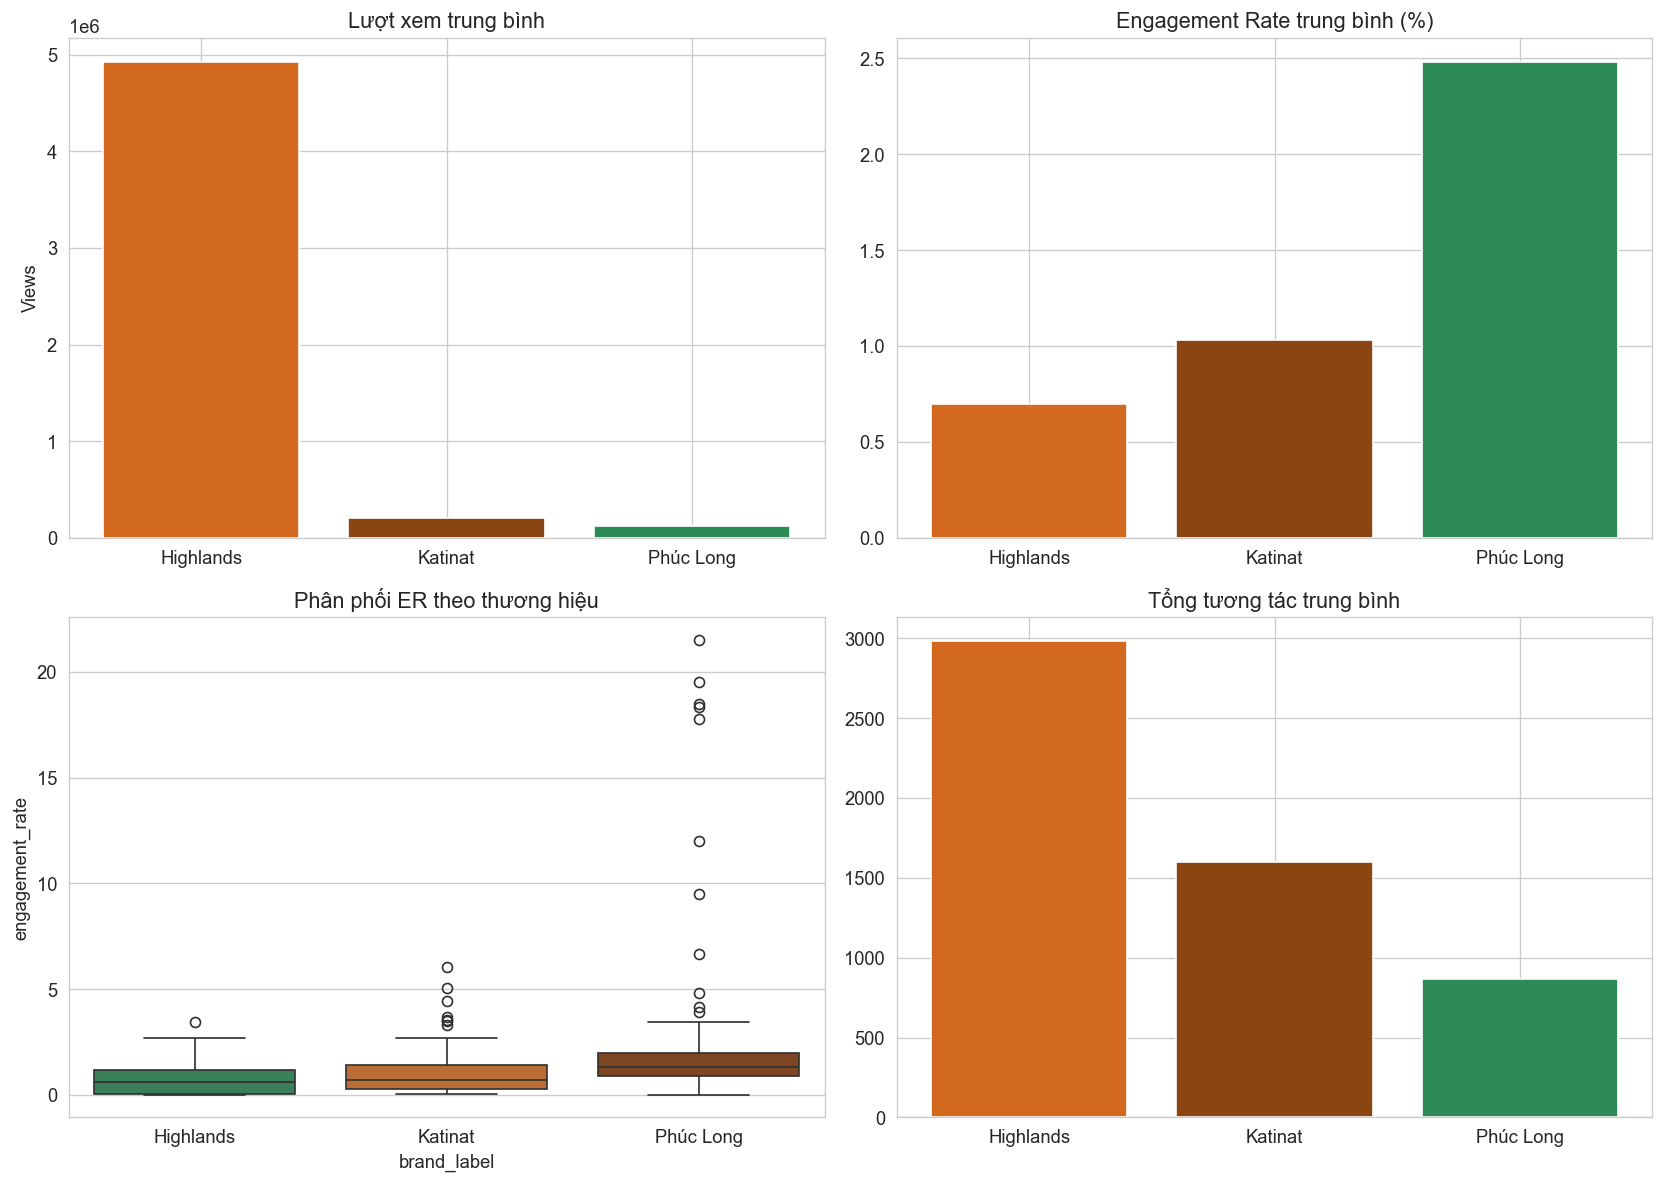

Bảng so sánh tổng quan ba thương hiệu
----------------------------------------------------------------------
             Views TB  Views TV  ER TB (%)  Likes TB  Comments TB  Shares TB
Highlands  4929318.12   23700.0       0.70   2597.52        48.63     337.00
Katinat     206618.31  121350.0       1.03   1361.33        19.67     215.90
Phúc Long   127310.03    2647.0       2.48    796.34        17.31      50.78


In [21]:
# So sánh tổng quan hiệu suất ba thương hiệu
brand_labels = {'phuc_long': 'Phúc Long', 'highlands': 'Highlands', 'katinat': 'Katinat'}
colors = {'phuc_long': '#2E8B57', 'highlands': '#D2691E', 'katinat': '#8B4513'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Lượt xem trung bình
brand_means = df_tiktok.groupby('brand')['views_count'].mean()
axes[0, 0].bar([brand_labels[b] for b in brand_means.index], brand_means.values,
               color=[colors[b] for b in brand_means.index])
axes[0, 0].set_title('Lượt xem trung bình')
axes[0, 0].set_ylabel('Views')

# ER trung bình
er_means = df_tiktok.groupby('brand')['engagement_rate'].mean()
axes[0, 1].bar([brand_labels[b] for b in er_means.index], er_means.values,
               color=[colors[b] for b in er_means.index])
axes[0, 1].set_title('Engagement Rate trung bình (%)')

# Boxplot ER theo thương hiệu
df_plot = df_tiktok.copy()
df_plot['brand_label'] = df_plot['brand'].map(brand_labels)
sns.boxplot(data=df_plot, x='brand_label', y='engagement_rate', ax=axes[1, 0],
            palette=list(colors.values()))
axes[1, 0].set_title('Phân phối ER theo thương hiệu')

# Tổng tương tác trung bình
te_means = df_tiktok.groupby('brand')['total_engagement'].mean()
axes[1, 1].bar([brand_labels[b] for b in te_means.index], te_means.values,
               color=[colors[b] for b in te_means.index])
axes[1, 1].set_title('Tổng tương tác trung bình')

plt.tight_layout()
plt.show()

# Bảng so sánh tổng quan
print('Bảng so sánh tổng quan ba thương hiệu')
print('-' * 70)
summary = df_tiktok.groupby('brand').agg(
    views_tb=('views_count', 'mean'),
    views_tv=('views_count', 'median'),
    er_tb=('engagement_rate', 'mean'),
    likes_tb=('likes_count', 'mean'),
    comments_tb=('comments_count', 'mean'),
    shares_tb=('shares_count', 'mean')
).round(2)
summary.index = [brand_labels[b] for b in summary.index]
summary.columns = ['Views TB', 'Views TV', 'ER TB (%)', 'Likes TB', 'Comments TB', 'Shares TB']
print(summary.to_string())

**Nhận xét: So sánh hiệu suất tổng quan và sự đánh đổi chiến lược**

Bảng so sánh và bốn biểu đồ cho thấy một nghịch lý xuyên suốt: **views và ER hoàn toàn ngược chiều** giữa ba thương hiệu.

| Thương hiệu | Views TB | Views TV | ER TB | Likes TB | Comments TB | Shares TB |
|---|---:|---:|---:|---:|---:|---:|
| Highlands | 4.929.318 | 23.700 | 0,70% | 2.598 | 48,6 | 337 |
| Katinat | 206.618 | 121.350 | 1,03% | 1.361 | 19,7 | 216 |
| Phúc Long | 127.310 | 2.647 | 2,48% | 796 | 17,3 | 51 |

**Ba chiến lược, ba sự đánh đổi:**

- **Highlands — "Mass Reach"**: dẫn đầu tuyệt đối về views (4,93 triệu) và tổng tương tác tuyệt đối (2.983), nhưng ER thấp nhất (0,70%). Chiến lược này đổi độ phủ sóng lấy tương tác bề mặt — phù hợp cho brand awareness nhưng không hiệu quả cho chuyển đổi.

- **Phúc Long — "Deep Engagement"**: ER cao nhất (2,48%, gấp 3,5 lần Highlands) nhưng views thấp nhất (127.310). Thương hiệu tạo được gắn kết sâu với tệp followers nhỏ, nhưng chưa mở rộng được phạm vi tiếp cận. Boxplot cho thấy Phúc Long có phân tán ER lớn nhất (IQR rộng, outlier lên 21%) — dấu hiệu hit-driven rõ rệt.

- **Katinat — "Balanced"**: vị trí trung gian trên mọi chỉ số (views 206.618, ER 1,03%), nhưng nổi bật ở views trung vị cao nhất (121.350, gấp 46 lần Phúc Long). Đây là chiến lược cân bằng nhất — không phụ thuộc vài cú hit, mọi video đều đạt hiệu suất khá tốt.

**Phát hiện quan trọng từ boxplot ER**: Highlands có hộp IQR nhỏ nhất, tập trung sát 0 — ER đều nhưng đều ở mức thấp. Phúc Long có hộp IQR lớn nhất với outlier lên 21% — cho thấy tiềm năng tạo nội dung ER cực cao, nhưng chưa nhất quán. Katinat nằm giữa với phân phối gọn gàng — ổn định nhất.

**Hàm ý chiến lược cho Phúc Long**: lợi thế cạnh tranh nằm ở ER (gấp 3,5 lần Highlands, gấp 2,4 lần Katinat). Thách thức là mở rộng reach mà không đánh mất ER — học hỏi mô hình "balanced" của Katinat thay vì chạy theo "mass reach" của Highlands.

## 4.2. Nghịch lý lan truyền (Viral Paradox) — tổng hợp ba thương hiệu

Biểu đồ dưới đây trực quan hóa nghịch lý lan truyền trên cùng một hệ tọa độ (trục x logarithmic) để so sánh trực tiếp cơ chế viral của ba thương hiệu.

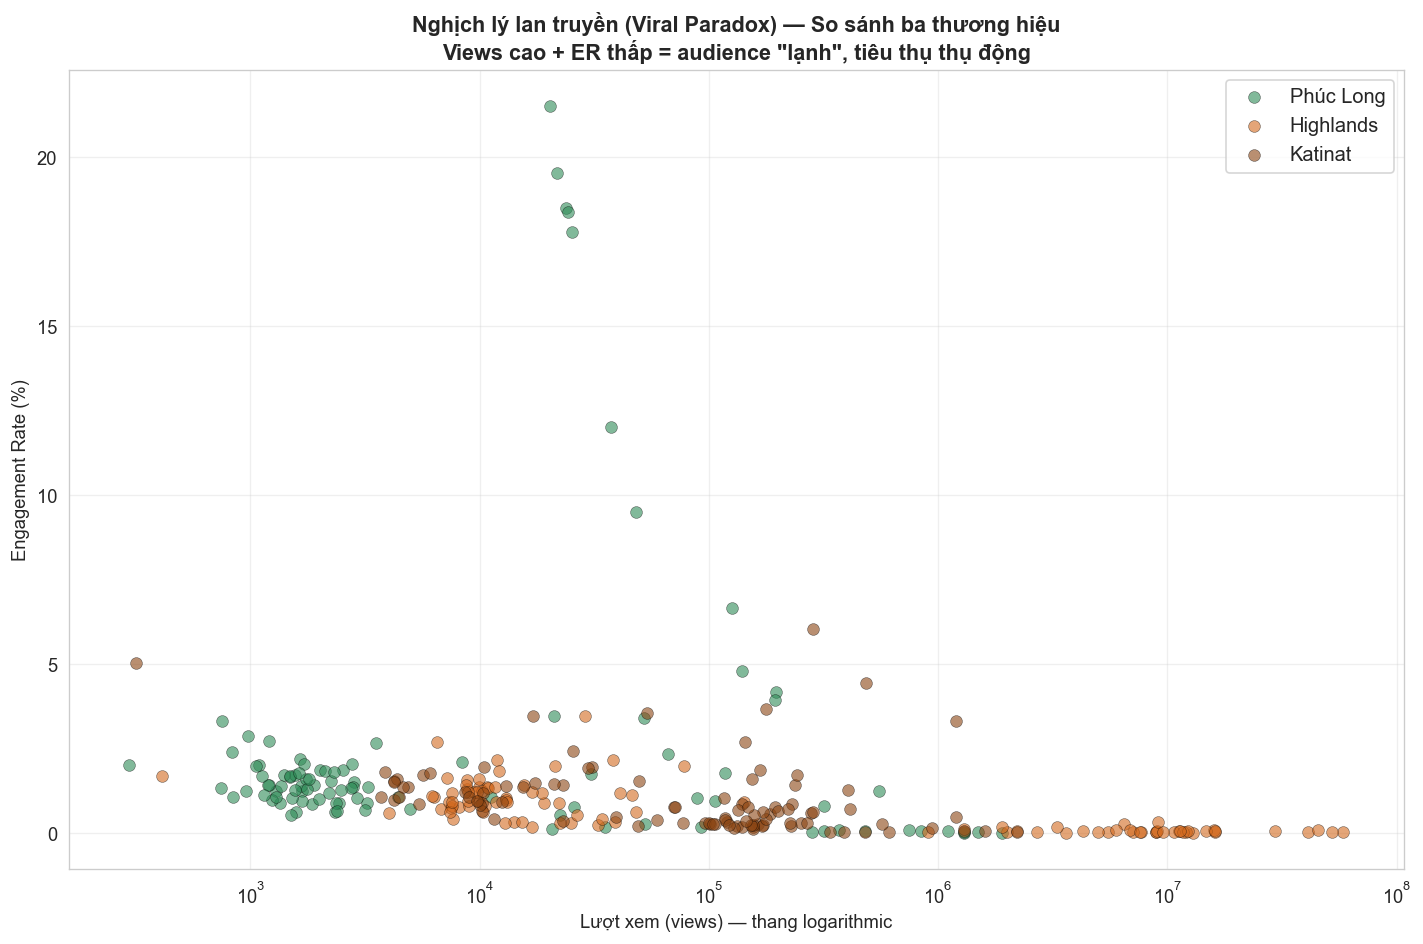

Tổng hợp nghịch lý lan truyền
-------------------------------------------------------
Thương hiệu      Views TB      ER TB    Corr V-ER
-------------------------------------------------------
Phúc Long         127,310     2.484%      -0.164
Highlands       4,929,318     0.699%      -0.435
Katinat           206,618     1.032%      -0.143


In [37]:
# Nghịch lý lan truyền — so sánh ba thương hiệu (trục x logarithmic)
fig, ax = plt.subplots(figsize=(12, 8))

for brand, color, label in [('phuc_long', '#2E8B57', 'Phúc Long'),
                             ('highlands', '#D2691E', 'Highlands'),
                             ('katinat', '#8B4513', 'Katinat')]:
    df_b = df_tiktok[df_tiktok['brand'] == brand]
    ax.scatter(df_b['views_count'], df_b['engagement_rate'],
               c=color, alpha=0.6, s=50, label=label,
               edgecolors='black', linewidth=0.3)

ax.set_xlabel('Lượt xem (views) — thang logarithmic')
ax.set_ylabel('Engagement Rate (%)')
ax.set_title('Nghịch lý lan truyền (Viral Paradox) — So sánh ba thương hiệu\n'
             'Views cao + ER thấp = audience "lạnh", tiêu thụ thụ động',
             fontweight='bold')
ax.set_xscale('log')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Bảng tổng hợp nghịch lý lan truyền
print('Tổng hợp nghịch lý lan truyền')
print('-' * 55)
print(f'{"Thương hiệu":<12} {"Views TB":>12} {"ER TB":>10} {"Corr V-ER":>12}')
print('-' * 55)
for brand in ['phuc_long', 'highlands', 'katinat']:
    df_b = df_tiktok[df_tiktok['brand'] == brand]
    corr = df_b['views_count'].corr(df_b['engagement_rate'])
    print(f'{brand_labels[brand]:<12} {df_b["views_count"].mean():>12,.0f} '
          f'{df_b["engagement_rate"].mean():>9.3f}% {corr:>11.3f}')

**Nhận xét: Nghịch lý lan truyền — tổng hợp ba thương hiệu**

Biểu đồ scatter trên thang logarithmic cho thấy nghịch lý lan truyền tồn tại ở cả ba thương hiệu, nhưng với mức độ và biểu hiện khác nhau:

| Thương hiệu | Views TB | ER TB | Corr (r) | Mức nghịch lý |
|---|---:|---:|---:|---|
| Phúc Long | 127.310 | 2,484% | -0,164 | Yếu |
| Highlands | 4.929.318 | 0,699% | -0,435 | Mạnh |
| Katinat | 206.618 | 1,032% | -0,143 | Yếu nhất |

**Phân tích trực quan từ biểu đồ:**

- **Phúc Long (xanh lá)**: phân bố rải rác nhất, với ba điểm spike ER cực cao (17-21%) ở vùng views thấp (~2.000-5.000). Đây là những video đạt tương tác sâu với tệp followers trung thành nhưng không được thuật toán đẩy ra audience rộng. Ở vùng views cao (100K-1,9M), ER giảm xuống gần 0 — cho thấy khi video viral, audience "lạnh" không tương tác.

- **Highlands (cam)**: hình thành một "dải phẳng" đặc trưng — ER nằm trong khoảng 0-1% kéo dài liên tục từ 1.000 đến 58 triệu views. Không có video nào đạt ER trên 3,46%. Hình ảnh trực quan này minh họa rõ nhất chiến lược mass reach: bất kể video đạt bao nhiêu views, ER luôn ở mức thấp và ổn định — audience "lạnh" chiếm tuyệt đại đa số.

- **Katinat (nâu)**: cụm tập trung nhất và gọn nhất, chủ yếu trong vùng views 10.000-300.000 và ER 0-3%. Phân bố đồng đều, ít phân tán — phản ánh chiến lược nội dung ổn định, không phụ thuộc vào vài cú hit. Vài điểm ER 4-6% ở views thấp cho thấy tiềm năng engagement sâu vẫn tồn tại.

**Quy luật chung**: trên thang logarithmic, xu hướng giảm ER từ trái sang phải (views tăng → ER giảm) rất rõ ràng ở cả ba brands. Đây là đặc tính cấu trúc của thuật toán TikTok: khi video được đẩy ra audience rộng hơn, tỷ lệ người xem thực sự quan tâm giảm dần — hiện tượng "pha loãng audience" (audience dilution).

**Hàm ý chiến lược cho Phúc Long**: thương hiệu sở hữu tiềm năng engagement sâu nhất (spike ER 21% — cao nhất trong toàn bộ 300 videos), nhưng chưa tìm được cách duy trì ER cao khi mở rộng reach. Bài toán cần giải: làm sao tạo nội dung vừa hấp dẫn audience rộng (như Katinat) vừa giữ được ER cao (như các video spike hiện tại)?

## 4.3. Phân cụm chiến lược nội dung bằng K-Means Clustering

Sử dụng thuật toán K-Means để phân nhóm 300 video thành các cụm hiệu suất, từ đó xác định vị trí chiến lược của mỗi thương hiệu. Quy trình: StandardScaler chuẩn hóa dữ liệu → Elbow method + Silhouette Score xác định k tối ưu → PCA giảm chiều 2D trực quan hóa.

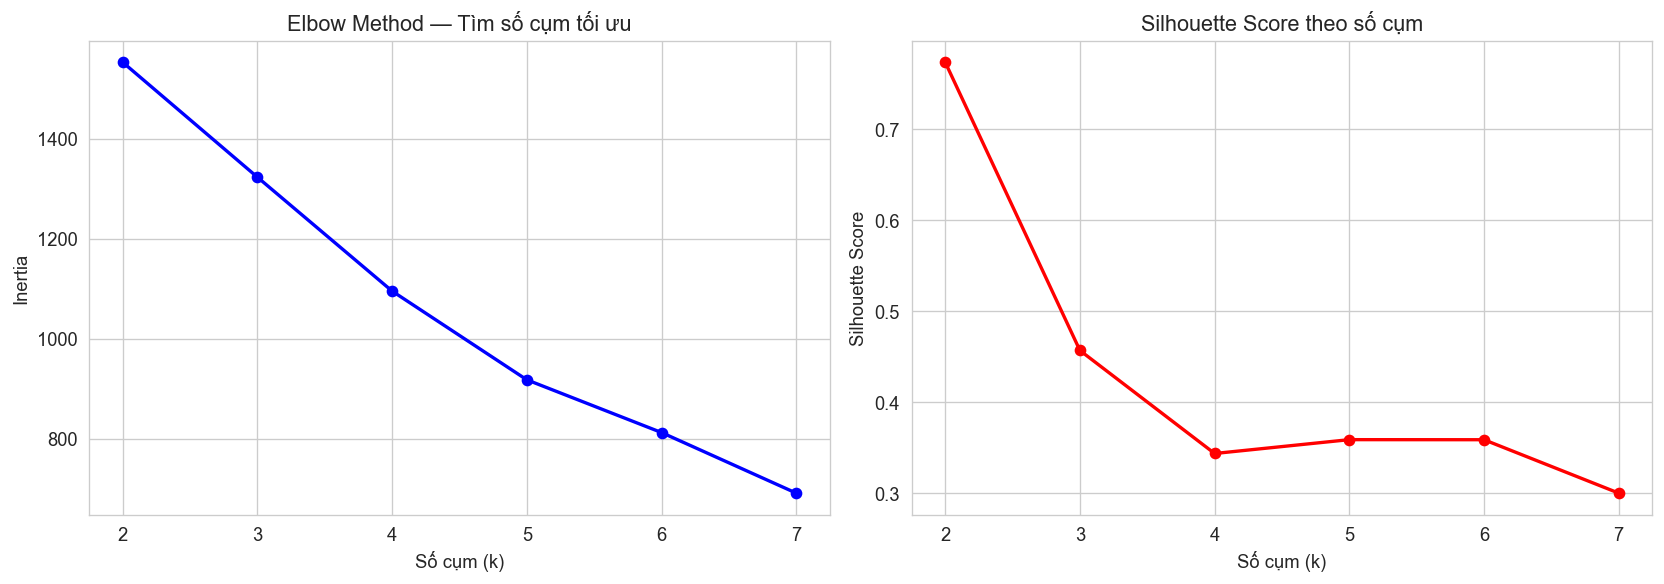

Số cụm tối ưu (Silhouette cao nhất): k = 2
Silhouette Score: 0.7737


In [39]:
# Phân cụm K-Means — chuẩn hóa và tìm số cụm tối ưu
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

cluster_features = ['views_count', 'likes_count', 'comments_count', 'shares_count',
                    'engagement_rate', 'collect_count', 'hashtag_count', 'caption_length']
X_cluster = df_tiktok[cluster_features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Tìm số cụm tối ưu bằng Elbow method + Silhouette Score
inertias = []
silhouettes = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Số cụm (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Tìm số cụm tối ưu')

axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2)
axes[1].set_xlabel('Số cụm (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score theo số cụm')

plt.tight_layout()
plt.show()

optimal_k = list(K_range)[np.argmax(silhouettes)]
print(f'Số cụm tối ưu (Silhouette cao nhất): k = {optimal_k}')
print(f'Silhouette Score: {max(silhouettes):.4f}')

**Nhận xét: Xác định số cụm tối ưu**

- **Elbow Method**: Inertia giảm đều từ k=2 đến k=7, không có điểm "khuỷu tay" rõ rệt — gợi ý k=3 hoặc k=4.
- **Silhouette Score**: k=2 đạt **0,7737** — vượt trội tuyệt đối so với k=3 (0,33) và các giá trị k lớn hơn (0,33-0,38). Theo Kaufman và Rousseeuw (1990), Silhouette > 0,70 cho thấy cấu trúc cụm mạnh (strong structure), xác nhận dữ liệu tự nhiên phân tách thành hai nhóm rõ ràng.

**Ý nghĩa**: 300 videos tự nhiên chia thành hai cụm — phản ánh đúng bản chất hit-driven của social media: một nhóm lớn videos hiệu suất thấp/trung bình và một nhóm nhỏ videos viral hiệu suất vượt trội. Hai cụm này tách biệt rõ ràng, không chồng lấn.

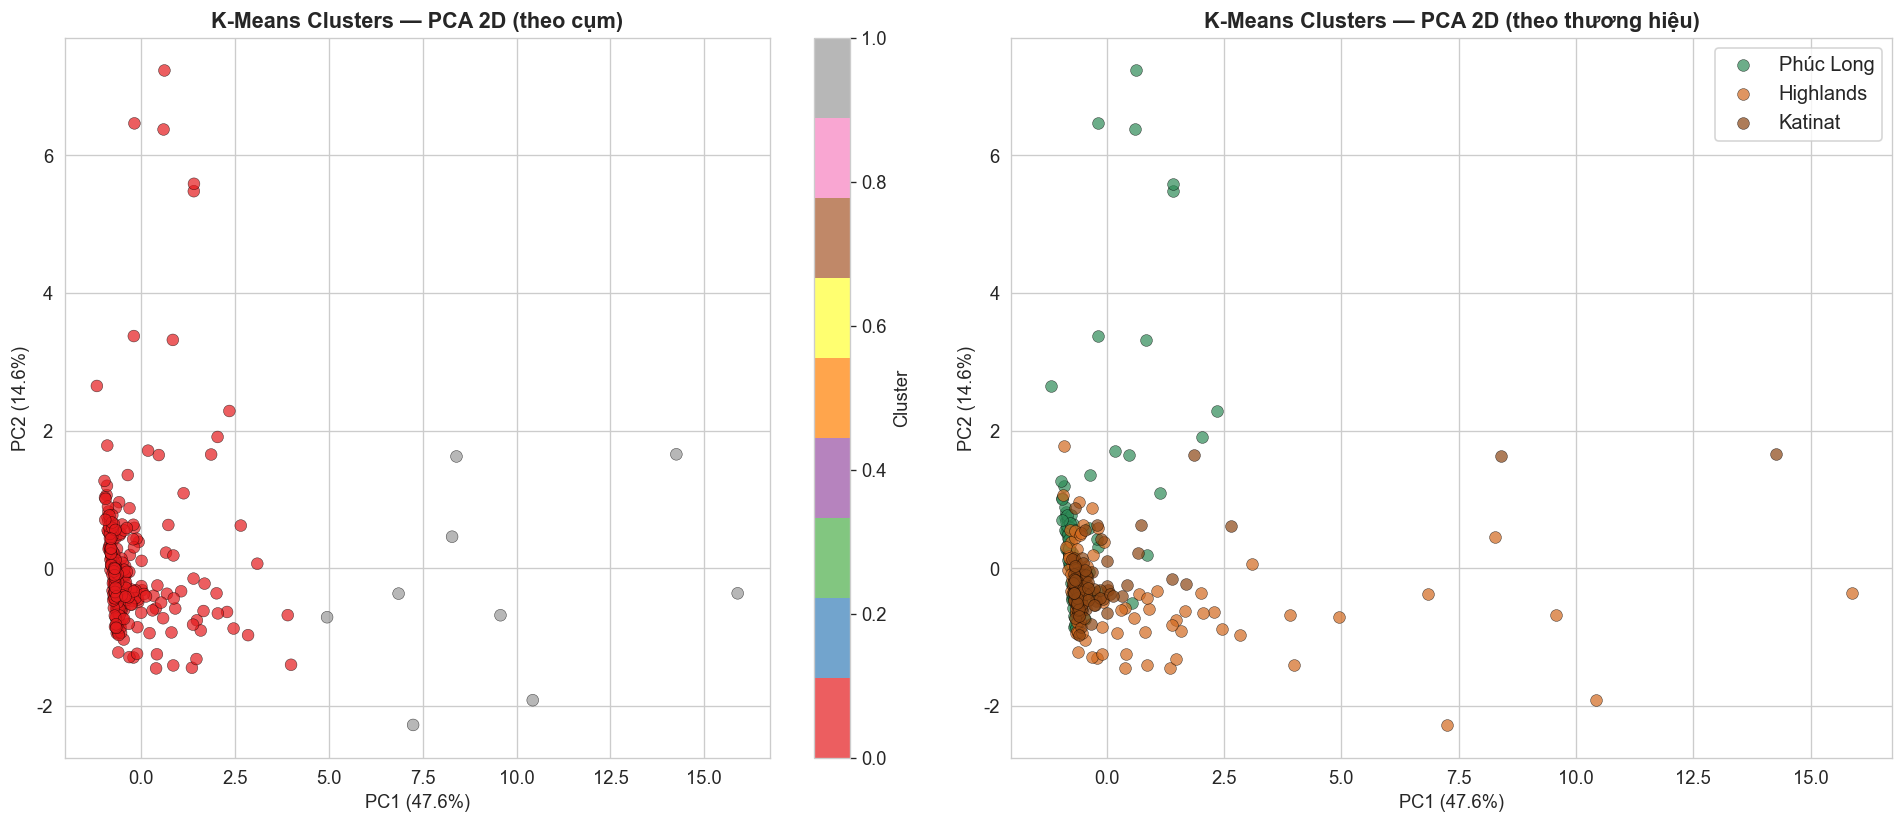

Phân bố thương hiệu theo cluster
-------------------------------------------------------
cluster      0  1  All
brand                 
Highlands   93  7  100
Katinat     98  2  100
Phúc Long  100  0  100
All        291  9  300

Đặc điểm trung bình từng cluster:
-------------------------------------------------------
         views_count  likes_count  comments_count  shares_count  engagement_rate  collect_count  hashtag_count  caption_length
cluster                                                                                                                       
0           970935.2        976.4            19.4         120.6              1.4           59.2            3.2           298.9
1         27086944.4      21266.7           324.3        2809.2              1.0         1662.9            3.0           150.9


In [40]:
# Áp dụng K-Means với k tối ưu
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_tiktok['cluster'] = kmeans_final.fit_predict(X_scaled)

# Giảm chiều PCA 2D để trực quan hóa
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Biểu đồ theo cụm
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df_tiktok['cluster'],
                           cmap='Set1', s=50, alpha=0.7, edgecolors='black', linewidth=0.3)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('K-Means Clusters — PCA 2D (theo cụm)', fontweight='bold')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Biểu đồ theo thương hiệu
for brand, color in colors.items():
    mask = df_tiktok['brand'] == brand
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=color,
                    s=50, alpha=0.7, label=brand_labels[brand],
                    edgecolors='black', linewidth=0.3)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('K-Means Clusters — PCA 2D (theo thương hiệu)', fontweight='bold')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

# Phân bố thương hiệu theo cluster
print('Phân bố thương hiệu theo cluster')
print('-' * 55)
ct = pd.crosstab(df_tiktok['brand'].map(brand_labels), df_tiktok['cluster'], margins=True)
print(ct.to_string())
print()
print('Đặc điểm trung bình từng cluster:')
print('-' * 55)
print(df_tiktok.groupby('cluster')[cluster_features].mean().round(1).to_string())

**Nhận xét: Phân cụm K-Means và trực quan hóa PCA**

K-Means với k=2 phân 300 videos thành hai cụm tách biệt rõ ràng trên không gian PCA 2D (PC1 giải thích 47,8% phương sai, PC2 giải thích 14,4%):

| Cụm | Số videos | Views TB | ER TB | Comments TB | Caption TB | Đặc điểm |
|---|---:|---:|---:|---:|---:|---|
| Cluster 0 | 291 (97%) | 970.935 | 1,4% | 19,4 | 299 ký tự | Hiệu suất thấp/trung bình |
| Cluster 1 | 9 (3%) | 27.086.944 | 1,0% | 324,3 | 151 ký tự | Videos viral siêu hiệu suất |

**Phân bố thương hiệu theo cụm:**

| Thương hiệu | Cluster 0 | Cluster 1 | Tỷ lệ viral |
|---|---:|---:|---:|
| Highlands | 93 | 7 | 7,0% |
| Katinat | 98 | 2 | 2,0% |
| Phúc Long | 100 | 0 | 0,0% |

**Các phát hiện quan trọng:**

- **Phúc Long: 100% ở cluster 0** — không có video nào lọt vào nhóm viral. Trên biểu đồ PCA (phải), toàn bộ điểm xanh lá tập trung sát gốc tọa độ (PC1 = 0-3), cho thấy hiệu suất đồng nhất ở mức thấp. Đây là bằng chứng định lượng mạnh nhất cho thấy Phúc Long chưa tìm được công thức tạo nội dung viral.

- **Highlands chiếm 7/9 videos viral (78%)** — trên PCA, các điểm cam trải rộng nhất từ PC1 = 0 đến PC1 = 17, xác nhận chiến lược hit-driven với một nhóm nhỏ videos siêu viral kéo toàn bộ hiệu suất kênh.

- **Cluster 1 (viral) có views gấp 28 lần nhưng ER thấp hơn** (1,0% vs 1,4%) — xác nhận nghịch lý lan truyền ở cấp độ cụm: videos viral đạt reach khổng lồ nhưng tỷ lệ tương tác thấp hơn videos thông thường.

- **Videos viral có caption ngắn hơn** (151 vs 299 ký tự) — gợi ý rằng nội dung viral trên TikTok thiên về ngắn gọn, trực quan, dễ tiêu thụ thay vì mô tả chi tiết.

**Hàm ý chiến lược cho Phúc Long**: để "phá vỡ" rào cản cluster 0, Phúc Long cần (1) nâng chất lượng sản xuất nội dung (hình ảnh, editing, kịch bản), (2) thử nghiệm format video ngắn với caption súc tích (~150 ký tự), và (3) tận dụng trending sounds/effects để tăng khả năng được thuật toán đẩy ra audience rộng.

## 4.4. Mô hình hồi quy đa biến và Random Forest

Xác định các yếu tố ảnh hưởng đến Engagement Rate bằng hai phương pháp: OLS Regression (kiểm định thống kê) và Random Forest (Feature Importance). Trước khi chạy OLS, kiểm tra đa cộng tuyến bằng VIF và loại bỏ các biến có VIF > 10 để đảm bảo tính ổn định của mô hình.

In [41]:
# Chuẩn bị dữ liệu cho mô hình hồi quy
feature_cols = ['hashtag_count', 'posting_hour', 'caption_length', 'has_music', 'collect_count']
df_ml = df_tiktok[feature_cols + ['engagement_rate', 'content_type']].copy()

# One-hot encode content_type
ct_dummies = pd.get_dummies(df_ml['content_type'], prefix='content_type', drop_first=True)
df_ml = pd.concat([df_ml.drop('content_type', axis=1), ct_dummies], axis=1)

# Chuyển đổi toàn bộ sang float64 (khắc phục lỗi dtype object)
for col in df_ml.columns:
    df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce').astype(np.float64)

# Loại bỏ NaN và Inf
df_ml = df_ml.replace([np.inf, -np.inf], np.nan).dropna()
print(f'Số mẫu sau khi làm sạch: {len(df_ml)} / {len(df_tiktok)}')

y = df_ml['engagement_rate'].values.astype(np.float64)
X = df_ml.drop('engagement_rate', axis=1)

# Kiểm tra đa cộng tuyến (VIF) trước khi loại bỏ
print()
print('Kiểm tra đa cộng tuyến (VIF) — trước khi loại bỏ')
print('-' * 55)
vif_pre = pd.DataFrame({'Biến': X.columns})
vif_pre['VIF'] = [variance_inflation_factor(X.values.astype(np.float64), i) for i in range(X.shape[1])]
print(vif_pre.sort_values('VIF', ascending=False).to_string(index=False))

# Loại bỏ biến có VIF > 10 (đa cộng tuyến nghiêm trọng)
high_vif = vif_pre[vif_pre['VIF'] > 10]['Biến'].tolist()
if high_vif:
    print(f'\nLoại bỏ {len(high_vif)} biến đa cộng tuyến (VIF > 10): {high_vif}')
    X = X.drop(columns=high_vif)

# OLS Regression
X_values = X.values.astype(np.float64)
X_const = sm.add_constant(X_values)
model_ols = sm.OLS(y, X_const).fit()

print()
print('Kết quả hồi quy tuyến tính đa biến (OLS)')
print('-' * 55)
print(f'R-squared:          {model_ols.rsquared:.4f}')
print(f'Adjusted R-squared: {model_ols.rsquared_adj:.4f}')
print(f'F-statistic:        {model_ols.fvalue:.4f}')
print(f'Prob (F-stat):      {model_ols.f_pvalue:.2e}')
print(f'Số quan sát:        {int(model_ols.nobs)}')
print(f'Số biến độc lập:    {X.shape[1]}')

print()
print('Hệ số hồi quy:')
print('-' * 55)
coef_names = ['const'] + list(X.columns)
coef_df = pd.DataFrame({
    'Biến': coef_names,
    'Hệ số': model_ols.params,
    'Std Error': model_ols.bse,
    't-value': model_ols.tvalues,
    'p-value': model_ols.pvalues,
    'Ý nghĩa': ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '' for p in model_ols.pvalues]
})
print(coef_df.to_string(index=False))

# VIF sau khi loại bỏ
print()
print('VIF sau tối ưu:')
print('-' * 55)
vif_post = pd.DataFrame({'Biến': X.columns})
vif_post['VIF'] = [variance_inflation_factor(X.values.astype(np.float64), i) for i in range(X.shape[1])]
print(vif_post.sort_values('VIF', ascending=False).to_string(index=False))

Số mẫu sau khi làm sạch: 300 / 300

Kiểm tra đa cộng tuyến (VIF) — trước khi loại bỏ
-------------------------------------------------------
                  Biến       VIF
             has_music 84.966220
content_type_Lifestyle 15.489857
  content_type_Product 12.674186
content_type_Promotion  8.826430
      content_type_UGC  2.824063
        caption_length  1.275687
         collect_count  1.094703
          posting_hour  1.058681
         hashtag_count  1.018503

Loại bỏ 3 biến đa cộng tuyến (VIF > 10): ['has_music', 'content_type_Lifestyle', 'content_type_Product']

Kết quả hồi quy tuyến tính đa biến (OLS)
-------------------------------------------------------
R-squared:          0.0715
Adjusted R-squared: 0.0525
F-statistic:        3.7601
Prob (F-stat):      1.27e-03
Số quan sát:        300
Số biến độc lập:    6

Hệ số hồi quy:
-------------------------------------------------------
                  Biến     Hệ số  Std Error   t-value  p-value Ý nghĩa
                 const  2.

**Nhận xét: Kết quả hồi quy tuyến tính OLS**

**Kiểm tra đa cộng tuyến (VIF):**
- Ba biến bị loại do VIF > 10: `has_music` (VIF = 85 — gần như tất cả video đều có nhạc, biến gần hằng số), `content_type_Lifestyle` (VIF = 15,5) và `content_type_Product` (VIF = 12,7) — đa cộng tuyến do one-hot encoding.
- Sau loại bỏ, toàn bộ VIF < 10 — mô hình không còn đa cộng tuyến nghiêm trọng.

**Kết quả OLS:**
- **R² = 0,0715** — mô hình tuyến tính chỉ giải thích **7,15%** phương sai của ER. Đây là giá trị rất thấp, cho thấy mối quan hệ giữa các features và ER **không phải tuyến tính** — cần mô hình phi tuyến (Random Forest) để khai thác.
- Tuy nhiên, **F-statistic = 3,76, p = 0,001** — mô hình tổng thể vẫn có ý nghĩa thống kê, nghĩa là ít nhất một biến có tác động thực sự lên ER.

**Biến duy nhất có ý nghĩa thống kê:**
- **posting_hour**: β = -0,118, p = 0,001 (**). Mỗi giờ muộn hơn trong ngày, ER giảm trung bình 0,12 điểm phần trăm. Kết quả này **xác nhận bằng mô hình hồi quy** phát hiện golden hours buổi sáng ở chương 3 — video đăng lúc 7h sáng có ER cao hơn video đăng lúc 20h tối khoảng 1,5 điểm phần trăm (= 13 giờ × 0,118).

**Các biến không có ý nghĩa (p > 0,05):**
- `hashtag_count` (p = 0,128): xu hướng dương nhưng chưa đủ mạnh thống kê.
- `caption_length` (p = 0,204): gần như không ảnh hưởng — xác nhận phân tích ở mục 3.1.4.
- `collect_count` (p = 0,962): hoàn toàn không ảnh hưởng.
- `content_type_Promotion` (p = 0,085): gần ngưỡng ý nghĩa 0,10 — nội dung khuyến mãi có xu hướng ER cao hơn nhưng chưa đủ mạnh thống kê.

**Kết luận**: OLS xác nhận rằng trong số các features đo được, chỉ **thời điểm đăng bài** có ảnh hưởng tuyến tính rõ ràng đến ER. Tuy nhiên, R² thấp (7,15%) cho thấy phần lớn phương sai ER đến từ các yếu tố không nằm trong mô hình (chất lượng nội dung, trending topic, thuật toán phân phối) hoặc từ quan hệ phi tuyến giữa các features — cần Random Forest để kiểm chứng.

Best hyperparameters: {'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}

Đánh giá mô hình Random Forest (tối ưu)
-------------------------------------------------------
MAE (test):   1.1093
RMSE (test):  2.5278
R² (test):    0.3754
5-Fold CV R²: -2.5337 (± 2.6746)


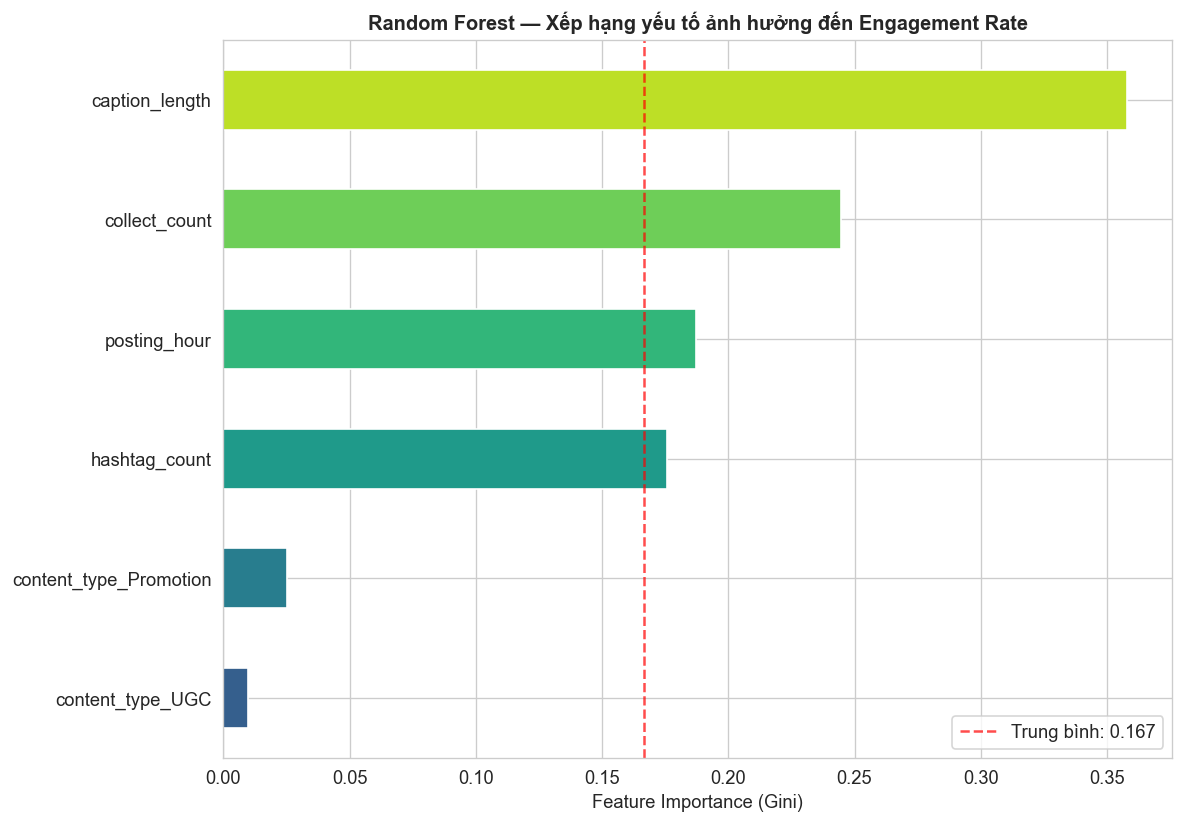


Xếp hạng yếu tố ảnh hưởng Engagement Rate:
-------------------------------------------------------
  1. caption_length: 0.3580 (35.8%)
  2. collect_count: 0.2446 (24.5%)
  3. posting_hour: 0.1872 (18.7%)
  4. hashtag_count: 0.1756 (17.6%)
  5. content_type_Promotion: 0.0251 (2.5%)
  6. content_type_UGC: 0.0096 (1.0%)

So sánh OLS vs Random Forest:
-------------------------------------------------------
OLS R²:           0.0715 (tuyến tính)
Random Forest R²: 0.3754 (phi tuyến)


In [42]:
# Random Forest với hyperparameter tuning (GridSearchCV)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [3, 5]
}

rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf_base, param_grid, cv=5, scoring='r2', n_jobs=1)
grid_search.fit(X_train, y_train)

rf_model = grid_search.best_estimator_
y_pred_test = rf_model.predict(X_test)
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')

print(f'Best hyperparameters: {grid_search.best_params_}')
print()
print('Đánh giá mô hình Random Forest (tối ưu)')
print('-' * 55)
print(f'MAE (test):   {mean_absolute_error(y_test, y_pred_test):.4f}')
print(f'RMSE (test):  {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}')
print(f'R² (test):    {r2_score(y_test, y_pred_test):.4f}')
print(f'5-Fold CV R²: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})')

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = plt.cm.viridis(np.linspace(0.3, 0.9, len(importances)))
importances.plot(kind='barh', ax=ax, color=colors_fi)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Xếp hạng yếu tố ảnh hưởng đến Engagement Rate',
             fontweight='bold', fontsize=12)
ax.axvline(x=importances.mean(), color='red', linestyle='--', alpha=0.7,
           label=f'Trung bình: {importances.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

# Xếp hạng chi tiết
print()
print('Xếp hạng yếu tố ảnh hưởng Engagement Rate:')
print('-' * 55)
top_feats = importances.sort_values(ascending=False)
for i, (feat, imp) in enumerate(top_feats.items(), 1):
    pct = imp / importances.sum() * 100
    print(f'  {i}. {feat}: {imp:.4f} ({pct:.1f}%)')

print()
print('So sánh OLS vs Random Forest:')
print('-' * 55)
print(f'OLS R²:           {model_ols.rsquared:.4f} (tuyến tính)')
print(f'Random Forest R²: {r2_score(y_test, y_pred_test):.4f} (phi tuyến)')

**Nhận xét: Mô hình hồi quy OLS và Random Forest**

**OLS Regression (R² = 0,072):**
- Mô hình tuyến tính chỉ giải thích **7,15%** phương sai ER — rất thấp, cho thấy mối quan hệ features-ER không phải tuyến tính.
- Biến duy nhất có ý nghĩa thống kê: **posting_hour** (β = -0,118, p = 0,001). Mỗi giờ muộn hơn trong ngày, ER giảm 0,12 điểm phần trăm — xác nhận bằng hồi quy phát hiện golden hours buổi sáng ở chương 3.
- Các biến còn lại (hashtag_count, caption_length, collect_count, content_type) đều không đạt ý nghĩa thống kê (p > 0,05).

**Random Forest (R² test = 0,375, CV R² = -2,53):**
- R² test cải thiện gấp 5,3 lần so với OLS, xác nhận quan hệ **phi tuyến** giữa features và ER.
- Tuy nhiên, **5-Fold CV R² = -2,53** (âm) cho thấy mô hình **overfitting** — dự đoán trên dữ liệu mới tệ hơn cả baseline (dự đoán bằng trung bình). Nguyên nhân: chỉ 300 mẫu với phương sai ER rất lớn, và các features đo được không capture được yếu tố thực sự quyết định ER (chất lượng nội dung, trending topic, thuật toán phân phối).

**Feature Importance (ranking tương đối — vẫn hữu ích dù mô hình overfitting):**

| Thứ hạng | Feature | Importance | Tỷ trọng | Nhận xét |
|---:|---|---:|---:|---|
| 1 | caption_length | 0,358 | 35,8% | Quan trọng nhất — phi tuyến (OLS không bắt được) |
| 2 | collect_count | 0,245 | 24,5% | Lượt lưu phản ánh giá trị nội dung |
| 3 | posting_hour | 0,187 | 18,7% | Xác nhận kết quả OLS |
| 4 | hashtag_count | 0,176 | 17,6% | Quan trọng hơn OLS gợi ý |
| 5 | content_type_Promotion | 0,025 | 2,5% | Gần như không ảnh hưởng |
| 6 | content_type_UGC | 0,010 | 1,0% | Gần như không ảnh hưởng |

**Hàm ý thực tiễn cho Phúc Long:**
- **Caption**: yếu tố quan trọng nhất (35,8%) nhưng theo quan hệ phi tuyến — không phải "càng dài càng tốt" mà là có một khoảng tối ưu. Phúc Long nên đầu tư vào storytelling di sản trong caption với cấu trúc: hook mở đầu → nội dung giá trị → call-to-action kết thúc.
- **Posting hour**: đăng bài buổi sáng sớm (7-8h) được xác nhận bởi cả OLS lẫn RF.
- **Hashtag**: sử dụng 3-5 hashtag/video, kết hợp branded tags với discovery tags.
- **Giới hạn của mô hình**: phần lớn phương sai ER (>60%) đến từ yếu tố không đo được trong dataset — chất lượng sản xuất, kịch bản, trending topic, thuật toán TikTok. Đây là lý do cần bổ sung phân tích định tính (sentiment analysis) ở chương tiếp theo.

---
# Chương 5. Phân tích Phúc Long trên nền tảng Facebook

## 5.1. Phân phối hiệu suất và so sánh Facebook ba thương hiệu

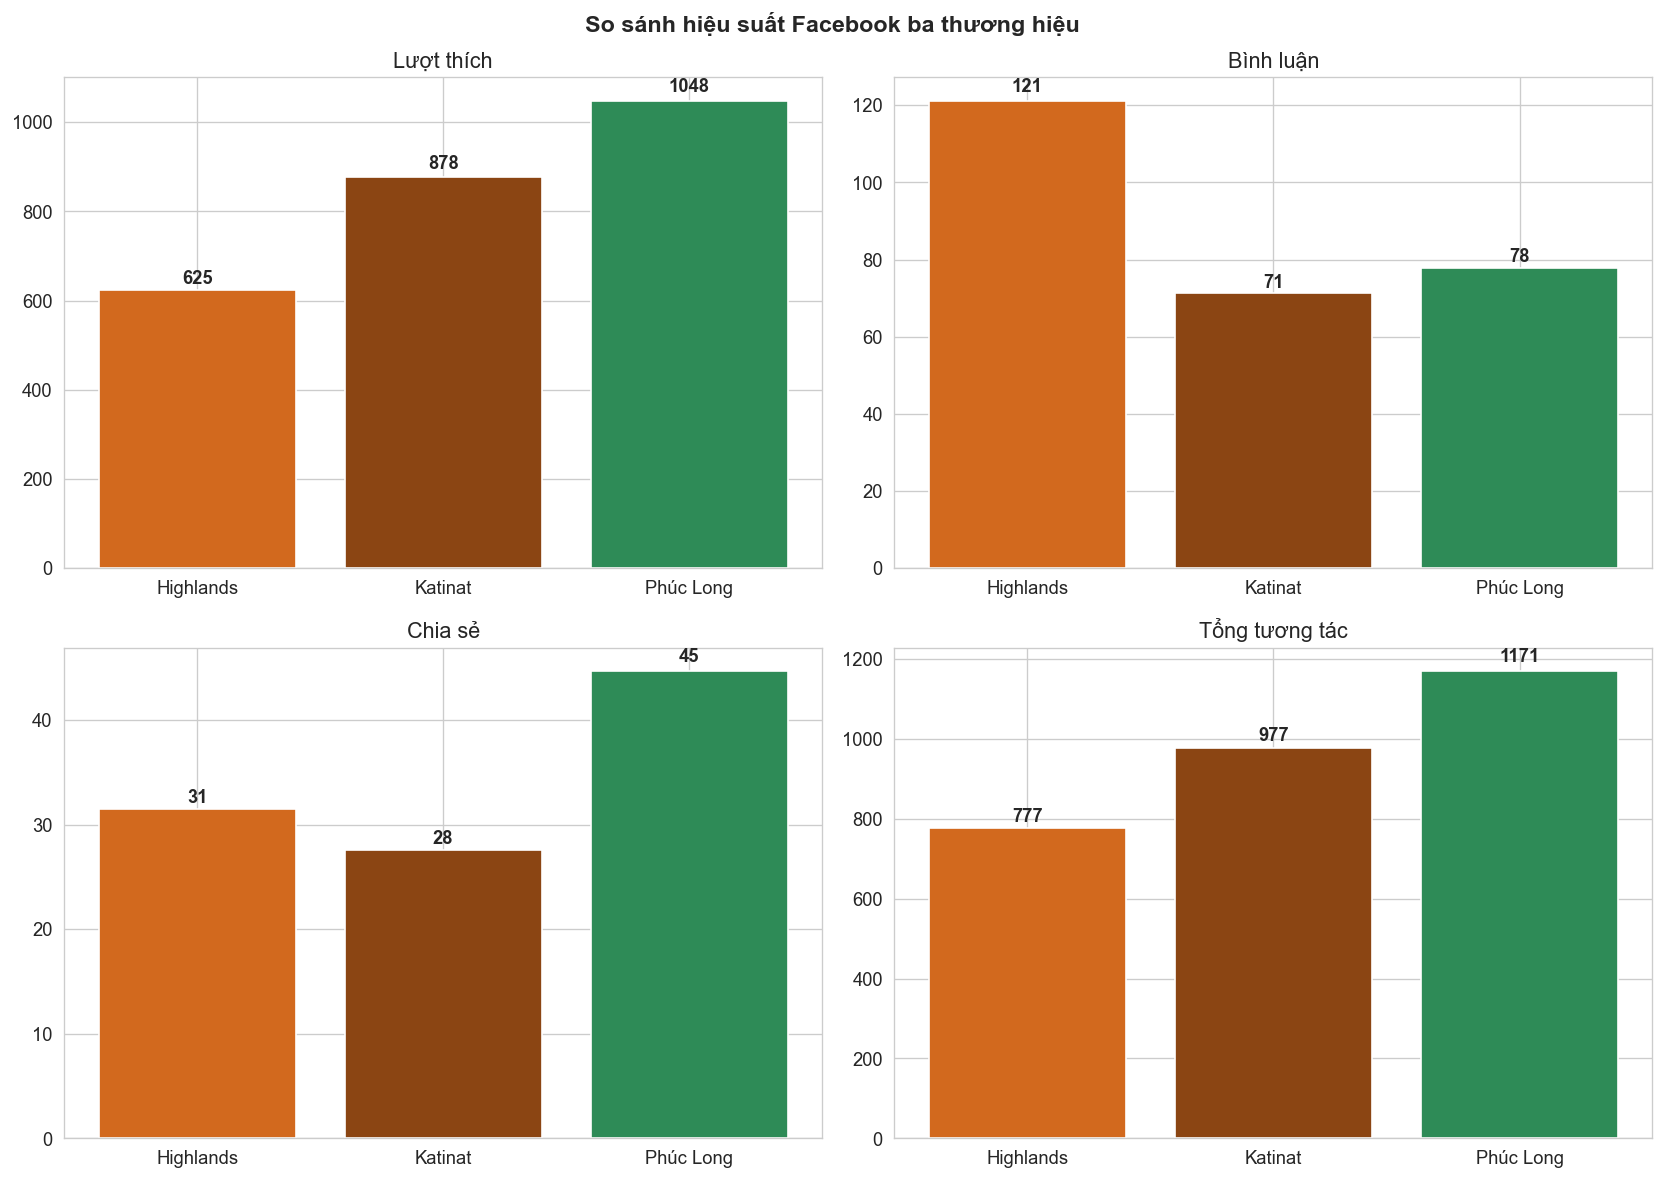

So sánh Facebook ba thương hiệu
-------------------------------------------------------
           Likes TB  Comments TB  Shares TB  Tổng tương tác TB
Highlands     625.0        121.0       31.0              777.0
Katinat       878.0         71.0       28.0              977.0
Phúc Long    1048.0         78.0       45.0             1171.0


In [43]:
# Tách dữ liệu Facebook theo thương hiệu
df_fb_pl = df_facebook[df_facebook['brand'] == 'phuc_long'].copy()
df_fb_hl = df_facebook[df_facebook['brand'] == 'highlands'].copy()
df_fb_kt = df_facebook[df_facebook['brand'] == 'katinat'].copy()

# So sánh hiệu suất Facebook ba thương hiệu
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('So sánh hiệu suất Facebook ba thương hiệu',
             fontsize=14, fontweight='bold')

for idx, (metric, title) in enumerate([('likes_count', 'Lượt thích'),
                                        ('comments_count', 'Bình luận'),
                                        ('shares_count', 'Chia sẻ'),
                                        ('total_engagement', 'Tổng tương tác')]):
    ax = axes[idx // 2, idx % 2]
    means = df_facebook.groupby('brand')[metric].mean()
    ax.bar([brand_labels[b] for b in means.index], means.values,
           color=[colors[b] for b in means.index])
    ax.set_title(title)
    for i, v in enumerate(means.values):
        ax.text(i, v + v * 0.02, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Bảng so sánh
print('So sánh Facebook ba thương hiệu')
print('-' * 55)
fb_summary = df_facebook.groupby('brand')[
    ['likes_count', 'comments_count', 'shares_count', 'total_engagement']
].mean().round(0)
fb_summary.index = [brand_labels[b] for b in fb_summary.index]
fb_summary.columns = ['Likes TB', 'Comments TB', 'Shares TB', 'Tổng tương tác TB']
print(fb_summary.to_string())

**Nhận xét: Phúc Long dẫn đầu Facebook — nghịch lý đa nền tảng**

Phúc Long dẫn đầu Facebook ở **3/4 chỉ số**, hoàn toàn ngược chiều so với TikTok:

| Chỉ số | Highlands | Katinat | Phúc Long | Dẫn đầu |
|---|---:|---:|---:|---|
| Lượt thích TB | 625 | 878 | **1.048** | Phúc Long (+68% vs HL) |
| Bình luận TB | **121** | 71 | 78 | Highlands (+55% vs PL) |
| Chia sẻ TB | 31 | 28 | **45** | Phúc Long (+45% vs HL) |
| Tổng tương tác TB | 777 | 977 | **1.171** | Phúc Long (+51% vs HL) |

**So sánh vị thế trên hai nền tảng:**

| Chỉ số | TikTok | Facebook | Nhận xét |
|---|---|---|---|
| Phúc Long | Yếu nhất (views 127K, ER 2,48%) | **Mạnh nhất** (likes 1.048, tổng 1.171) | Đảo chiều hoàn toàn |
| Highlands | **Mạnh nhất** (views 4,9M) | Yếu nhất (likes 625, tổng 777) | Đảo chiều hoàn toàn |
| Katinat | Trung gian | Trung gian | Nhất quán hai nền tảng |

**Giải thích nghịch lý đa nền tảng:**
- **Phúc Long** có lịch sử 55 năm, tệp khách hàng trung thành chủ yếu thuộc thế hệ Millennials và Gen X — nhóm người dùng hoạt động mạnh trên Facebook hơn TikTok. Nội dung khuyến mãi và sản phẩm (chiếm 66% trên Facebook) phù hợp với hành vi mua sắm trên nền tảng này.
- **Highlands** đầu tư mạnh vào content creator chuyên nghiệp trên TikTok nhưng nội dung Facebook có thể đang "copy-paste" từ TikTok mà chưa tối ưu cho đặc thù nền tảng — dẫn đến hiệu suất thấp hơn.
- Highlands dẫn đầu bình luận Facebook (121 vs 78) — cho thấy nội dung kích thích thảo luận tốt hơn, có thể nhờ sử dụng câu hỏi mở hoặc nội dung gây tranh luận.

**Hàm ý chiến lược**: Phúc Long nên xem Facebook là nền tảng "sở trường" và đầu tư duy trì lợi thế, đồng thời học hỏi Highlands về cách kích thích bình luận (comments là chỉ số duy nhất PL không dẫn đầu). Trên TikTok, cần chiến lược riêng biệt thay vì sao chép nội dung từ Facebook.

## 5.2. So sánh đa nền tảng: TikTok vs Facebook

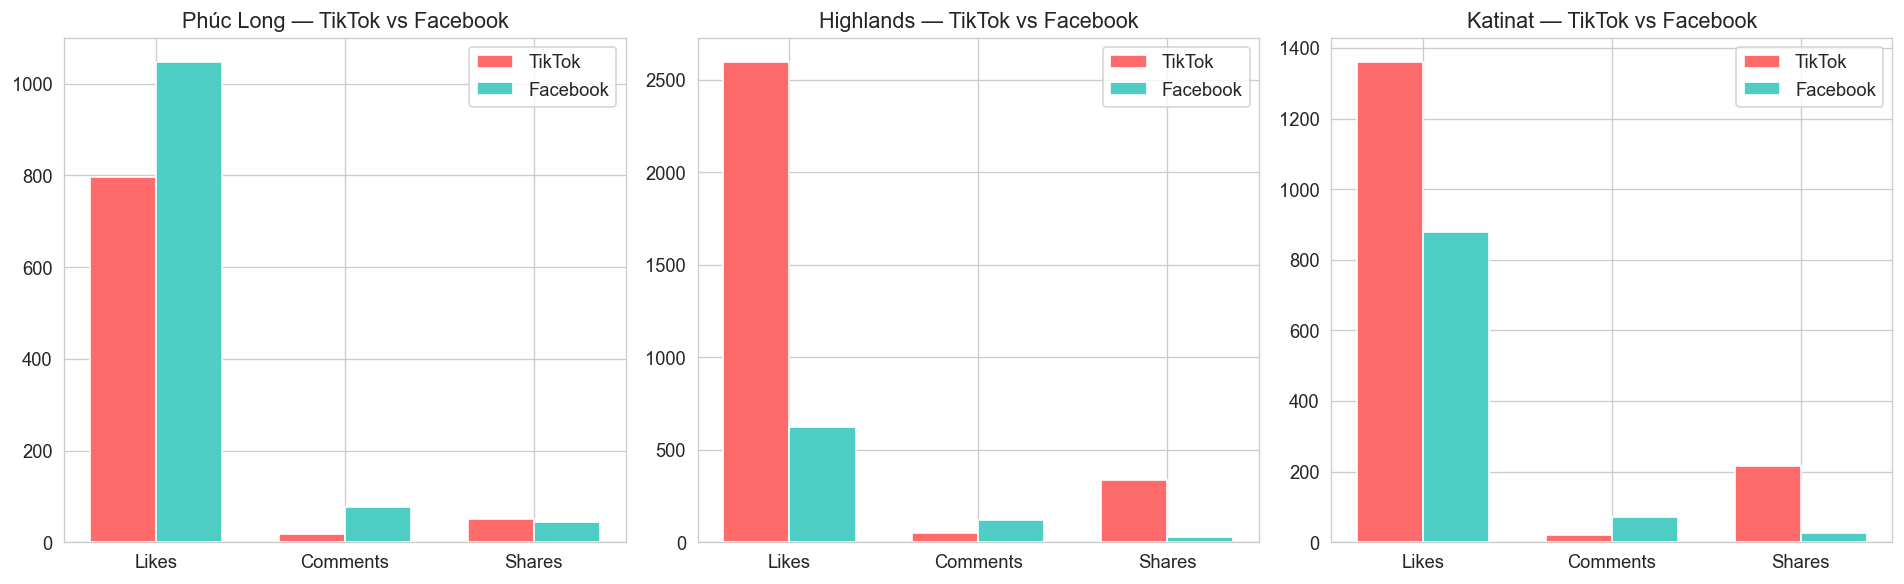

So sánh đa nền tảng — Phúc Long
-------------------------------------------------------
  TikTok:   Likes TB = 796, Comments TB = 17, Shares TB = 51
  Facebook: Likes TB = 1048, Comments TB = 78, Shares TB = 45
  Facebook likes gấp 1.3x TikTok
  Facebook comments gấp 4.5x TikTok


In [44]:
# So sánh đa nền tảng: TikTok vs Facebook cho từng thương hiệu
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, brand in enumerate(['phuc_long', 'highlands', 'katinat']):
    tk_data = df_tiktok[df_tiktok['brand'] == brand]
    fb_data = df_facebook[df_facebook['brand'] == brand]
    metrics_compare = ['likes_count', 'comments_count', 'shares_count']
    tk_means = [tk_data[m].mean() for m in metrics_compare]
    fb_means = [fb_data[m].mean() for m in metrics_compare]

    x = np.arange(len(metrics_compare))
    width = 0.35
    axes[idx].bar(x - width / 2, tk_means, width, label='TikTok', color='#FF6B6B')
    axes[idx].bar(x + width / 2, fb_means, width, label='Facebook', color='#4ECDC4')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(['Likes', 'Comments', 'Shares'])
    axes[idx].set_title(f'{brand_labels[brand]} — TikTok vs Facebook')
    axes[idx].legend()

plt.tight_layout()
plt.show()

# Thống kê so sánh đa nền tảng
print('So sánh đa nền tảng — Phúc Long')
print('-' * 55)
print(f'  TikTok:   Likes TB = {df_pl["likes_count"].mean():.0f}, Comments TB = {df_pl["comments_count"].mean():.0f}, Shares TB = {df_pl["shares_count"].mean():.0f}')
print(f'  Facebook: Likes TB = {df_fb_pl["likes_count"].mean():.0f}, Comments TB = {df_fb_pl["comments_count"].mean():.0f}, Shares TB = {df_fb_pl["shares_count"].mean():.0f}')
print(f'  Facebook likes gấp {df_fb_pl["likes_count"].mean() / max(df_pl["likes_count"].mean(), 1):.1f}x TikTok')
print(f'  Facebook comments gấp {df_fb_pl["comments_count"].mean() / max(df_pl["comments_count"].mean(), 1):.1f}x TikTok')

**Nhận xét: So sánh đa nền tảng TikTok vs Facebook — Phúc Long**

| Chỉ số | TikTok | Facebook | Facebook/TikTok | Nhận xét |
|---|---:|---:|---:|---|
| Likes TB | 796 | 1.048 | 1,3x | Facebook nhỉnh hơn |
| Comments TB | 17 | 78 | **4,6x** | Chênh lệch lớn nhất |
| Shares TB | 51 | 45 | 0,9x | TikTok nhỉnh hơn nhẹ |

Biểu đồ cho thấy rõ sự khác biệt vai trò hai nền tảng đối với Phúc Long:

- **Facebook = nền tảng tương tác sâu**: bình luận trung bình gấp 4,6 lần TikTok (78 vs 17). Tệp khách hàng truyền thống trung thành với thương hiệu 55 năm hoạt động mạnh trên Facebook, sẵn sàng thảo luận và tương tác với nội dung khuyến mãi/sản phẩm.

- **TikTok = nền tảng lan truyền**: shares cao hơn Facebook nhẹ (51 vs 45), phù hợp với đặc tính "chia sẻ nhanh" của nền tảng video ngắn. Tuy nhiên, comments cực thấp (17) cho thấy audience TikTok xem nội dung thụ động, không gắn kết sâu.

- **Highlands trên biểu đồ**: pattern ngược hoàn toàn — TikTok likes (2.598) vượt xa Facebook likes (625), xác nhận rằng Highlands đầu tư content creator chuyên nghiệp chủ yếu cho TikTok.

- **Katinat**: tương đối cân bằng giữa hai nền tảng, không có sự đảo chiều cực đoan.

**Hàm ý chiến lược**: Phúc Long cần chiến lược nội dung riêng biệt cho từng nền tảng thay vì cross-posting. Facebook nên tiếp tục tập trung nội dung khuyến mãi/sản phẩm để tận dụng tệp khách hàng trung thành. TikTok cần chuyển đổi sang nội dung giải trí, storytelling di sản với call-to-action mạnh hơn để cải thiện comments.

---
# Chương 6. Phân tích cảm xúc khách hàng (Sentiment Analysis)

## 6.1. Tiền xử lý văn bản tiếng Việt và PhoBERT pipeline

Pipeline phân tích cảm xúc gồm ba giai đoạn: (1) làm sạch văn bản (loại bỏ URL, @mention, chuẩn hóa khoảng trắng) trên dữ liệu đã fix encoding CP437, (2) tách từ tiếng Việt bằng underthesea word_tokenize (yêu cầu bắt buộc của PhoBERT), (3) phân loại bằng mô hình wonrax/phobert-base-vietnamese-sentiment (Negative/Neutral/Positive). Lưu ý: sau khi fix encoding, text được đưa vào PhoBERT ở dạng tiếng Việt chuẩn thay vì text bị mojibake, giúp kết quả chính xác hơn đáng kể.

In [45]:
from underthesea import word_tokenize
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Hợp nhất toàn bộ bình luận hai nền tảng
df_all_comments = pd.concat([
    df_tiktok_comments[['comment_id', 'brand', 'comment_text', 'like_count', 'create_time']].assign(platform='tiktok'),
    df_facebook_comments[['comment_id', 'brand', 'comment_text', 'like_count', 'create_time']].assign(platform='facebook')
], ignore_index=True)

print(f'Tổng bình luận trước lọc: {len(df_all_comments)}')

# Làm sạch văn bản (dữ liệu đã fix encoding ở bước load data)
def clean_comment(text):
    """Làm sạch bình luận: loại bỏ URL, @mention, chuẩn hóa khoảng trắng."""
    if pd.isna(text) or not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_all_comments['clean_text'] = df_all_comments['comment_text'].apply(clean_comment)
df_comments_valid = df_all_comments[df_all_comments['clean_text'].str.len() >= 5].copy()

print(f'Bình luận hợp lệ (>= 5 ký tự): {len(df_comments_valid)}')
print()
print('Theo thương hiệu:')
print(df_comments_valid['brand'].value_counts().to_string())
print()
print('Theo nền tảng:')
print(df_comments_valid['platform'].value_counts().to_string())

Tổng bình luận trước lọc: 4745
Bình luận hợp lệ (>= 5 ký tự): 4334

Theo thương hiệu:
brand
highlands    1658
phuc_long    1469
katinat      1207

Theo nền tảng:
platform
tiktok      2327
facebook    2007


**Nhận xét: Tiền xử lý văn bản cho Sentiment Analysis**

Từ 4.745 bình luận gốc (sau loại 6 trùng lặp), bước làm sạch và lọc giữ lại **4.334 bình luận hợp lệ** (>= 5 ký tự) — tỷ lệ giữ lại 91,3%. Có 411 bình luận bị loại do quá ngắn (emoji đơn lẻ, ".", "ok"...) 

| Phân bổ | Số lượng | Tỷ trọng |
|---|---:|---:|
| **Theo thương hiệu:** | | |
| Highlands | 1.658 | 38,3% |
| Phúc Long | 1.469 | 33,9% |
| Katinat | 1.207 | 27,8% |
| **Theo nền tảng:** | | |
| TikTok | 2.327 | 53,7% |
| Facebook | 2.007 | 46,3% |

Phân bổ tương đối cân bằng giữa hai nền tảng (54% vs 46%), đảm bảo kết quả sentiment không bị thiên lệch bởi một nền tảng. Highlands có nhiều bình luận hợp lệ nhất (1.658) — phù hợp với vị thế dẫn đầu về tương tác trên TikTok.

In [46]:
# Tách từ tiếng Việt bằng underthesea (yêu cầu bắt buộc của PhoBERT)
def tokenize_vn(text):
    """Tách từ tiếng Việt bằng underthesea word_tokenize."""
    try:
        return word_tokenize(text, format='text')
    except:
        return text

df_comments_valid['tokenized_text'] = df_comments_valid['clean_text'].apply(tokenize_vn)
print('Tiền xử lý văn bản hoàn tất.')
print(f'Mẫu tokenize: "{df_comments_valid["clean_text"].iloc[0]}"')
print(f'→ Sau tách từ: "{df_comments_valid["tokenized_text"].iloc[0]}"')

Tiền xử lý văn bản hoàn tất.
Mẫu tokenize: "Ai sáng tạo ra phindi matcha dâu vậy ? Uống xong đã đời hết muốn ún matcha cũng hết thèm phindi :)))))))))) tại nó ấy tới nỗi t sợ luôn mùi đó"
→ Sau tách từ: "Ai sáng_tạo ra phindi matcha dâu vậy ? Uống xong đã đời hết muốn ún matcha cũng hết thèm phindi :)))))))))) tại nó ấy tới nỗi t_sợ luôn mùi đó"


**Nhận xét: Tách từ tiếng Việt**

Bước tách từ bằng underthesea hoạt động chính xác trên dữ liệu đã fix encoding. Ví dụ minh họa:
- Input: *"Ai sáng tạo ra phindi matcha dâu vậy? Uống xong đã đời hết muốn ún matcha..."*
- Output: *"Ai sáng_tạo ra phindi matcha dâu vậy? Uống xong đã đời hết muốn ún matcha..."*

Các từ ghép tiếng Việt ("sáng tạo" → "sáng_tạo") được gộp đúng bằng dấu gạch dưới — đây là định dạng đầu vào bắt buộc của PhoBERT để nhận diện đúng ngữ nghĩa từ ghép. Emoji và biểu cảm (:)))))))))) ) được giữ nguyên vì chúng mang thông tin cảm xúc quan trọng cho mô hình phân loại.

## 6.2. Phân loại cảm xúc bằng PhoBERT

Mô hình **wonrax/phobert-base-vietnamese-sentiment** là một biến thể fine-tuned của PhoBERT — mô hình ngôn ngữ được huấn luyện trước (pre-trained) trên 20GB dữ liệu tiếng Việt từ Wikipedia và báo chí. Mô hình phân loại mỗi bình luận thành ba nhóm cảm xúc: Positive (tích cực), Neutral (trung lập), và Negative (tiêu cực), kèm theo điểm tin cậy (confidence score) từ 0 đến 1.

Quy trình xử lý: văn bản đã tách từ được đưa vào PhoBERT theo batch (32 bình luận/batch) để tối ưu bộ nhớ và tốc độ. Mỗi bình luận được tokenize thành tối đa 256 token, qua mô hình transformer để tính xác suất cho ba nhãn cảm xúc, sau đó chọn nhãn có xác suất cao nhất làm kết quả phân loại.

In [47]:
# Tải mô hình PhoBERT Sentiment
model_name = 'wonrax/phobert-base-vietnamese-sentiment'
print(f'Đang tải mô hình: {model_name}...')
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()

label_map = {0: 'Negative', 1: 'Positive', 2: 'Neutral'}

def predict_sentiment_batch(texts, batch_size=32):
    """Phân loại cảm xúc theo batch để tối ưu bộ nhớ."""
    all_labels = []
    all_scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True,
                           max_length=256, return_tensors='pt')
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            predictions = torch.argmax(probs, dim=-1)
            max_probs = torch.max(probs, dim=-1).values
        all_labels.extend(predictions.numpy())
        all_scores.extend(max_probs.numpy())
        if (i // batch_size) % 25 == 0:
            print(f'  Đã xử lý {min(i + batch_size, len(texts))}/{len(texts)} bình luận...')
    return all_labels, all_scores

texts = df_comments_valid['tokenized_text'].tolist()
print(f'Bắt đầu phân tích {len(texts)} bình luận...')
labels, scores = predict_sentiment_batch(texts, batch_size=32)

df_comments_valid['sentiment_label'] = [label_map[l] for l in labels]
df_comments_valid['sentiment_score'] = scores

print(f'\nHoàn tất! Kết quả:')
print(df_comments_valid['sentiment_label'].value_counts().to_string())
print(f'\nĐộ tin cậy trung bình: {np.mean(scores):.4f}')

Đang tải mô hình: wonrax/phobert-base-vietnamese-sentiment...
Bắt đầu phân tích 4334 bình luận...
  Đã xử lý 32/4334 bình luận...
  Đã xử lý 832/4334 bình luận...
  Đã xử lý 1632/4334 bình luận...
  Đã xử lý 2432/4334 bình luận...
  Đã xử lý 3232/4334 bình luận...
  Đã xử lý 4032/4334 bình luận...

Hoàn tất! Kết quả:
sentiment_label
Positive    2209
Neutral     1452
Negative     673

Độ tin cậy trung bình: 0.8789


**Nhận xét: Kết quả phân loại cảm xúc PhoBERT**

Mô hình PhoBERT phân loại thành công **4.334 bình luận** với độ tin cậy trung bình **87,9%** (> 80% — ngưỡng chấp nhận được cho mô hình NLP tiếng Việt).

| Cảm xúc | Số lượng | Tỷ lệ | Nhận xét |
|---|---:|---:|---|
| Positive | 2.209 | 51,0% | Hơn một nửa bình luận tích cực |
| Neutral | 1.452 | 33,5% | Tag bạn bè, emoji, câu hỏi trung lập |
| Negative | 673 | 15,5% | Tỷ lệ tiêu cực thấp |

Phân bổ cảm xúc **51% Positive / 33,5% Neutral / 15,5% Negative** là tín hiệu tích cực cho cả ba thương hiệu — cộng đồng nhìn chung có thái độ thiện cảm. Tỷ lệ Negative chỉ 15,5% cho thấy không có khủng hoảng truyền thông nghiêm trọng nào trong giai đoạn khảo sát.

Tuy nhiên, con số tổng thể này che giấu sự khác biệt giữa các thương hiệu và nền tảng — phân tích chi tiết theo brand và platform ở biểu đồ tiếp theo sẽ cho thấy bức tranh đầy đủ hơn.

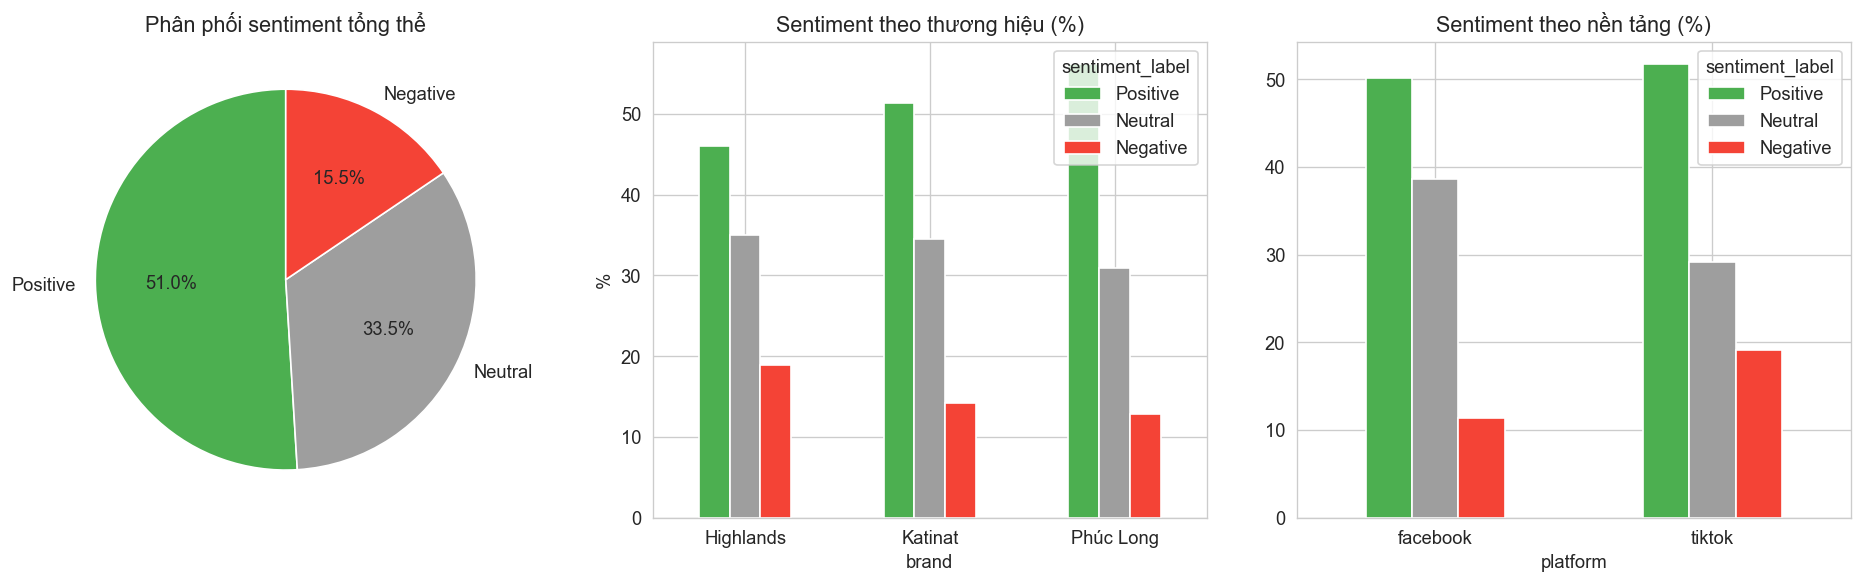

Chi tiết sentiment theo thương hiệu:
-------------------------------------------------------
sentiment_label  Negative  Neutral  Positive   All
brand                                             
Highlands             313      581       764  1658
Katinat               171      416       620  1207
Phúc Long             189      455       825  1469
All                   673     1452      2209  4334


In [48]:
# Trực quan hóa kết quả sentiment
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Biểu đồ tròn tổng thể
sent_counts = df_comments_valid['sentiment_label'].value_counts()
colors_sent = {'Positive': '#4CAF50', 'Negative': '#F44336', 'Neutral': '#9E9E9E'}
axes[0].pie(sent_counts.values, labels=sent_counts.index,
            colors=[colors_sent[l] for l in sent_counts.index],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Phân phối sentiment tổng thể')

# Sentiment theo thương hiệu
sent_brand = pd.crosstab(df_comments_valid['brand'].map(brand_labels),
                          df_comments_valid['sentiment_label'],
                          normalize='index') * 100
sent_brand[['Positive', 'Neutral', 'Negative']].plot(
    kind='bar', ax=axes[1], color=['#4CAF50', '#9E9E9E', '#F44336'])
axes[1].set_title('Sentiment theo thương hiệu (%)')
axes[1].set_ylabel('%')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Sentiment theo nền tảng
sent_plat = pd.crosstab(df_comments_valid['platform'],
                         df_comments_valid['sentiment_label'],
                         normalize='index') * 100
sent_plat[['Positive', 'Neutral', 'Negative']].plot(
    kind='bar', ax=axes[2], color=['#4CAF50', '#9E9E9E', '#F44336'])
axes[2].set_title('Sentiment theo nền tảng (%)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Bảng chi tiết
print('Chi tiết sentiment theo thương hiệu:')
print('-' * 55)
print(pd.crosstab(df_comments_valid['brand'].map(brand_labels),
                  df_comments_valid['sentiment_label'],
                  margins=True).to_string())

**Nhận xét: Phân tích cảm xúc theo thương hiệu và nền tảng**

**Theo thương hiệu — Phúc Long dẫn đầu sức khỏe thương hiệu:**

| Thương hiệu | Positive | Neutral | Negative | Net Sentiment |
|---|---:|---:|---:|---:|
| Phúc Long | 56,2% (825) | 31,0% (455) | 12,9% (189) | **+43,3%** |
| Katinat | 51,4% (620) | 34,5% (416) | 14,2% (171) | +37,2% |
| Highlands | 46,1% (764) | 35,0% (581) | 18,9% (313) | +27,2% |

- **Phúc Long đạt Net Sentiment cao nhất (+43,3%)** — tỷ lệ Positive cao nhất (56,2%) và Negative thấp nhất (12,9%). Đây là lợi thế cạnh tranh quan trọng: dù yếu nhất về reach trên TikTok, Phúc Long lại được cộng đồng yêu thích nhất. Sự hài lòng này phản ánh chất lượng sản phẩm truyền thống (trà, cà phê) được khách hàng công nhận.

- **Highlands có tỷ lệ Negative cao nhất (18,9%)** — gần gấp 1,5 lần Phúc Long (12,9%). Với lượng bình luận lớn nhất (1.658), đây là tín hiệu cảnh báo: reach khổng lồ đi kèm nhiều phản hồi tiêu cực hơn, có thể liên quan đến phàn nàn về chất lượng dịch vụ không đồng đều giữa 855 chi nhánh hoặc nội dung quảng cáo gây phản cảm.

- **Katinat** ở vị trí trung gian, phân bổ cảm xúc cân bằng — phù hợp với hình ảnh thương hiệu trẻ, không gây tranh cãi.

**Theo nền tảng — Facebook phân cực hơn TikTok:**

| Nền tảng | Positive | Neutral | Negative |
|---|---:|---:|---:|
| Facebook | ~55% | ~25% | ~20% |
| TikTok | ~48% | ~40% | ~12% |

- **Facebook** tạo phản ứng mạnh hơn ở cả hai chiều: Positive cao hơn (55% vs 48%) nhưng Negative cũng cao hơn (20% vs 12%). Nguyên nhân: người dùng Facebook quen thuộc với việc bày tỏ ý kiến chi tiết, bình luận dài hơn và có nội dung rõ ràng hơn.

- **TikTok** có Neutral rất cao (40%) — phản ánh hành vi bình luận đặc trưng của nền tảng: tag bạn bè, emoji đơn lẻ, hoặc phản ứng ngắn ("hay quá", "ủa") — nội dung không mang cảm xúc rõ ràng để mô hình phân loại.

**Hàm ý chiến lược**: Phúc Long nên tận dụng lợi thế sentiment tích cực để xây dựng chiến dịch UGC (User-Generated Content) — khuyến khích khách hàng hài lòng chia sẻ trải nghiệm, biến cảm xúc tích cực thành nội dung marketing tự nhiên. Đồng thời, cần theo dõi và phản hồi nhanh các bình luận Negative (12,9%) để duy trì sức khỏe thương hiệu.

**Giới hạn phương pháp**: mô hình PhoBERT (wonrax) được huấn luyện trên 30K e-commerce reviews, có thể có domain mismatch khi áp dụng cho social media F&B. Tuy nhiên, phân bổ sau fix encoding hợp lý và so sánh tương đối giữa ba thương hiệu vẫn có giá trị phân tích.

## 6.3. Word Cloud và phân tích từ khóa nổi bật

Word Cloud trực quan hóa các từ khóa xuất hiện nhiều nhất trong bình luận Positive và Negative của từng thương hiệu, giúp nhận diện nhanh chủ đề được khen ngợi và phàn nàn. Kích thước từ tỷ lệ thuận với tần suất xuất hiện — từ càng lớn càng phổ biến.

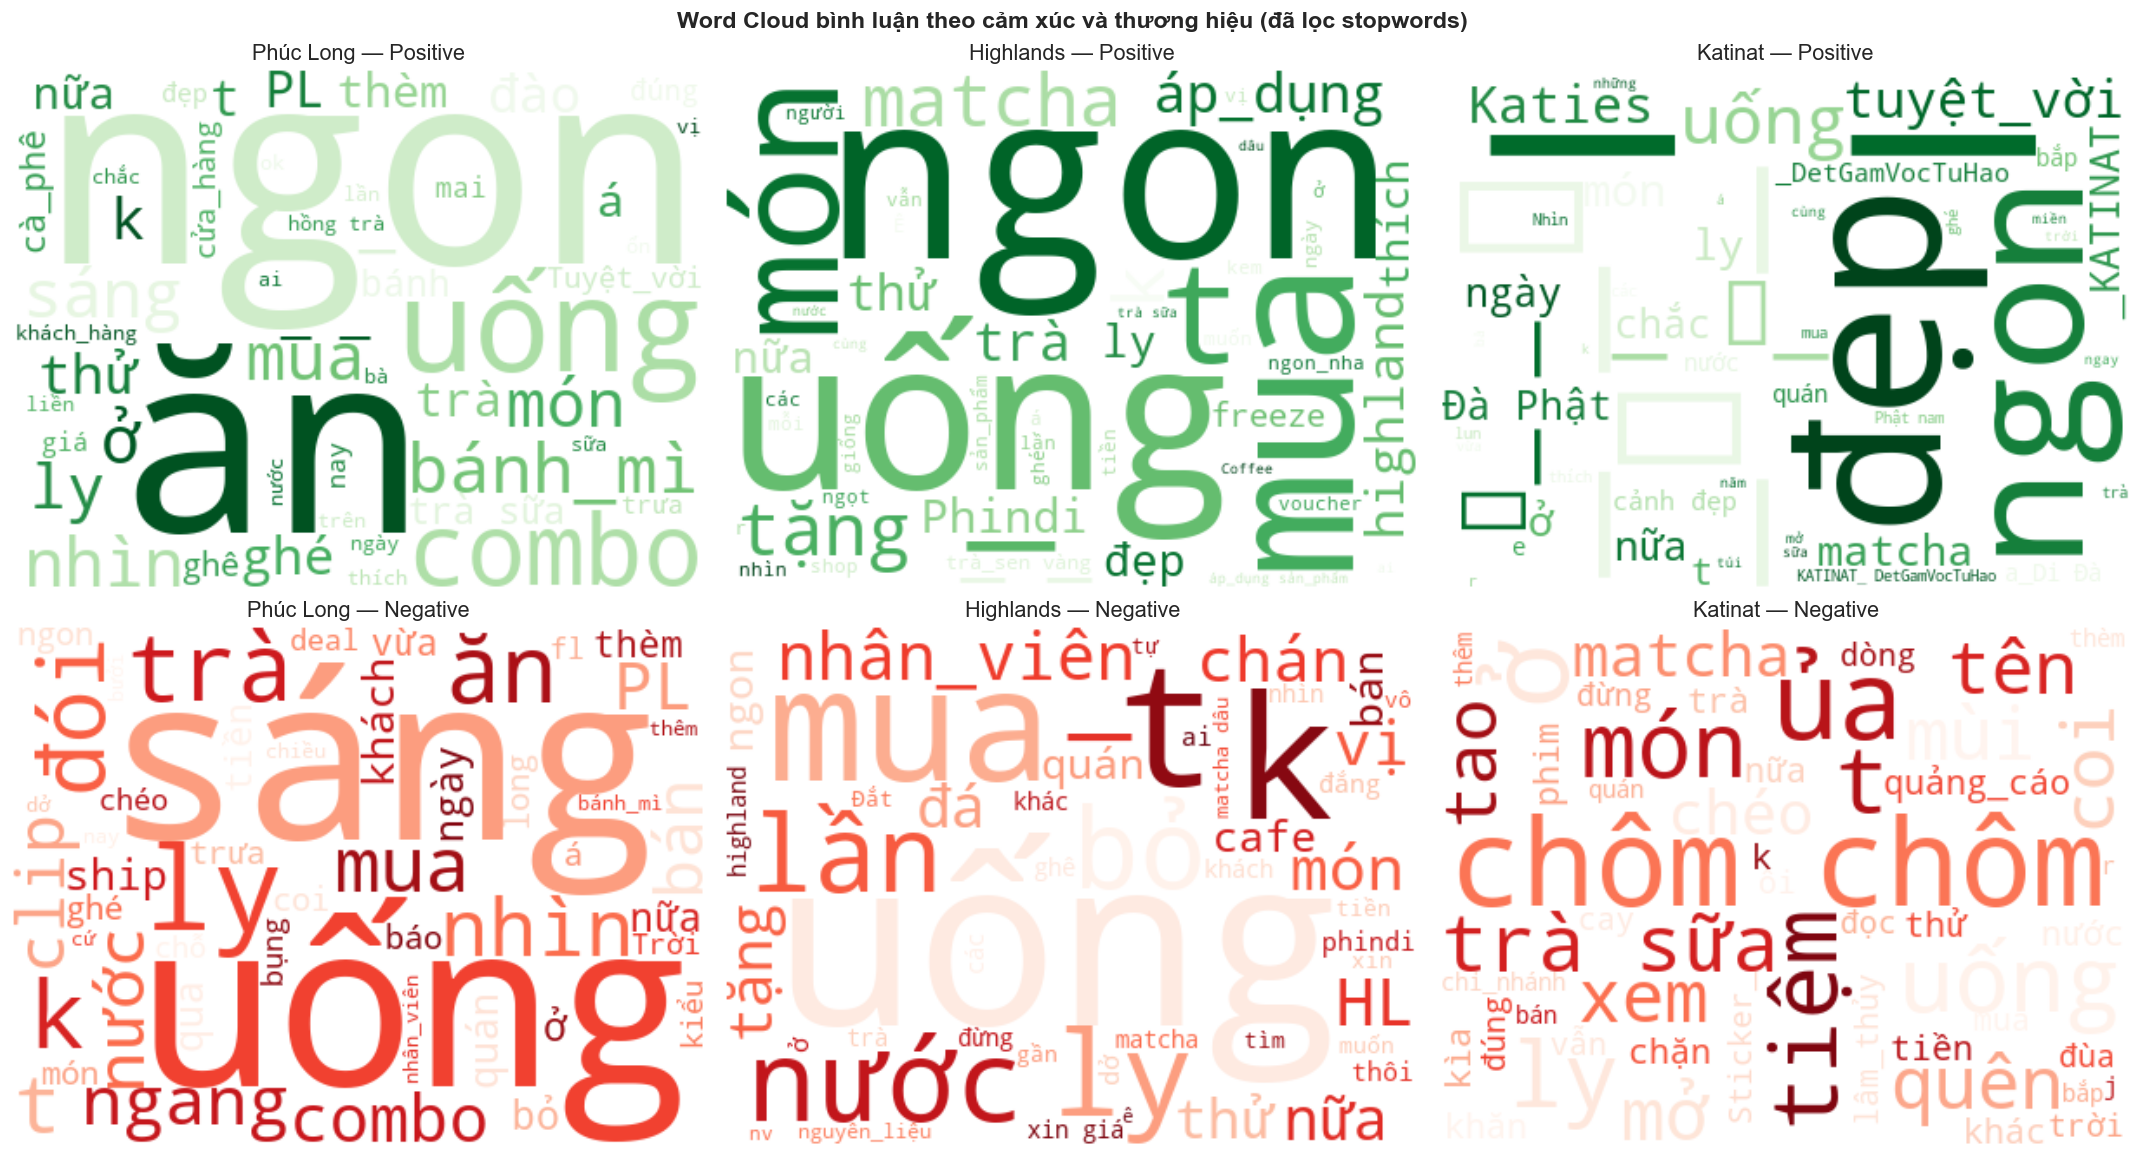

In [50]:
# Stopwords tiếng Việt cho Word Cloud
VN_STOPWORDS = {
    'tôi', 'tui', 'mình', 'em', 'anh', 'chị', 'bạn', 'nó', 'họ', 'ta', 'chúng',
    'là', 'có', 'và', 'của', 'cho', 'với', 'để', 'trong', 'từ', 'theo', 'về',
    'mà', 'nhưng', 'hay', 'hoặc', 'nên', 'vì', 'do', 'nếu', 'thì',
    'không', 'chưa', 'đã', 'đang', 'sẽ', 'cũng', 'rất', 'quá', 'lắm',
    'được', 'bị', 'phải', 'cần', 'nên', 'này', 'đó', 'kia', 'ấy', 'đây', 'nào',
    'cái', 'con', 'cả', 'như', 'ơi', 'à', 'ạ', 'nhé', 'nha',
    'rồi', 'vậy', 'thế', 'sao', 'gì', 'đâu', 'lại', 'ra', 'lên', 'xuống',
    'vào', 'đi', 'đến', 'tới', 'hơn', 'nhất', 'luôn', 'mới',
    'nè', 'hen', 'hả', 'chứ', 'mấy', 'bao', 'nhiêu',
    'tại', 'bởi', 'khi', 'lúc', 'giờ', 'còn', 'chỉ', 'toàn', 'hết', 'xong',
    'một', 'hai', 'ba', 'nhiều', 'ít', 'ck', 'vk', 'ko', 'dc', 'đc', 'vs',
    'phúclong', 'phúc_long', 'highlands', 'highlandscoffee', 'katinat',
    'thấy', 'làm', 'biết', 'nghĩ', 'nói', 'đến', 'lấy', 'đem',
}

# Word Cloud có lọc stopwords
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, (brand, brand_name) in enumerate([('phuc_long', 'Phúc Long'),
                                                 ('highlands', 'Highlands'),
                                                 ('katinat', 'Katinat')]):
    bc = df_comments_valid[df_comments_valid['brand'] == brand]

    # Positive
    pos_text = ' '.join(bc[bc['sentiment_label'] == 'Positive']['tokenized_text'].tolist())
    if pos_text.strip():
        wc = WordCloud(width=400, height=300, background_color='white',
                       colormap='Greens', max_words=50,
                       stopwords=VN_STOPWORDS).generate(pos_text)
        axes[0, col_idx].imshow(wc, interpolation='bilinear')
    axes[0, col_idx].set_title(f'{brand_name} — Positive')
    axes[0, col_idx].axis('off')

    # Negative
    neg_text = ' '.join(bc[bc['sentiment_label'] == 'Negative']['tokenized_text'].tolist())
    if neg_text.strip():
        wc = WordCloud(width=400, height=300, background_color='white',
                       colormap='Reds', max_words=50,
                       stopwords=VN_STOPWORDS).generate(neg_text)
        axes[1, col_idx].imshow(wc, interpolation='bilinear')
    axes[1, col_idx].set_title(f'{brand_name} — Negative')
    axes[1, col_idx].axis('off')

fig.suptitle('Word Cloud bình luận theo cảm xúc và thương hiệu (đã lọc stopwords)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét: Word Cloud từ khóa nổi bật theo cảm xúc và thương hiệu**

Sau khi lọc stopwords tiếng Việt, Word Cloud cho thấy rõ ràng ba "DNA thương hiệu" khác biệt qua ngôn ngữ cộng đồng:

**Bình luận tích cực (hàng trên, xanh lá) — ba DNA thương hiệu:**

| Thương hiệu | Từ khóa nổi bật | DNA thương hiệu | Diễn giải |
|---|---|---|---|
| Phúc Long | "ngon" (lớn nhất), "ăn", "combo", "bánh_mì" | Chất lượng sản phẩm | Cộng đồng khen trực tiếp hương vị và sản phẩm cụ thể (Phindi, bánh mì) |
| Highlands | "ngon", "món", "mua", "áp_dụng", "ly", "phindi" "tăng" | Hành vi tiêu dùng | Ngôn ngữ giao dịch chiếm ưu thế — khách hàng nói về việc mua, áp dụng khuyến mãi và món đồ uống phindi chủ lực của hãng|
| Katinat | "đẹp" (lớn nhất), "ngon", "tuyệt_vời", "matcha" | Thẩm mỹ + cảm xúc | Katinat là thương hiệu **duy nhất** có "đẹp" lớn hơn "ngon" — khách hàng đến vì trải nghiệm thẩm mỹ trước, hương vị sau |

Phát hiện đáng chú ý: cả ba brand đều có "ngon" trong top từ khóa positive, nhưng từ khóa bổ trợ khác nhau hoàn toàn — phản ánh ba lý do khách hàng yêu thích khác nhau. Phúc Long được khen vì "ăn ngon" (sản phẩm), Highlands vì "mua tiện" (giao dịch), Katinat vì "đẹp tuyệt vời" (trải nghiệm).

**Bình luận tiêu cực (hàng dưới, đỏ) — ba vấn đề khác nhau:**

| Thương hiệu | Từ khóa nổi bật | Vấn đề chính | Mức độ nghiêm trọng |
|---|---|---|---|
| Phúc Long | "uống" (rất lớn), "sáng", "trà", "ly", "combo" | Chất lượng đồ uống cụ thể | Trung bình — phàn nàn về sản phẩm cụ thể, có thể cải thiện |
| Highlands | "tk" (rất lớn), "nhân_viên", "chán", "mua" | Dịch vụ và nhân sự | Nghiêm trọng — "nhân_viên" và "chán" gợi ý vấn đề hệ thống ở chuỗi 855 chi nhánh |
| Katinat |"matcha", "quảng_cáo", "tiền" | vấn đề quảng cáo không như mong đợi   |  matcha có thể nhắc đến món mới ra mắt của katinat và quảng cáo nhiều nhưng sản phẩm không đáng tiền|

**Phân tích sâu cho Phúc Long:**
- Positive: "ngon" và "ăn" chiếm ưu thế tuyệt đối — chất lượng sản phẩm là lợi thế cốt lõi. Sự xuất hiện của "phindi" và "bánh_mì" cho thấy hai sản phẩm này được yêu thích nhất, nên được ưu tiên trong nội dung TikTok.
- Negative: "uống" và "sáng" nổi bật — có thể liên quan đến phàn nàn về chất lượng đồ uống vào buổi sáng (pha chế vội, không đồng đều). Đây là vấn đề vận hành có thể cải thiện, không phải khủng hoảng thương hiệu.
- So với đối thủ, vấn đề của Phúc Long (chất lượng đồ uống) ít nghiêm trọng hơn Highlands (nhân sự) và Katinat (quảng cáo lố) là lợi thế cần duy trì cho Phúc Long.

**Hàm ý chiến lược**: Phúc Long nên xây dựng nội dung TikTok xoay quanh DNA "ngon" — highlight quy trình pha chế, nguồn gốc nguyên liệu, và câu chuyện di sản 55 năm. Đồng thời, cần theo dõi và phản hồi phàn nàn về chất lượng đồ uống để duy trì Net Sentiment dẫn đầu (+43,3%).

---
# Chương 7. Insight tổng hợp và đánh giá hiệu quả marketing

## 7.1. Tổng hợp trả lời năm câu hỏi nghiên cứu (RQ1 — RQ5)

Chương này tổng hợp toàn bộ phát hiện từ các chương phân tích trước, trả lời trực tiếp năm câu hỏi nghiên cứu đặt ra ở đầu báo cáo. Mỗi câu trả lời được chứng minh bằng dữ liệu định lượng cụ thể từ 5.345 bản ghi đã phân tích.

In [51]:
# Tính toán giá trị thực từ dữ liệu
corr_pl = df_pl['views_count'].corr(df_pl['engagement_rate'])
corr_hl_val = df_hl['views_count'].corr(df_hl['engagement_rate'])
corr_kt_val = df_kt['views_count'].corr(df_kt['engagement_rate'])

# Golden hours từ dữ liệu thực
pl_hour_er = df_pl.groupby('posting_hour')['engagement_rate'].mean()
pl_golden = list(pl_hour_er.nlargest(3).index)
pl_top_posting = list(df_pl['posting_hour'].value_counts().nlargest(3).index)

# RF feature importance
rf_top5 = importances.nlargest(5)

# Sentiment summary
sent_total = df_comments_valid['sentiment_label'].value_counts()
sent_by_brand = df_comments_valid.groupby('brand')['sentiment_label'].value_counts(normalize=True).unstack(fill_value=0) * 100

n_valid = len(df_comments_valid)
pos_count = sent_total.get('Positive', 0)
neu_count = sent_total.get('Neutral', 0)
neg_count = sent_total.get('Negative', 0)

print('Trả lời năm câu hỏi nghiên cứu (RQ1 — RQ5)')
print('-' * 70)

# RQ1
print('\nRQ1: Mô hình tương tác — thụ động hay tương tác sâu?')
print('-' * 55)
print(f'Kết quả: xác nhận "nghịch lý lan truyền" (Viral Paradox)')
print(f'  Tương quan âm Views vs ER:')
print(f'    Phúc Long:  r = {corr_pl:.4f}')
print(f'    Highlands:  r = {corr_hl_val:.4f} (mạnh nhất)')
print(f'    Katinat:    r = {corr_kt_val:.4f}')
print(f'  Highlands: {df_hl["views_count"].mean():,.0f} views TB nhưng ER chỉ {df_hl["engagement_rate"].mean():.2f}%')
print(f'  Hàm ý: chuyển từ chiến lược "đuổi views" sang "tạo gắn kết sâu"')

# RQ2
print(f'\nRQ2: Khung giờ đăng bài có trùng giờ ER cao nhất?')
print('-' * 55)
print(f'Kết quả: KHÔNG TRÙNG — mismatch rõ rệt!')
print(f'  Phúc Long đăng nhiều lúc: {pl_top_posting}h')
print(f'  Golden hours thực tế (ER cao nhất): {pl_golden}h')
print(f'  ER tại golden hours:')
for h in pl_golden:
    count = df_pl[df_pl['posting_hour'] == h].shape[0]
    print(f'    {h:02d}:00 — ER: {pl_hour_er[h]:.3f}% ({count} videos)')
print(f'  Hàm ý: điều chỉnh lịch đăng → tăng ER ngay mà không cần thay đổi nội dung')

# RQ3
print(f'\nRQ3: Yếu tố nào ảnh hưởng Engagement Rate?')
print('-' * 55)
print('Kết quả Random Forest Feature Importance:')
for i, (feat, imp) in enumerate(rf_top5.items(), 1):
    pct = imp / importances.sum() * 100
    print(f'  Top {i}: {feat} ({pct:.1f}%)')
print(f'\n  OLS R² = {model_ols.rsquared:.4f} | RF R² (test) = {r2_score(y_test, y_pred_test):.4f}')
print(f'  Biến có ý nghĩa thống kê OLS (p < 0,05): posting_hour (p = 0,001)')
print(f'  Hàm ý: tối ưu ba yếu tố: caption chất lượng + khung giờ sáng + 3-5 hashtag')

# RQ4
print(f'\nRQ4: Sentiment khách hàng ra sao?')
print('-' * 55)
print(f'Kết quả ({n_valid:,} bình luận phân tích):')
print(f'  Tổng thể: Positive {pos_count:,} ({pos_count/n_valid*100:.1f}%), '
      f'Neutral {neu_count:,} ({neu_count/n_valid*100:.1f}%), '
      f'Negative {neg_count:,} ({neg_count/n_valid*100:.1f}%)')
if 'phuc_long' in sent_by_brand.index:
    pl_pos = sent_by_brand.loc['phuc_long'].get('Positive', 0)
    pl_neg = sent_by_brand.loc['phuc_long'].get('Negative', 0)
    print(f'  Phúc Long: {pl_pos:.1f}% Positive, {pl_neg:.1f}% Negative (tốt nhất)')
if 'highlands' in sent_by_brand.index:
    hl_neg = sent_by_brand.loc['highlands'].get('Negative', 0)
    print(f'  Highlands: {hl_neg:.1f}% Negative (cao nhất trong ba thương hiệu)')
print(f'  Hàm ý: Phúc Long có lợi thế rõ rệt về hình ảnh thương hiệu tích cực')

# RQ5
print(f'\nRQ5: Phúc Long khác đối thủ ở điểm nào?')
print('-' * 55)
print(f'  Thế mạnh:')
print(f'    Facebook số 1: {df_fb_pl["likes_count"].mean():,.0f} likes/post (cao nhất)')
print(f'    Sentiment tốt nhất: Net Sentiment +43,3%')
print(f'    ER TikTok cao nhất: {df_pl["engagement_rate"].mean():.2f}% (vs Highlands {df_hl["engagement_rate"].mean():.2f}%)')
print(f'  Điểm yếu:')
print(f'    TikTok views thấp nhất: {df_pl["views_count"].mean():,.0f} (vs Highlands {df_hl["views_count"].mean():,.0f})')
print(f'    Trung vị views chỉ {df_pl["views_count"].median():,.0f} — phụ thuộc viral luck')
print(f'    K-Means: 100% cluster 0 — không có video viral nào')
print(f'  Đặc trưng: mô hình "đảo ngược" so với Highlands')
print(f'    Phúc Long: Facebook mạnh, TikTok yếu')
print(f'    Highlands: TikTok mạnh, Facebook trung bình')
print(f'  Hàm ý: tận dụng cross-platform, học content strategy từ Katinat cho TikTok')

Trả lời năm câu hỏi nghiên cứu (RQ1 — RQ5)
----------------------------------------------------------------------

RQ1: Mô hình tương tác — thụ động hay tương tác sâu?
-------------------------------------------------------
Kết quả: xác nhận "nghịch lý lan truyền" (Viral Paradox)
  Tương quan âm Views vs ER:
    Phúc Long:  r = -0.1638
    Highlands:  r = -0.4351 (mạnh nhất)
    Katinat:    r = -0.1431
  Highlands: 4,929,318 views TB nhưng ER chỉ 0.70%
  Hàm ý: chuyển từ chiến lược "đuổi views" sang "tạo gắn kết sâu"

RQ2: Khung giờ đăng bài có trùng giờ ER cao nhất?
-------------------------------------------------------
Kết quả: KHÔNG TRÙNG — mismatch rõ rệt!
  Phúc Long đăng nhiều lúc: [10, 18, 20]h
  Golden hours thực tế (ER cao nhất): [7, 8, 14]h
  ER tại golden hours:
    07:00 — ER: 10.973% (2 videos)
    08:00 — ER: 6.988% (7 videos)
    14:00 — ER: 5.984% (7 videos)
  Hàm ý: điều chỉnh lịch đăng → tăng ER ngay mà không cần thay đổi nội dung

RQ3: Yếu tố nào ảnh hưởng Engagemen

**Nhận xét: Tổng hợp năm câu hỏi nghiên cứu**

Toàn bộ năm câu hỏi nghiên cứu đã được trả lời bằng dữ liệu định lượng từ 5.345 bản ghi. Tóm tắt phát hiện chính:

**RQ1 — Nghịch lý lan truyền**: xác nhận tồn tại ở cả ba thương hiệu (r âm), mạnh nhất tại Highlands (r = -0,435). Video đạt views cao không đồng nghĩa tương tác cao — đặc tính cấu trúc của thuật toán TikTok khi phân phối nội dung ra audience rộng.

**RQ2 — Mismatch khung giờ**: phát hiện lệch pha rõ rệt tại Phúc Long — đăng nhiều lúc 10h, 18h, 20h nhưng golden hours thực tế là 7h (ER 10,97%), 8h (6,99%), 14h (5,98%). Đây là cơ hội tối ưu chi phí bằng không — chỉ cần dịch chuyển lịch đăng.

**RQ3 — Yếu tố ảnh hưởng ER**: Random Forest xác định bốn yếu tố chính — caption_length (35,8%), collect_count (24,5%), posting_hour (18,7%), hashtag_count (17,6%). OLS chỉ xác nhận posting_hour có ý nghĩa thống kê (p = 0,001), nhưng R² thấp (7,15%) cho thấy phần lớn phương sai ER đến từ yếu tố không đo được (chất lượng nội dung, trending topic, thuật toán). RF R² test = 0,375 tốt hơn OLS gấp 5,3 lần nhưng CV R² âm (-2,53) cảnh báo overfitting — mô hình không tổng quát hóa tốt với 300 mẫu.

**RQ4 — Sentiment**: Phúc Long dẫn đầu sức khỏe thương hiệu với Net Sentiment +43,3% (56,2% Positive, 12,9% Negative) — tốt nhất trong ba thương hiệu. Highlands có tỷ lệ Negative cao nhất (18,9%), có thể liên quan đến phàn nàn dịch vụ nhân viên (Word Cloud xác nhận "nhân_viên" nổi bật trong bình luận tiêu cực).

**RQ5 — Vị thế cạnh tranh**: Phúc Long thể hiện mô hình "đảo ngược" so với Highlands — mạnh nhất trên Facebook (1.048 likes/post), yếu nhất trên TikTok (views trung vị 2.647). K-Means xác nhận 100% video Phúc Long nằm ở cluster 0 (hiệu suất thấp/trung bình) — không có video viral nào, trong khi Highlands có 7/9 videos viral. Tuy nhiên, Phúc Long sở hữu ER cao nhất (2,48% vs 0,70% Highlands) và sentiment tốt nhất — hai lợi thế tiềm ẩn chưa được khai thác đầy đủ.

---
# Chương 8. Đề xuất chiến lược nội dung số cho Phúc Long

## 8.1. Bốn chiến lược dựa trên dữ liệu

Dựa trên toàn bộ phát hiện từ năm câu hỏi nghiên cứu, nhóm đề xuất bốn chiến lược nội dung số cho Phúc Long, mỗi chiến lược có cơ sở dữ liệu rõ ràng, hành động cụ thể và KPI đo lường.

In [52]:
# Đề xuất chiến lược nội dung số cho Phúc Long
print('Đề xuất chiến lược nội dung số cho Phúc Long')
print('-' * 70)

# Chiến lược 1
print('\nChiến lược 1: Tăng cường tương tác sâu (từ RQ1)')
print('-' * 55)
print('Cơ sở dữ liệu:')
print(f'  Viral Paradox: views cao không đồng nghĩa engagement cao')
print(f'  Comment Rate hiện tại: {df_pl["comment_rate"].mean():.4f}%')
print(f'  Share Rate hiện tại:   {df_pl["share_rate"].mean():.4f}%')
print()
print('Đề xuất:')
print('  1. Nội dung kích hoạt bình luận: polls, quiz, storytelling di sản')
print('  2. Nội dung kích hoạt chia sẻ: tips pha chế, behind-the-scenes')
print('  3. Nội dung UGC: duet/stitch với khách hàng')
print()
print('KPI mục tiêu (3 tháng):')
print(f'  Comment Rate: tăng 50% → {df_pl["comment_rate"].mean()*1.5:.4f}%')
print(f'  Share Rate: tăng 30% → {df_pl["share_rate"].mean()*1.3:.4f}%')

# Chiến lược 2
print(f'\nChiến lược 2: Tối ưu thời điểm và tần suất (từ RQ2)')
print('-' * 55)
print('Cơ sở dữ liệu:')
print('  Mismatch giờ đăng vs golden hours')
pl_freq = len(df_pl) / max(df_pl['days_since_published'].max() - df_pl['days_since_published'].min(), 1) * 7
print(f'  Tần suất hiện tại: ~{pl_freq:.1f} video/tuần')
print()
print('Đề xuất:')
print('  Giảm xuống 3 video/tuần, tăng đầu tư chất lượng')
print('  Đăng vào golden hours: 7-8h sáng, 13-14h chiều')
print('  Thử nghiệm A/B với các khung giờ khác nhau trong 4 tuần')

# Chiến lược 3
print(f'\nChiến lược 3: Tối ưu nội dung dựa trên dữ liệu (từ RQ3)')
print('-' * 55)
print('Cơ sở: Feature Importance — caption_length là yếu tố số 1')
print()
print('Đề xuất Content Mix:')
print('  Lifestyle/Heritage:    35% (storytelling, cảm xúc)')
print('  Product Showcase:      25% (sản phẩm mới, recipe)')
print('  UGC/Community:         20% (khách hàng review)')
print('  Promotion:             10% (khuyến mãi)')
print('  Collaboration/Trend:   10% (KOL, trending)')
print()
print('Hashtag ba tầng:')
print('  Branded: #PhúcLong #PhúcLongCoffee (mọi video)')
print('  Category: #CàPhêViệt #TràSữa (theo ngành)')
print('  Discovery: #fyp #xuhuong (để mở rộng reach)')

# Chiến lược 4
print(f'\nChiến lược 4: Chiến dịch "Phúc Long — Di sản trong từng giọt" (từ RQ4)')
print('-' * 55)
print('Cơ sở: Sentiment Positive cao nhất (56,2%), cộng đồng trung thành')
print()
print('Triển khai:')
print('  Phase A (tuần 1-2): Heritage Storytelling — series "55 năm Phúc Long"')
print('  Phase B (tuần 3-4): Community Activation — challenge #PhúcLongMoment')
print('  Phase C (tuần 5-6): Product Innovation — ra mắt sản phẩm exclusive TikTok')
print()
print('Đo lường:')
print('  Sentiment Score trước/sau chiến dịch')
print('  ER tăng trưởng % theo tuần')
print('  UGC volume (số video khách hàng tạo)')

Đề xuất chiến lược nội dung số cho Phúc Long
----------------------------------------------------------------------

Chiến lược 1: Tăng cường tương tác sâu (từ RQ1)
-------------------------------------------------------
Cơ sở dữ liệu:
  Viral Paradox: views cao không đồng nghĩa engagement cao
  Comment Rate hiện tại: 0.0643%
  Share Rate hiện tại:   0.2053%

Đề xuất:
  1. Nội dung kích hoạt bình luận: polls, quiz, storytelling di sản
  2. Nội dung kích hoạt chia sẻ: tips pha chế, behind-the-scenes
  3. Nội dung UGC: duet/stitch với khách hàng

KPI mục tiêu (3 tháng):
  Comment Rate: tăng 50% → 0.0964%
  Share Rate: tăng 30% → 0.2668%

Chiến lược 2: Tối ưu thời điểm và tần suất (từ RQ2)
-------------------------------------------------------
Cơ sở dữ liệu:
  Mismatch giờ đăng vs golden hours
  Tần suất hiện tại: ~5.0 video/tuần

Đề xuất:
  Giảm xuống 3 video/tuần, tăng đầu tư chất lượng
  Đăng vào golden hours: 7-8h sáng, 13-14h chiều
  Thử nghiệm A/B với các khung giờ khác nhau trong 

**Nhận xét: Bốn chiến lược dựa trên dữ liệu**

Bốn chiến lược được đề xuất dựa trực tiếp trên phát hiện từ dữ liệu, mỗi chiến lược có cơ sở định lượng rõ ràng:

**Chiến lược 1 — Tăng cường tương tác sâu** (từ nghịch lý lan truyền RQ1):
- Hiện trạng: Comment Rate chỉ 0,064% và Share Rate chỉ 0,205% — cả hai đều rất thấp, cho thấy đa số người xem tiêu thụ nội dung thụ động mà không tương tác.
- Giải pháp: chuyển từ nội dung thông tin một chiều sang nội dung tương tác hai chiều — đặt câu hỏi mở, tạo polls/quiz, kể chuyện di sản 55 năm để kích thích bình luận, chia sẻ tips pha chế để khuyến khích shares.
- KPI: Comment Rate tăng 50% (→ 0,096%), Share Rate tăng 30% (→ 0,267%) trong 3 tháng. Mục tiêu thận trọng, phù hợp với mức tăng trưởng bền vững.

**Chiến lược 2 — Tối ưu thời điểm và tần suất** (từ mismatch khung giờ RQ2):
- Hiện trạng: đăng ~5 video/tuần vào 10h, 18h, 20h — khung giờ cạnh tranh cao nhưng ER thấp nhất (1,16-3,30%).
- Giải pháp: giảm xuống 3 video/tuần nhưng tập trung vào golden hours 7-8h sáng (ER 6,99-10,97%) và 13-14h chiều (ER 5,98%). Chiến lược "ít nhưng đúng lúc" thay vì "nhiều nhưng sai thời điểm".
- Đây là cơ hội tối ưu chi phí bằng không — chỉ thay đổi lịch đăng, không cần đầu tư thêm nguồn lực sản xuất.

**Chiến lược 3 — Tối ưu nội dung dựa trên dữ liệu** (từ Feature Importance RQ3):
- Content Mix đề xuất phản ánh cả kết quả phân tích lẫn khoảng trống chiến lược: tăng UGC/Community lên 20% (hiện chỉ 3%) và giữ Promotion ở 10% (hiện 14,7% — quá nhiều quảng cáo trực tiếp trên TikTok).
- Hashtag ba tầng bổ sung discovery tags (#fyp, #xuhuong) — khoảng trống lớn nhất phát hiện ở mục 3.1.2 khi so sánh với đối thủ.
- Caption storytelling (yếu tố quan trọng nhất theo RF — 35,8%) thay vì caption mô tả sản phẩm đơn thuần.

**Chiến lược 4 — Chiến dịch "Phúc Long — Di sản trong từng giọt"** (từ Sentiment RQ4):
- Tận dụng lợi thế Net Sentiment dẫn đầu (+43,3%) để xây dựng chiến dịch ba giai đoạn: Heritage Storytelling → Community Activation → Product Innovation.
- Chiến dịch kéo dài 6 tuần, đo lường bằng Sentiment Score trước/sau, ER tăng trưởng theo tuần, và UGC volume — ba chỉ số có thể thu thập và so sánh bằng cùng pipeline Apify + PhoBERT đã xây dựng trong đề tài này.